# Consolidated 1000 epigenomes

"Universal annotation of the human genome through integration of over a thousand epigenomic datasets"
https://link.springer.com/article/10.1186/s13059-021-02572-z

See https://egg2.wustl.edu/roadmap/data/byFileType/metadata/EID_metadata.tab

Analysis is available in `epi_1000.sh`

## Compute

In [1]:
import glob
import importlib
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import Image, display
from tqdm.auto import tqdm

# Load configuration
config_path = os.path.abspath(os.path.expanduser("~/work/omni-chromhmm/config.yaml"))
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

project_root = os.path.dirname(config_path)
scripts_dir = os.path.join(project_root, "scripts", "analysis")
scripts_rules_dir = os.path.join(project_root, "scripts", "rules")
workdir = os.path.expanduser(config.get("workdir", "."))

# Import the analysis methods directly (no CLI / subprocess).
sys.path.insert(0, scripts_dir)
sys.path.insert(0, scripts_rules_dir)

import analyze
import analyze_peaks
import compare
import compare_methods
import compare_inter_dataset as compare_out
import emission_similarity
import match
import summary_plots
import states

# Re-import the analysis modules so edits to scripts/analysis/*.py are picked up when this
# cell is re-run, without needing a kernel restart (plain `import` caches modules).
for _m in (analyze, analyze_peaks, compare, compare_methods,
           compare_out, emission_similarity, match, summary_plots, states):
    importlib.reload(_m)

# Run everything relative to the pipeline working directory.
os.chdir(workdir)
print(f"Project root: {project_root}")
print(f"Scripts dir : {scripts_dir}")
print(f"Working dir : {workdir}")

# --- Parameters (mirrors the Snakefile) ----------------------------------
P = config["params"]
TOOLS = config["tools"]
DATASETS = config["datasets"]
MARKS = P["marks"]
CHROMHMM_BIN = P["chromhmm_bin"]
OMNI_BIN = P["omni_bin"]
HOMER_BIN = P["homer_bin"]
MACS2_BIN = P["macs2_bin"]
NSTATES = P["n_states"]
MATCH_METHOD = P.get("match_method", "comb")
CALLER_BIN = {"omni": OMNI_BIN, "homer": HOMER_BIN, "macs2": MACS2_BIN}

DO_CHROMHMM_PEAKS = P.get("chromhmm_peaks", False)
DO_REPLICATES = P.get("replicates", False)

# Peak callers to include. Edit to match the segmentations you actually produced;
# missing files are skipped gracefully throughout the notebook.
CALLERS = ["homer", "macs2", "omni"]

COORDS_DIR = os.path.join(workdir, TOOLS["coords_dir"])
GENCODE_GTF = os.path.join(workdir, TOOLS["gencode_gtf"])
MARKUPS_DIR = os.path.join(project_root, "markups")

# De-novo methods compared across datasets
INTER_DS_METHODS = (
        ["chromhmm_default"]
        + ([f"chromhmm_{c}" for c in CALLERS] if DO_CHROMHMM_PEAKS else [])
        + [f"kmeans_{c}" for c in CALLERS]
)
CHIP_DATASETS = [d for d in DATASETS if not d.endswith("_mint")]
MINT_DATASETS = [d for d in DATASETS if d.endswith("_mint")]
REP_DATASETS = [d for d in DATASETS if DO_REPLICATES and DATASETS[d].get("replicates")]


# --- Path helpers (mirror the Snakefile functions) -----------------------
def ds_of(folder):
    return folder.split("/")[0]


def folders_of(ds):
    fl = [ds]
    if DO_REPLICATES and DATASETS[ds].get("replicates"):
        fl += [f"{ds}/rep1", f"{ds}/rep2"]
    return fl


def ref_bed_path(ds):
    return f"{ds}/{DATASETS[ds]['ref_chromhmm']}_chromhmm.bed"


def seg_bin(path):
    for caller, size in CALLER_BIN.items():
        if f"/{caller}/" in path:
            return size
    return CHROMHMM_BIN


def inter_ds_bed(ds, method):
    cell = DATASETS[ds]["cell"]
    sfx = f"{MATCH_METHOD}_matched"
    if method == "chromhmm_default":
        return f"{ds}/chromhmm_default_result/{cell}_{NSTATES}_dense_{sfx}.bed"
    model, caller = method.split("_")  # chromhmm|kmeans , omni|homer|macs2
    if model == "chromhmm":
        return f"{ds}/{caller}/chromhmm_result/{caller}_{cell}_{NSTATES}_dense_{sfx}.bed"
    return f"{ds}/{caller}/{caller}_kmeans_states_{sfx}.bed"


def existing(paths):
    """Keep only paths that exist on disk (skip segmentations not produced)."""
    return [p for p in paths if os.path.exists(p)]


print(f"Callers       : {CALLERS}")
print(f"Match variant : {MATCH_METHOD}")
print(f"Inter methods : {INTER_DS_METHODS}")


Project root: /Users/Oleg.Shpynov/work/omni-chromhmm
Scripts dir : /Users/Oleg.Shpynov/work/omni-chromhmm/scripts/analysis
Working dir : /Users/Oleg.Shpynov/data/2026_omni_chromhmm
Callers       : ['homer', 'macs2', 'omni']
Match variant : comb
Inter methods : ['chromhmm_default', 'kmeans_homer', 'kmeans_macs2', 'kmeans_omni']


In [2]:
EPI_1000_PATH = os.path.expanduser('~/data/2026_epi_1000')

In [3]:
from tqdm.auto import tqdm
import importlib
import compare
import match

importlib.reload(compare)
importlib.reload(match)

os.makedirs("out/epi_1000", exist_ok=True)

ref_path = os.path.expanduser("~/data/2026_omni_chromhmm/monocytes/ENCFF227EMB_chromhmm.bed")
ref_segs = match.load_bed(ref_path)
ref_colors = match.state_colors(ref_segs)

exxx_folders = sorted(
    [d for d in os.listdir(EPI_1000_PATH) if d.startswith("E") and os.path.isdir(os.path.join(EPI_1000_PATH, d))])

from concurrent.futures import ProcessPoolExecutor
from functools import partial

methods = {
    "ChromHMM": "{f}_chromhmm/{f}_15_dense.bed",
    "HOMER": "homer/{f}_homer_kmeans_states.bed",
    "MACS2": "macs2/{f}_macs2_kmeans_states.bed",
    "Omnipeak": "omni/{f}_omni_kmeans_states.bed"
}

# Prepare tasks
tasks = []
for folder in exxx_folders:
    f_path = os.path.join(EPI_1000_PATH, folder)
    for method_name, path_template in methods.items():
        work_path = os.path.join(f_path, path_template.format(f=folder))
        tasks.append((folder, method_name, work_path, seg_bin(work_path)))

# Consolidate results using ProcessPoolExecutor with script functions
valid_tasks = [t for t in tasks if os.path.exists(t[2])]
paths = [t[2] for t in valid_tasks]
bins = [t[3] for t in valid_tasks]

# Lazy compute stats if missing
all_segs = None
all_mappings = None
all_tm = None
all_tm_noqh = None
all_stats = None
all_remapped_segs_4 = None

def ensure_de_novo_stats():
    global all_segs, all_mappings, all_tm, all_tm_noqh, all_stats, all_remapped_segs_4
    if all_stats is not None:
        return
    print(f"Processing {len(valid_tasks)} existing segmentations...")

    import multiprocessing as mp
    with ProcessPoolExecutor(max_workers=os.cpu_count(), mp_context=mp.get_context('fork')) as executor:
        print("Loading BEDs...")
        all_segs = list(tqdm(executor.map(match.load_bed, paths), total=len(paths)))

        print("Matching states...")
        match_func = partial(match.match_states, ref_segs, alpha=1.0)
        all_mappings = list(tqdm(executor.map(match_func, all_segs), total=len(all_segs)))

        print("Calculating entropy...")
        all_segs_4 = [[x[:4] for x in s] for s in all_segs]
        all_remapped_segs_4 = [[(c, start, end, m.get(n, n)) for c, start, end, n in s4]
                               for s4, m in zip(all_segs_4, all_mappings)]

        all_tm = list(tqdm(executor.map(analyze.build_transition_matrix, all_remapped_segs_4, bins),
                           total=len(all_remapped_segs_4)))

        exclude_noqh = {"Quies", "Het"}
        tm_noqh_func = partial(analyze.build_transition_matrix, exclude_states=exclude_noqh)
        all_tm_noqh = list(tqdm(executor.map(tm_noqh_func, all_remapped_segs_4, bins), total=len(all_remapped_segs_4)))

        print("Calculating statistics...")
        all_stats = list(tqdm(executor.map(compare.compute_segment_stats, all_segs_4), total=len(all_segs_4)))

if os.path.exists("out/epi_1000/df_results.csv"):
    df_results = pd.read_csv("out/epi_1000/df_results.csv")
else:
    ensure_de_novo_stats()
    results = []
    for i in range(len(valid_tasks)):
        folder, method_name, _, _ = valid_tasks[i]
        states, counts, s_bp = all_tm[i]
        entropy, _, _, _ = analyze.transition_entropy(states, counts, s_bp)
        states_n, counts_n, s_bp_n = all_tm_noqh[i]
        entropy_noqh = analyze.transition_entropy(states_n, counts_n, s_bp_n)[0] if states_n else 0
        results.append({
            "Dataset": folder,
            "Method": method_name,
            "N_States": len(set(all_mappings[i].values())),
            "N_Segments": all_stats[i].get("n_segments", 0),
            "Entropy": entropy,
            "Entropy_NOQH": entropy_noqh
        })
    df_results = pd.DataFrame(results)
    df_results.to_csv("out/epi_1000/df_results.csv", index=False)

if os.path.exists("out/epi_1000/df_comp.csv"):
    df_comp = pd.read_csv("out/epi_1000/df_comp.csv")
else:
    ensure_de_novo_stats()
    compositions = []
    for i in range(len(valid_tasks)):
        folder, method_name, _, _ = valid_tasks[i]
        mapping = all_mappings[i]
        segs_4 = [x[:4] for x in all_segs[i]]
        remapped_segs_5 = [(c, s, e, mapping.get(n, n), "0,0,0") for c, s, e, n in segs_4]
        w_lengths = match.state_lengths(remapped_segs_5)
        tot_bp = sum(w_lengths.values())
        for st, length in w_lengths.items():
            compositions.append({
                "Dataset": folder,
                "Method": method_name,
                "State": st,
                "Fraction": length / tot_bp if tot_bp > 0 else 0
            })
    df_comp = pd.DataFrame(compositions)
    df_comp.to_csv("out/epi_1000/df_comp.csv", index=False)


In [4]:
# 7. Pairwise consistency (Jaccard and Kappa)
import multiprocessing as mp
from concurrent.futures import ProcessPoolExecutor
from tqdm.auto import tqdm
from collections import defaultdict
from itertools import combinations

if os.path.exists("out/epi_1000/df_pw.csv"):
    print("Loading cached pairwise consistency results...")
    df_pw = pd.read_csv("out/epi_1000/df_pw.csv")
else:
    # Pre-compute lengths to speed up pairwise comparisons
    all_remapped_segs_5 = [[x + ("0,0,0",) for x in s] for s in all_remapped_segs_4]
    print("Pre-computing lengths...")
    with ProcessPoolExecutor(max_workers=os.cpu_count(), mp_context=mp.get_context('fork')) as executor:
        all_lengths = list(tqdm(executor.map(match.state_lengths, all_remapped_segs_5), total=len(all_remapped_segs_5)))

    # Prepare pairs
    method_indices = defaultdict(list)
    for idx, task in enumerate(valid_tasks):
        method_indices[task[1]].append(idx)

    pairwise_tasks = []
    for m_name, idxs in method_indices.items():
        for i, j in combinations(idxs, 2):
            pairwise_tasks.append((m_name, i, j))

    print(f"Computing pairwise overlaps for {len(pairwise_tasks)} pairs...")
    with ProcessPoolExecutor(max_workers=os.cpu_count(), mp_context=mp.get_context('fork')) as executor:
        overlaps = list(tqdm(executor.map(match.pair_overlap,
                                          [all_remapped_segs_5[i] for m, i, j in pairwise_tasks],
                                          [all_remapped_segs_5[j] for m, i, j in pairwise_tasks]),
                             total=len(pairwise_tasks)))


    # Helper for metric computation in the main process
    def compute_pw_metrics(overlap, l1, l2):
        res = {}
        for mode in ["full", "noqh"]:
            excl = {"Quies", "Het"} if mode == "noqh" else set()
            states = (set(l1.keys()) | set(l2.keys())) - excl
            if not states:
                res[mode] = (0.0, 0.0)
                continue
            total_overlap_area = sum(overlap.get((s1, s2), 0) for s1 in states for s2 in states)
            if total_overlap_area == 0:
                res[mode] = (0.0, 0.0)
                continue
            po = sum(overlap.get((s, s), 0) for s in states) / total_overlap_area
            a1_s = {s: sum(overlap.get((s, s2), 0) for s2 in states) for s in states}
            a2_s = {s: sum(overlap.get((s1, s), 0) for s1 in states) for s in states}
            pe = sum((a1_s[s] / total_overlap_area) * (a2_s[s] / total_overlap_area) for s in states)
            kappa = (po - pe) / (1 - pe) if pe < 1 else 1.0
            jaccards = [overlap.get((s, s), 0) / (a1_s[s] + a2_s[s] - overlap.get((s, s), 0))
                        for s in states if (a1_s[s] + a2_s[s] - overlap.get((s, s), 0)) > 0]
            res[mode] = (np.mean(jaccards) if jaccards else 0.0, kappa)
        return res


    # Aggregate results
    pw_data = []
    for (m_name, i, j), overlap in zip(pairwise_tasks, overlaps):
        metrics = compute_pw_metrics(overlap, all_lengths[i], all_lengths[j])
        for mode in ["full", "noqh"]:
            jaccard, kappa = metrics[mode]
            pw_data.append({"Method": m_name, "Mode": mode.upper(), "Jaccard": jaccard, "Kappa": kappa})
    df_pw = pd.DataFrame(pw_data)
    df_pw.to_csv("out/epi_1000/df_pw.csv", index=False)


Loading cached pairwise consistency results...


## Plotting

In [5]:
method_palette = {
    "ChromHMM": summary_plots.BIN_COLORS["default"],
    "HOMER": summary_plots.BIN_COLORS["homer"],
    "MACS2": summary_plots.BIN_COLORS["macs2"],
    "Omnipeak": summary_plots.BIN_COLORS["omnipeak"]
}

In [6]:
# 1. Number of states
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.barplot(data=df_results, x="Method", y="N_States", hue="Method", palette=method_palette, order=list(methods.keys()),
            capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0}, dodge=False, ax=ax)
ax.set_title("Number of unique matched states per method", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of states", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
# Add labels over error bars
method_order = list(methods.keys())
yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
for i, method in enumerate(method_order):
    m = df_results[df_results["Method"] == method]["N_States"].mean()
    s = df_results[df_results["Method"] == method]["N_States"].sem()
    if pd.isna(m): continue
    top = m + (s if not pd.isna(s) else 0)
    ax.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
fig.tight_layout()
fig.savefig("out/epi_1000/n_states.png", bbox_inches="tight")
plt.close(fig)

/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/3686612650.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


In [7]:
# 2. Number of segments
fig, ax = plt.subplots(figsize=(6, 4.2))
# Divide by 1000 for consistency with analysis.ipynb
df_results_copy = df_results.copy()
df_results_copy["N_Segments_K"] = df_results_copy["N_Segments"] / 1000.0
sns.barplot(data=df_results_copy, x="Method", y="N_Segments_K", hue="Method", palette=method_palette,
            order=list(methods.keys()), capsize=0.05,
            errorbar="se", err_kws={"linewidth": 2.0}, dodge=False, ax=ax)
ax.set_title("Number of segments per method", fontsize=11, fontweight="bold")
ax.set_ylabel("Segments (×10³)", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
# Add labels over error bars
method_order = list(methods.keys())
yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
for i, method in enumerate(method_order):
    m = df_results_copy[df_results_copy["Method"] == method]["N_Segments_K"].mean()
    s = df_results_copy[df_results_copy["Method"] == method]["N_Segments_K"].sem()
    if pd.isna(m): continue
    top = m + (s if not pd.isna(s) else 0)
    ax.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
fig.tight_layout()
fig.savefig("out/epi_1000/n_segments.png", bbox_inches="tight")
plt.close(fig)

/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/1807184320.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


In [8]:
# 3. States composition (average per type)
states_order = summary_plots.sort_states(df_comp['State'].unique())
BREAK_LOW = 0.20
BREAK_HIGH = 0.40
figw = max(12, len(states_order) * len(method_palette) * 0.22)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True,
    figsize=(figw, 6),
    gridspec_kw={"height_ratios": [1, 4], "hspace": 0.06},
)

for ax in (ax_top, ax_bot):
    sns.barplot(
        data=df_comp, x="State", y="Fraction", hue="Method",
        order=states_order, hue_order=list(methods.keys()), palette=method_palette,
        ax=ax, capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0},
        legend=(ax is ax_top)
    )

ax_top.set_ylim(BREAK_HIGH, 1.02)
ax_bot.set_ylim(0, BREAK_LOW)

# Hide the inner spines to create the visual break
ax_top.spines["bottom"].set_visible(False)
ax_bot.spines["top"].set_visible(False)
ax_top.tick_params(axis="x", bottom=False)

# Draw diagonal break marks
d = 0.012
kwargs = dict(transform=fig.transFigure, color="k", clip_on=False, linewidth=0.8)
for ax, sign in [(ax_top, -1), (ax_bot, 1)]:
    x0, x1 = ax.get_position().x0, ax.get_position().x1
    y = ax.get_position().y0 if sign == 1 else ax.get_position().y1
    for x in (x0, x1):
        fig.add_artist(plt.Line2D([x - d, x + d], [y + sign * d * 1.5, y - sign * d * 1.5], **kwargs))

for ax in (ax_top, ax_bot):
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)
    ax.tick_params(axis="y", labelsize=8)

ax_bot.tick_params(axis="x", labelsize=8, rotation=45)
ax_bot.set_xlabel("Chromatin state", fontsize=9)
ax_top.set_xlabel("")
ax_top.set_title("Average state composition per method", fontsize=10, fontweight="bold")

ax_top.legend(title="Method", fontsize=8, title_fontsize=9,
              bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
if ax_bot.get_legend():
    ax_bot.get_legend().remove()

ax_top.set_ylabel("")
ax_bot.set_ylabel("Fraction of genome", fontsize=9)

plt.savefig("out/epi_1000/avg_composition.png", bbox_inches='tight')
plt.close(fig)

In [9]:
# 4. States composition for each method individually
state_colors_hex = {s: analyze.rgb_str_to_hex(ref_colors.get(s, "128,128,128")) for s in states_order}
for method in methods.keys():
    method_df = df_comp[df_comp["Method"] == method]
    if method_df.empty: continue
    pivot_df = method_df.pivot(index="Dataset", columns="State", values="Fraction").fillna(0)
    avail_states = [s for s in states_order if s in pivot_df.columns]
    pivot_df = pivot_df[avail_states]
    colors = [state_colors_hex.get(s, "#888888") for s in avail_states]

    ax = pivot_df.plot(kind='bar', stacked=True, figsize=(20, 8), color=colors, width=0.8)
    ax.set_title(f"State composition per dataset - {method}", fontsize=11, fontweight="bold")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', title="State")
    ax.set_xlabel("Dataset (EID)", fontsize=9)
    ax.set_ylabel("Fraction of Genome", fontsize=9)
    if len(pivot_df) > 50:
        ax.tick_params(axis='x', labelsize=6)
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(f"out/epi_1000/composition_{method.lower()}.png", bbox_inches="tight")
    plt.close(fig)

In [10]:
# 5. Transition matrix Entropy
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.barplot(data=df_results, x="Method", y="Entropy", hue="Method", palette=method_palette, order=list(methods.keys()),
            capsize=0.05,
            errorbar="se", err_kws={"linewidth": 2.0}, dodge=False, ax=ax)
ax.set_title("Transition matrix entropy (full)", fontsize=11, fontweight="bold")
ax.set_ylabel("Entropy (bits)", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
# Add labels over error bars
method_order = list(methods.keys())
yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
for i, method in enumerate(method_order):
    m = df_results[df_results["Method"] == method]["Entropy"].mean()
    s = df_results[df_results["Method"] == method]["Entropy"].sem()
    if pd.isna(m): continue
    top = m + (s if not pd.isna(s) else 0)
    ax.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
fig.tight_layout()
fig.savefig("out/epi_1000/entropy.png", bbox_inches="tight")
plt.close(fig)

# 5b. Transition matrix Entropy (NOQH)
fig, ax = plt.subplots(figsize=(6, 4.2))
sns.barplot(data=df_results, x="Method", y="Entropy_NOQH", hue="Method", palette=method_palette,
            order=list(methods.keys()), capsize=0.05,
            errorbar="se", err_kws={"linewidth": 2.0}, dodge=False, ax=ax)
ax.set_title("Transition matrix entropy (NOQH, Excl. Quies/Het)", fontsize=11, fontweight="bold")
ax.set_ylabel("Entropy (bits)", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3)
# Add labels over error bars
method_order = list(methods.keys())
yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
for i, method in enumerate(method_order):
    m = df_results[df_results["Method"] == method]["Entropy_NOQH"].mean()
    s = df_results[df_results["Method"] == method]["Entropy_NOQH"].sem()
    if pd.isna(m): continue
    top = m + (s if not pd.isna(s) else 0)
    ax.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)
fig.tight_layout()
fig.savefig("out/epi_1000/entropy_noqh.png", bbox_inches="tight")
plt.close(fig)

/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/2501216896.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/2501216896.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)


In [11]:
# 6. Summary average state composition per method (stacked)
avg_comp = df_comp.groupby(['Method', 'State'])['Fraction'].mean().reset_index()
pivot_avg = avg_comp.pivot(index='Method', columns='State', values='Fraction').fillna(0)
# Reorder by methods keys to keep consistent order
pivot_avg = pivot_avg.reindex(list(methods.keys()))
avail_states = [s for s in states_order if s in pivot_avg.columns]
pivot_avg = pivot_avg[avail_states]
colors = [state_colors_hex.get(s, "#888888") for s in avail_states]

plt.figure(figsize=(8, 5))
ax = pivot_avg.plot(kind='bar', stacked=True, color=colors, width=0.6, ax=plt.gca())
ax.set_title("Average state composition per method", fontsize=11, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='small', title="State")
ax.set_xlabel("Method", fontsize=9)
ax.set_ylabel("Average Fraction of Genome", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax.grid(axis="y", alpha=0.3, linewidth=0.5)
plt.tight_layout()
plt.savefig("out/epi_1000/avg_composition_stacked.png", bbox_inches="tight")
plt.close()

In [12]:
# Plotting
for mode in ["FULL", "NOQH"]:
    for metric in ["Jaccard", "Kappa"]:
        fig, ax = plt.subplots(figsize=(6, 4.5))
        df_mode = df_pw[df_pw["Mode"] == mode]
        sns.barplot(data=df_mode, x="Method", y=metric, hue="Method", palette=method_palette,
                    order=list(methods.keys()),
                    capsize=0.05, errorbar="se", err_kws={"linewidth": 2.0}, dodge=False, ax=ax)
        ax.set_title(f"Pairwise {metric} consistency ({mode})", fontsize=11, fontweight="bold")
        ax.set_ylabel(f"{metric} index", fontsize=9)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
        ax.grid(axis="y", alpha=0.3)

        # Add labels over error bars
        method_order = list(methods.keys())
        yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
        for i, method in enumerate(method_order):
            subset = df_mode[df_mode["Method"] == method][metric]
            if subset.empty: continue
            m, s = subset.mean(), subset.sem()
            top = m + (s if not pd.isna(s) else 0)
            ax.text(i, top + yrange * 0.01, f"{m:.2f}", ha="center", va="bottom", fontsize=6)

        fig.tight_layout()
        fig.savefig(f"out/epi_1000/pairwise_consistency_{mode.lower()}_{metric.lower()}.png", bbox_inches="tight")
        plt.close(fig)

/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/3695900345.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/3695900345.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/3695900345.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)
/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/3695900345.py:11: UserWarning: set_ticklabels() should only be

## Results

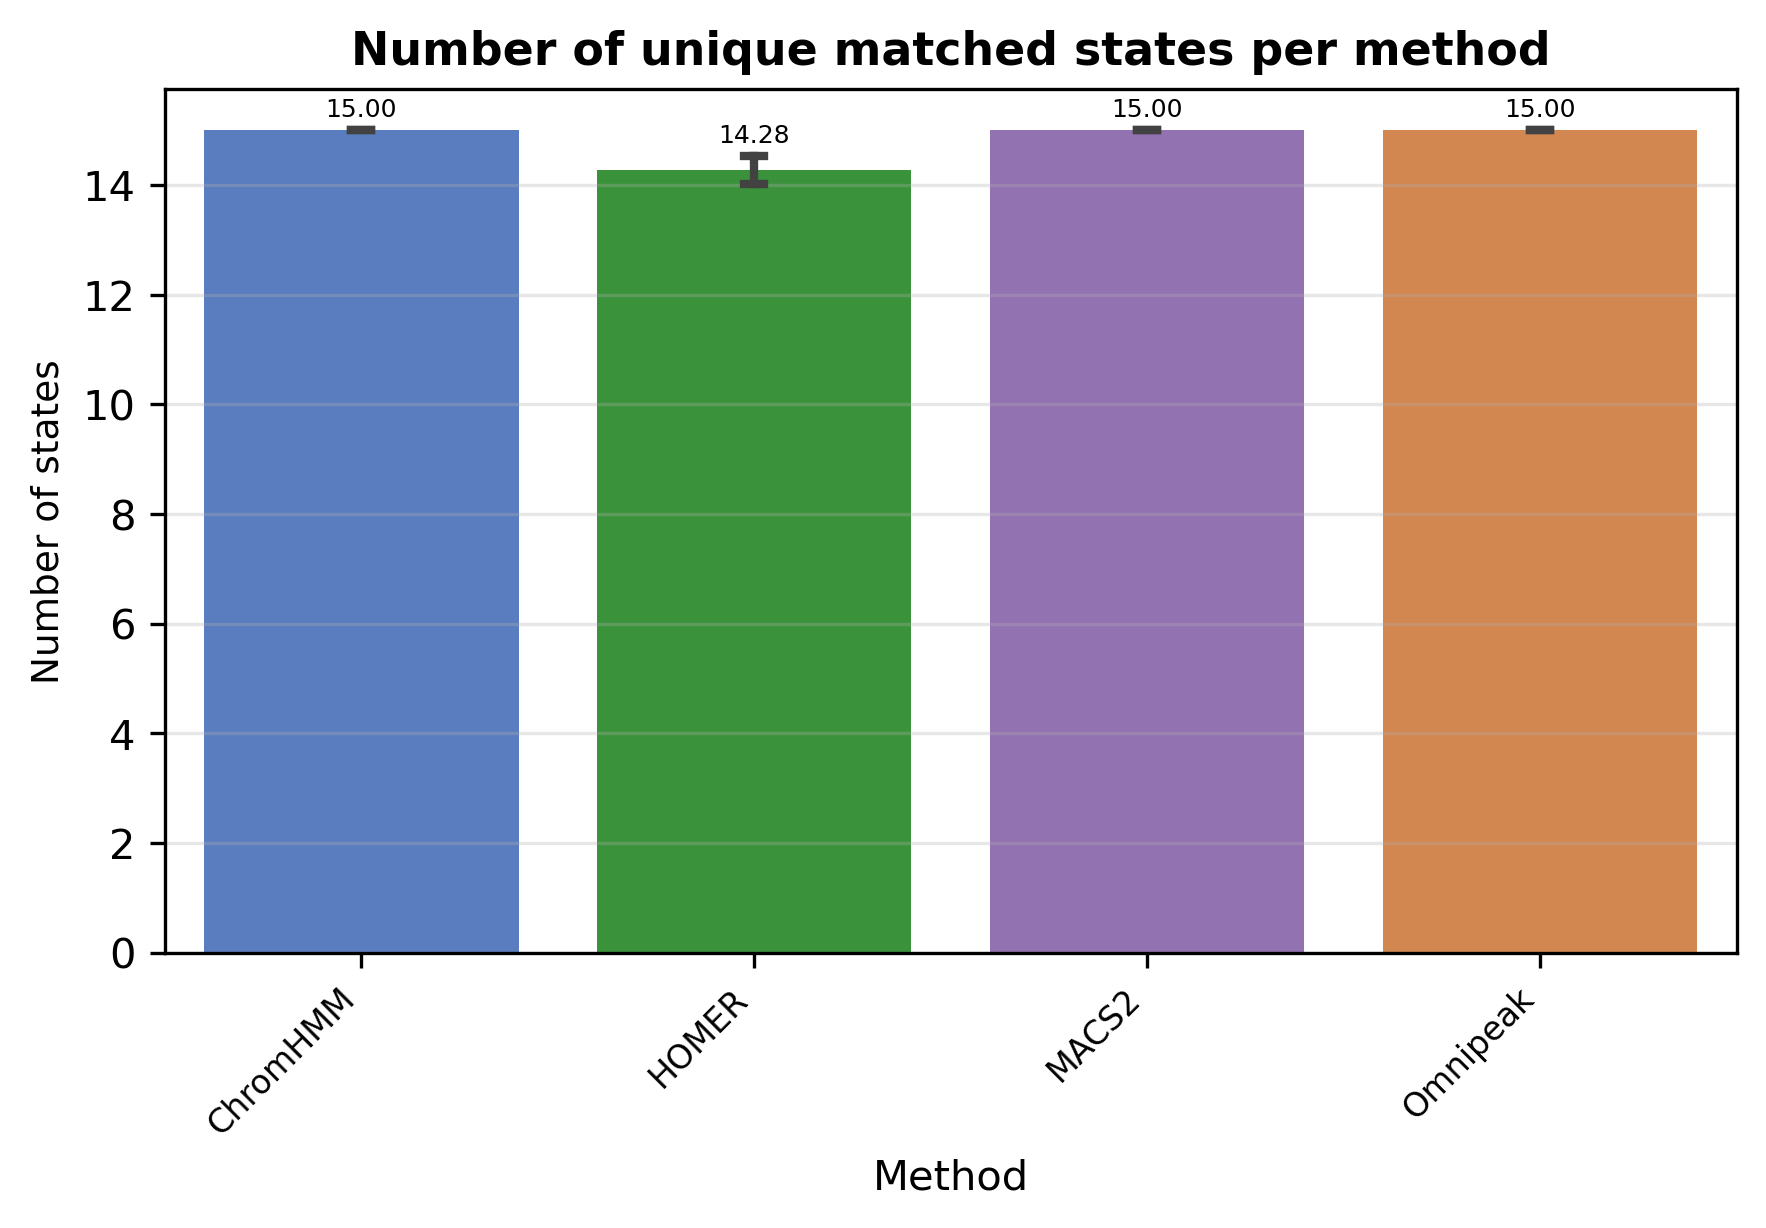

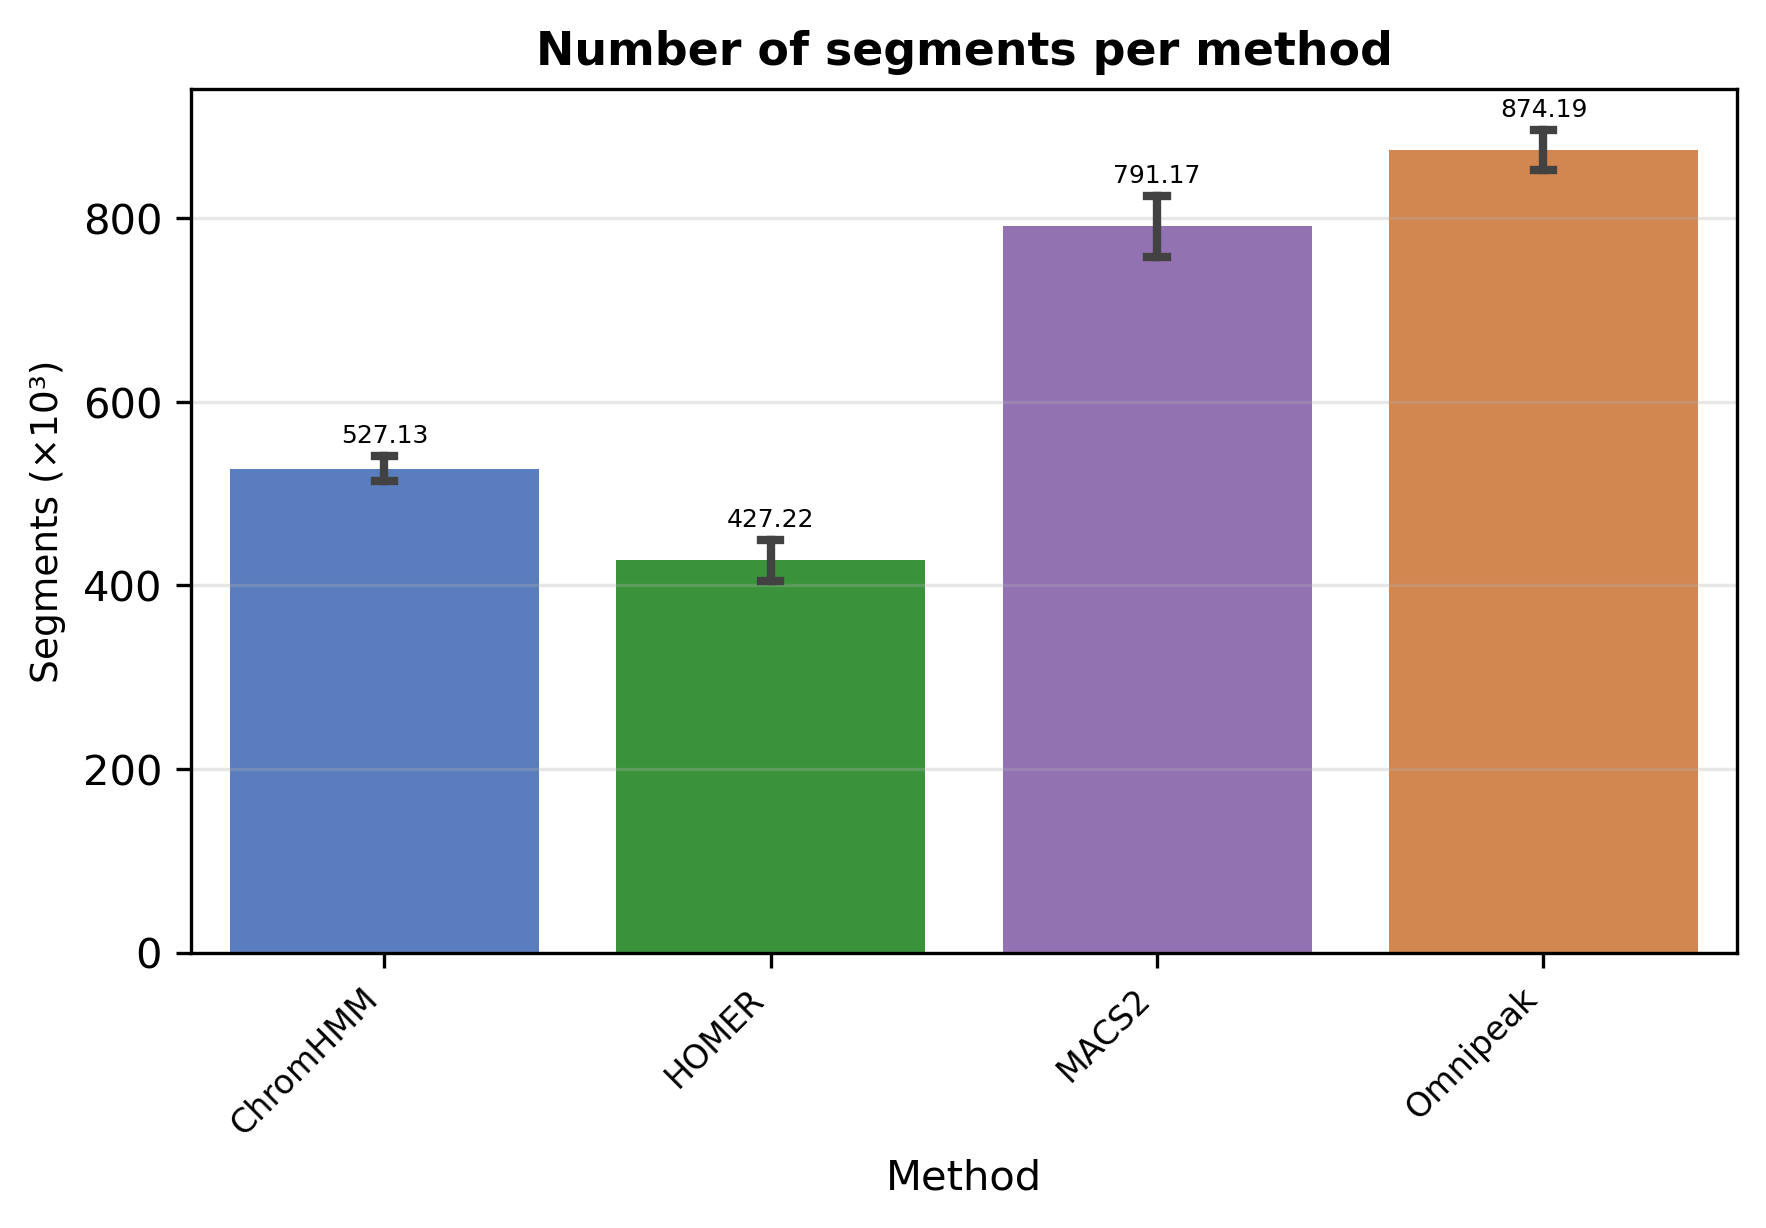

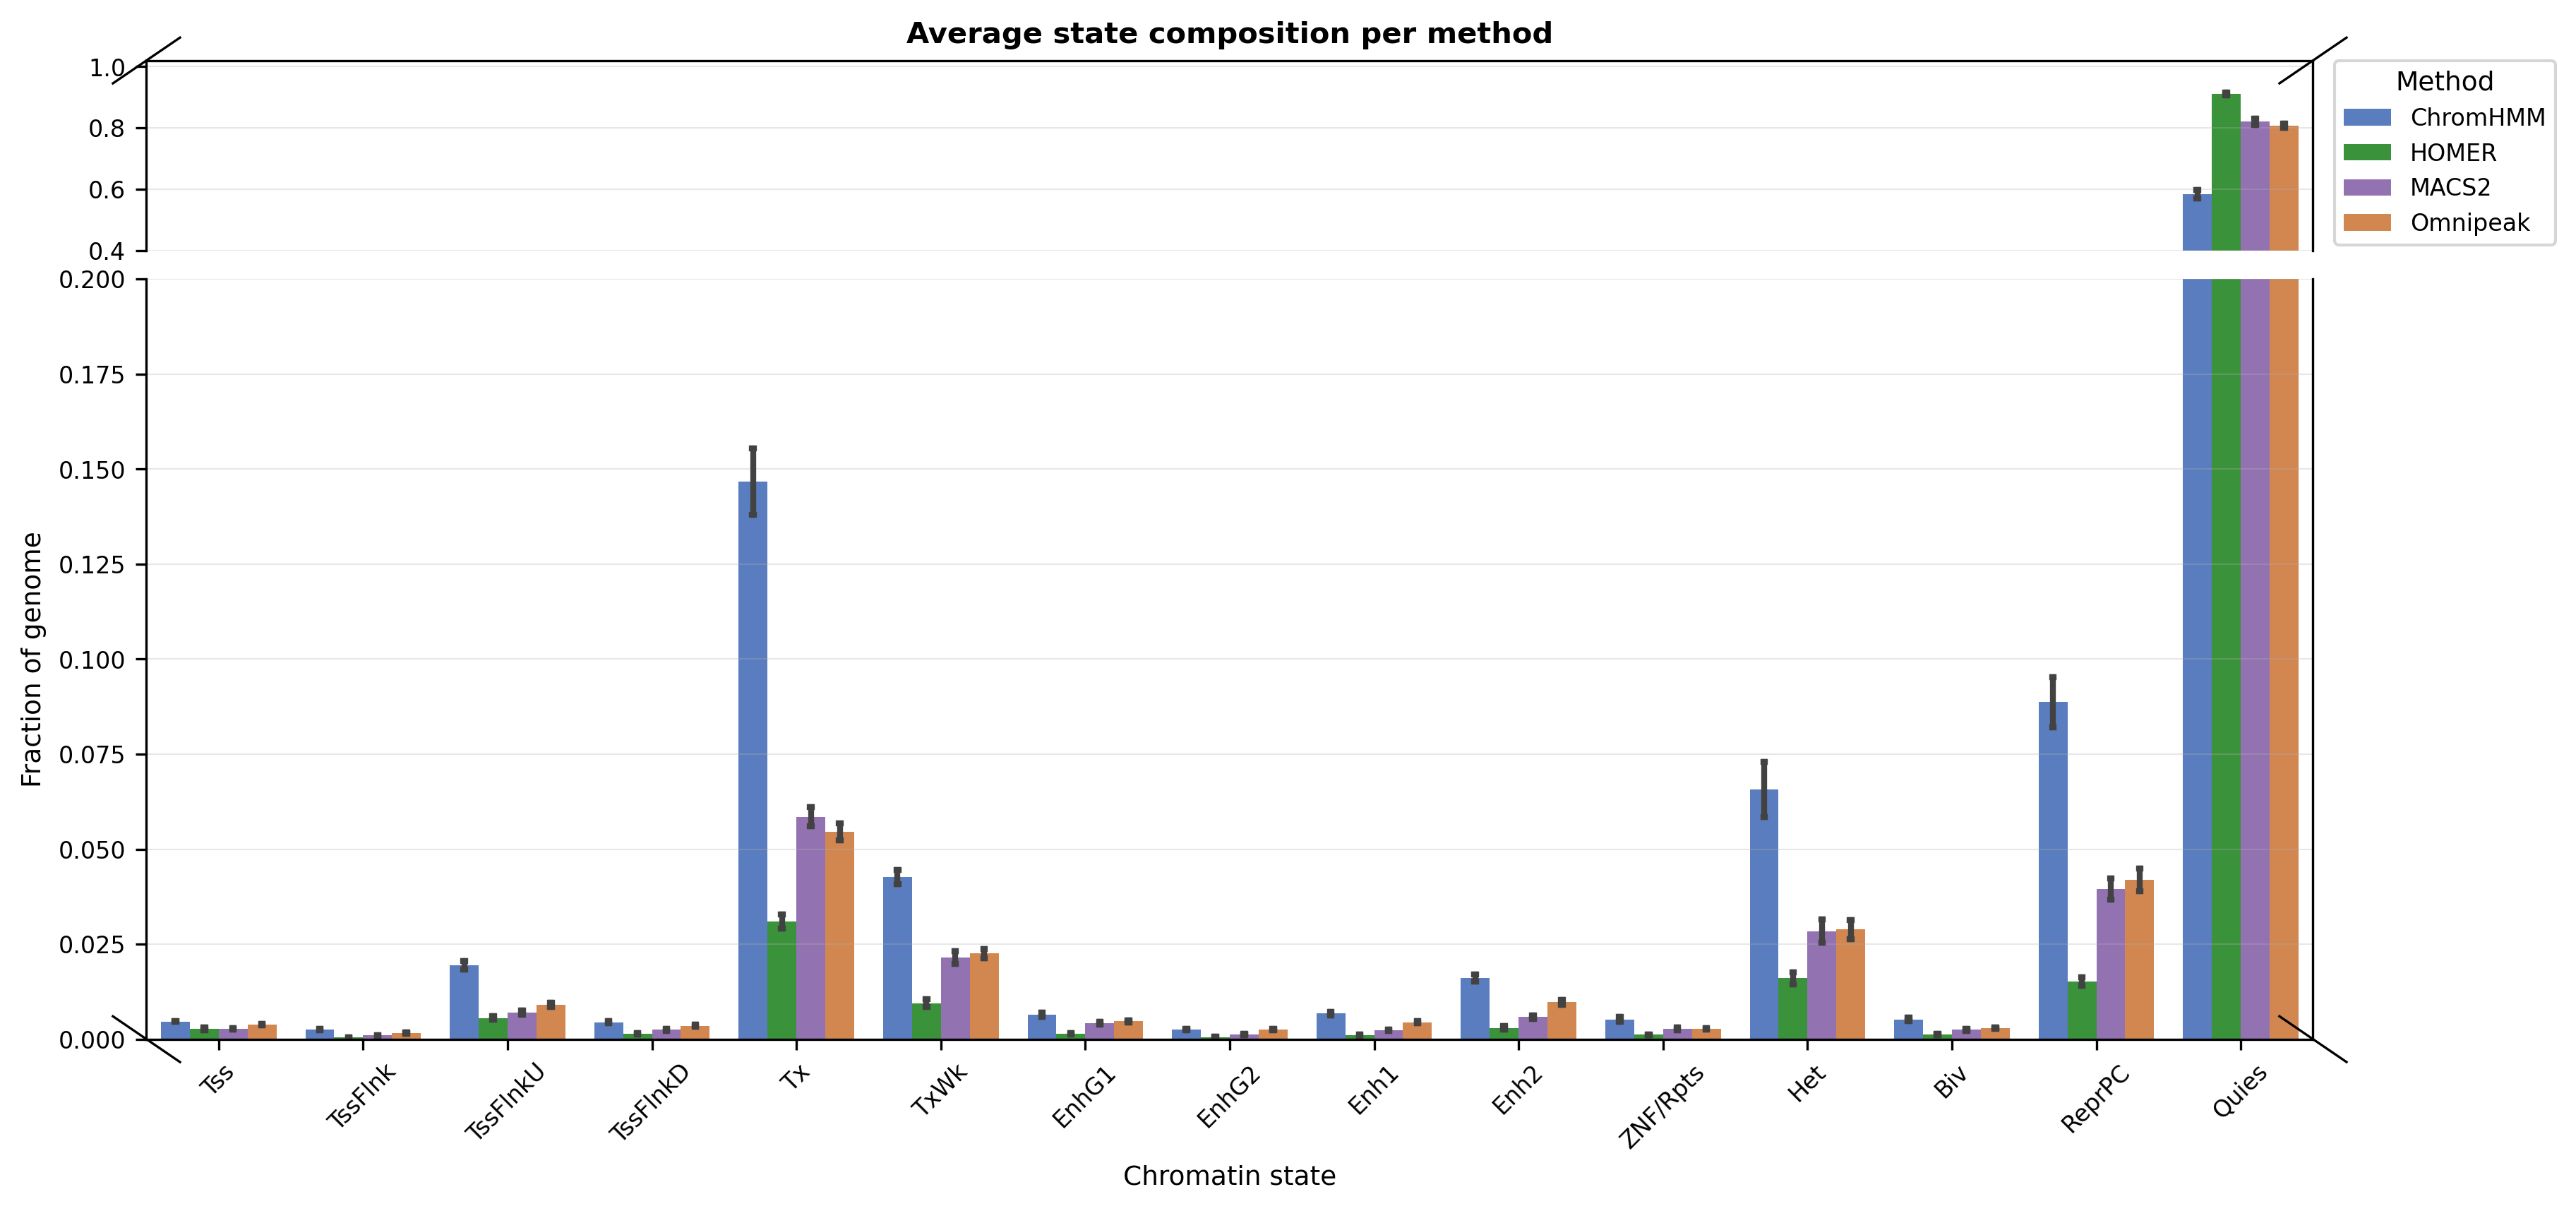

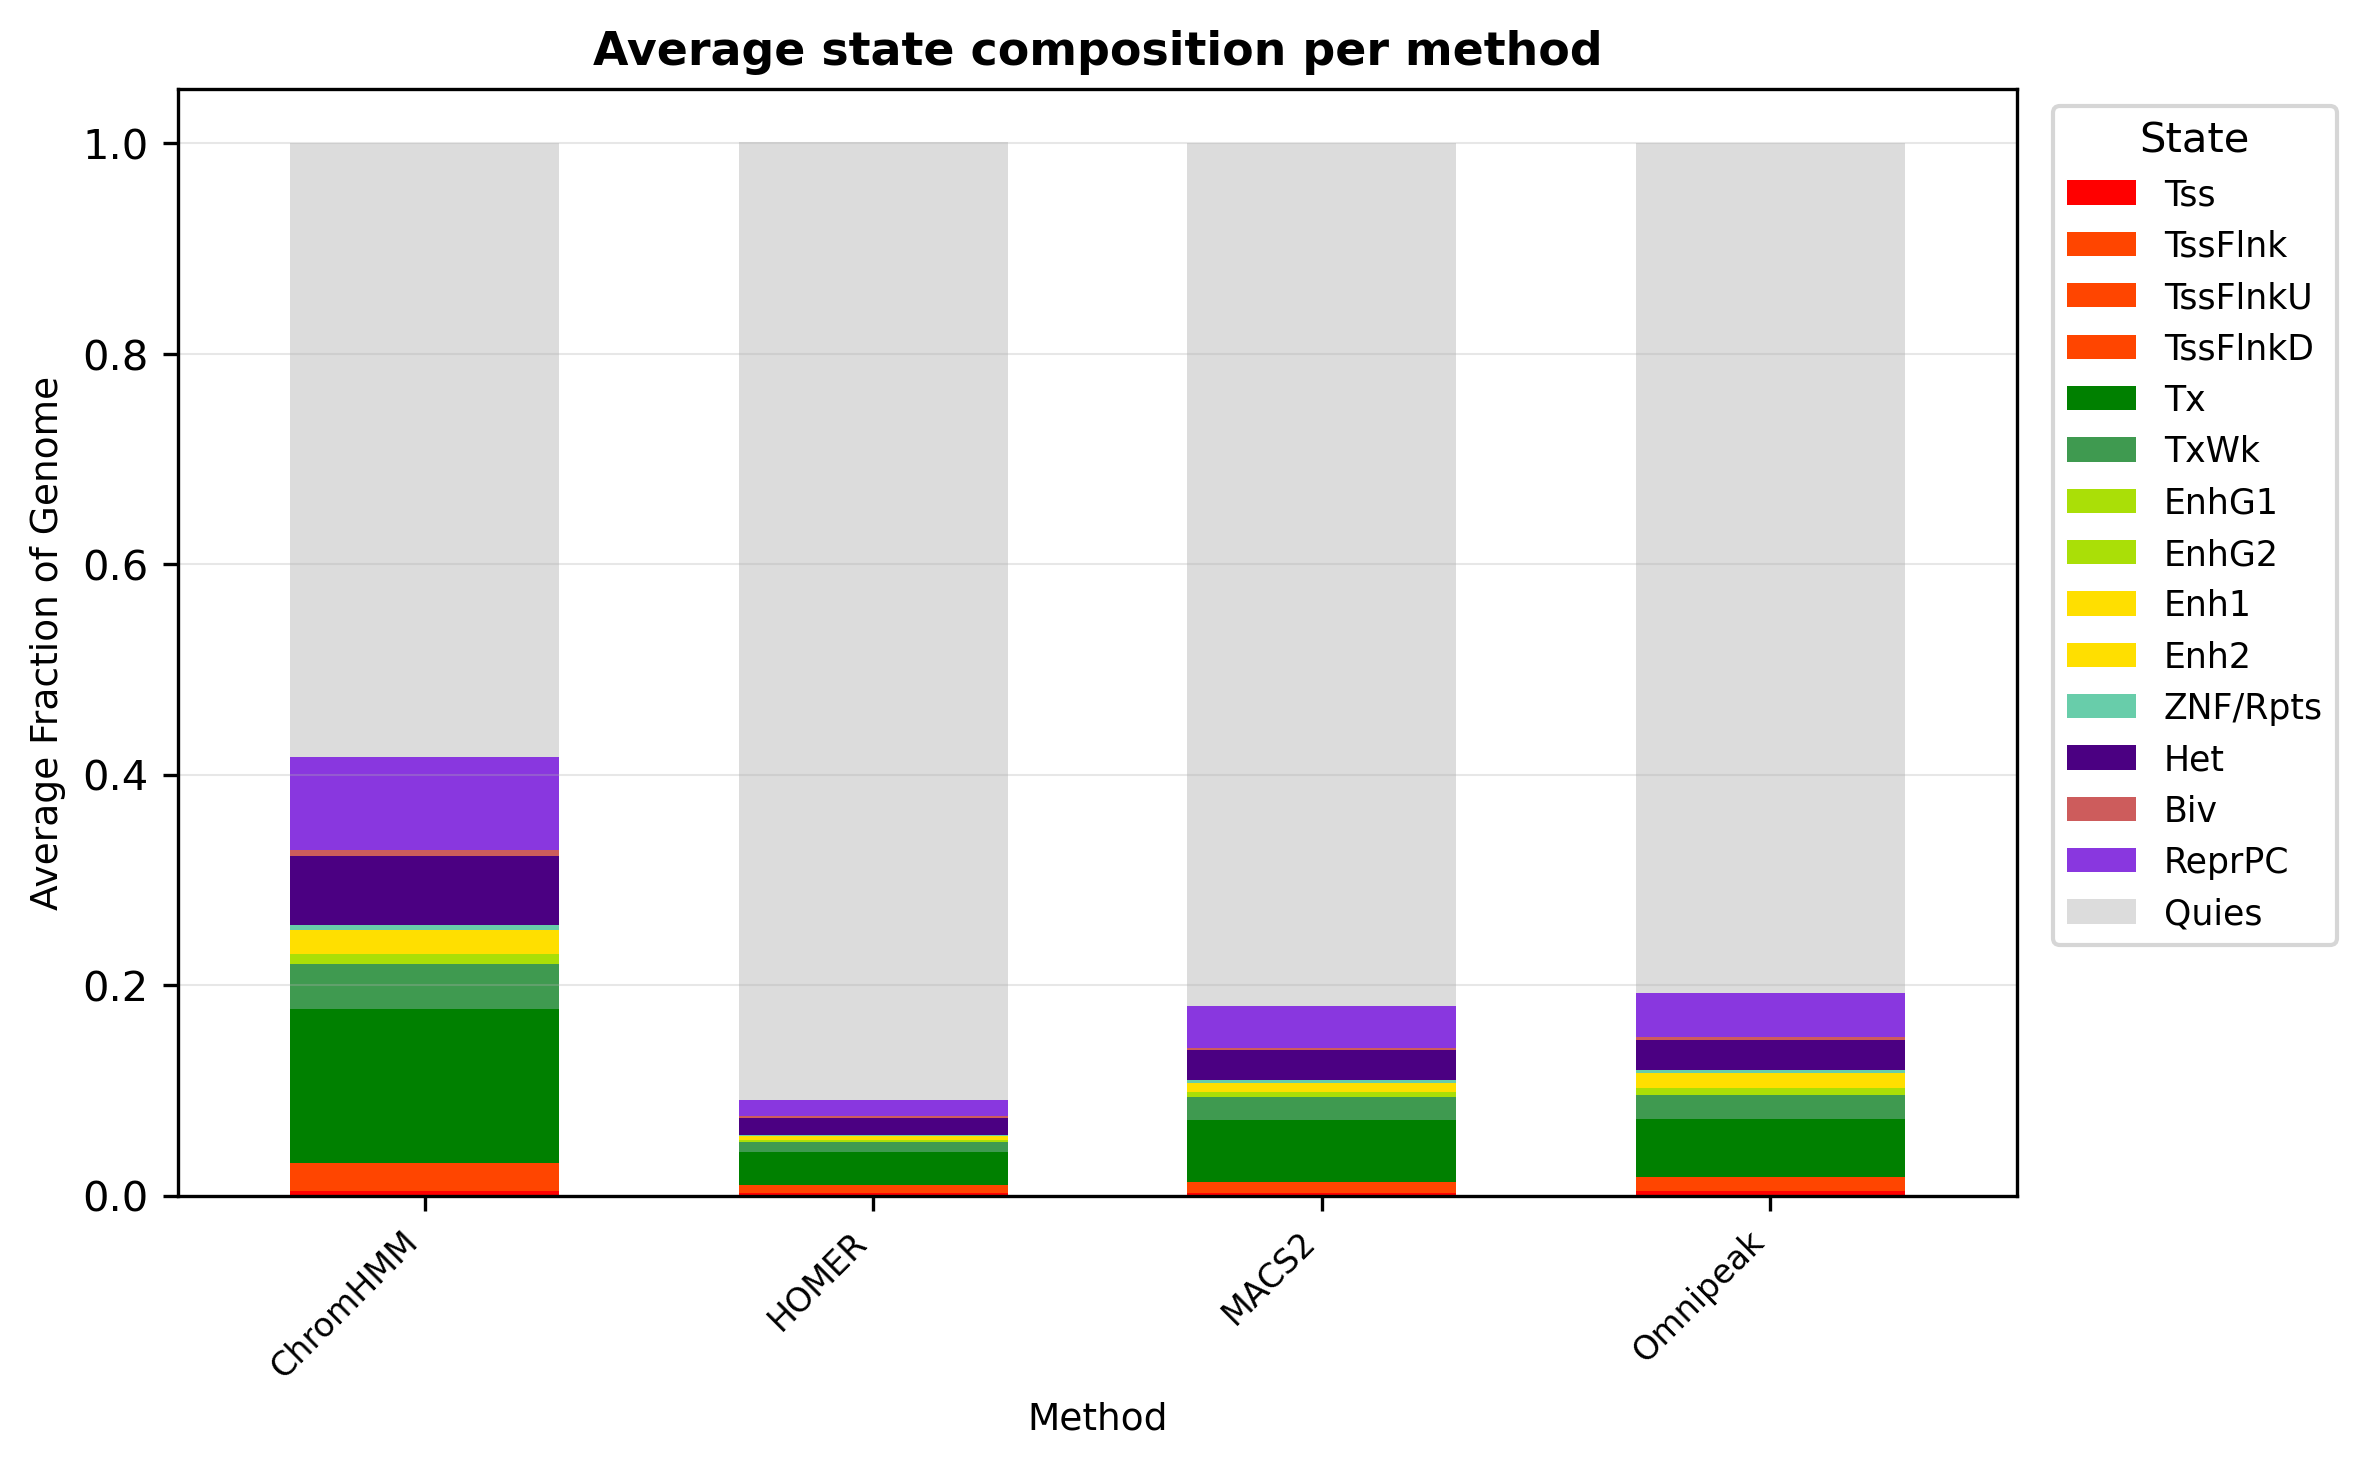

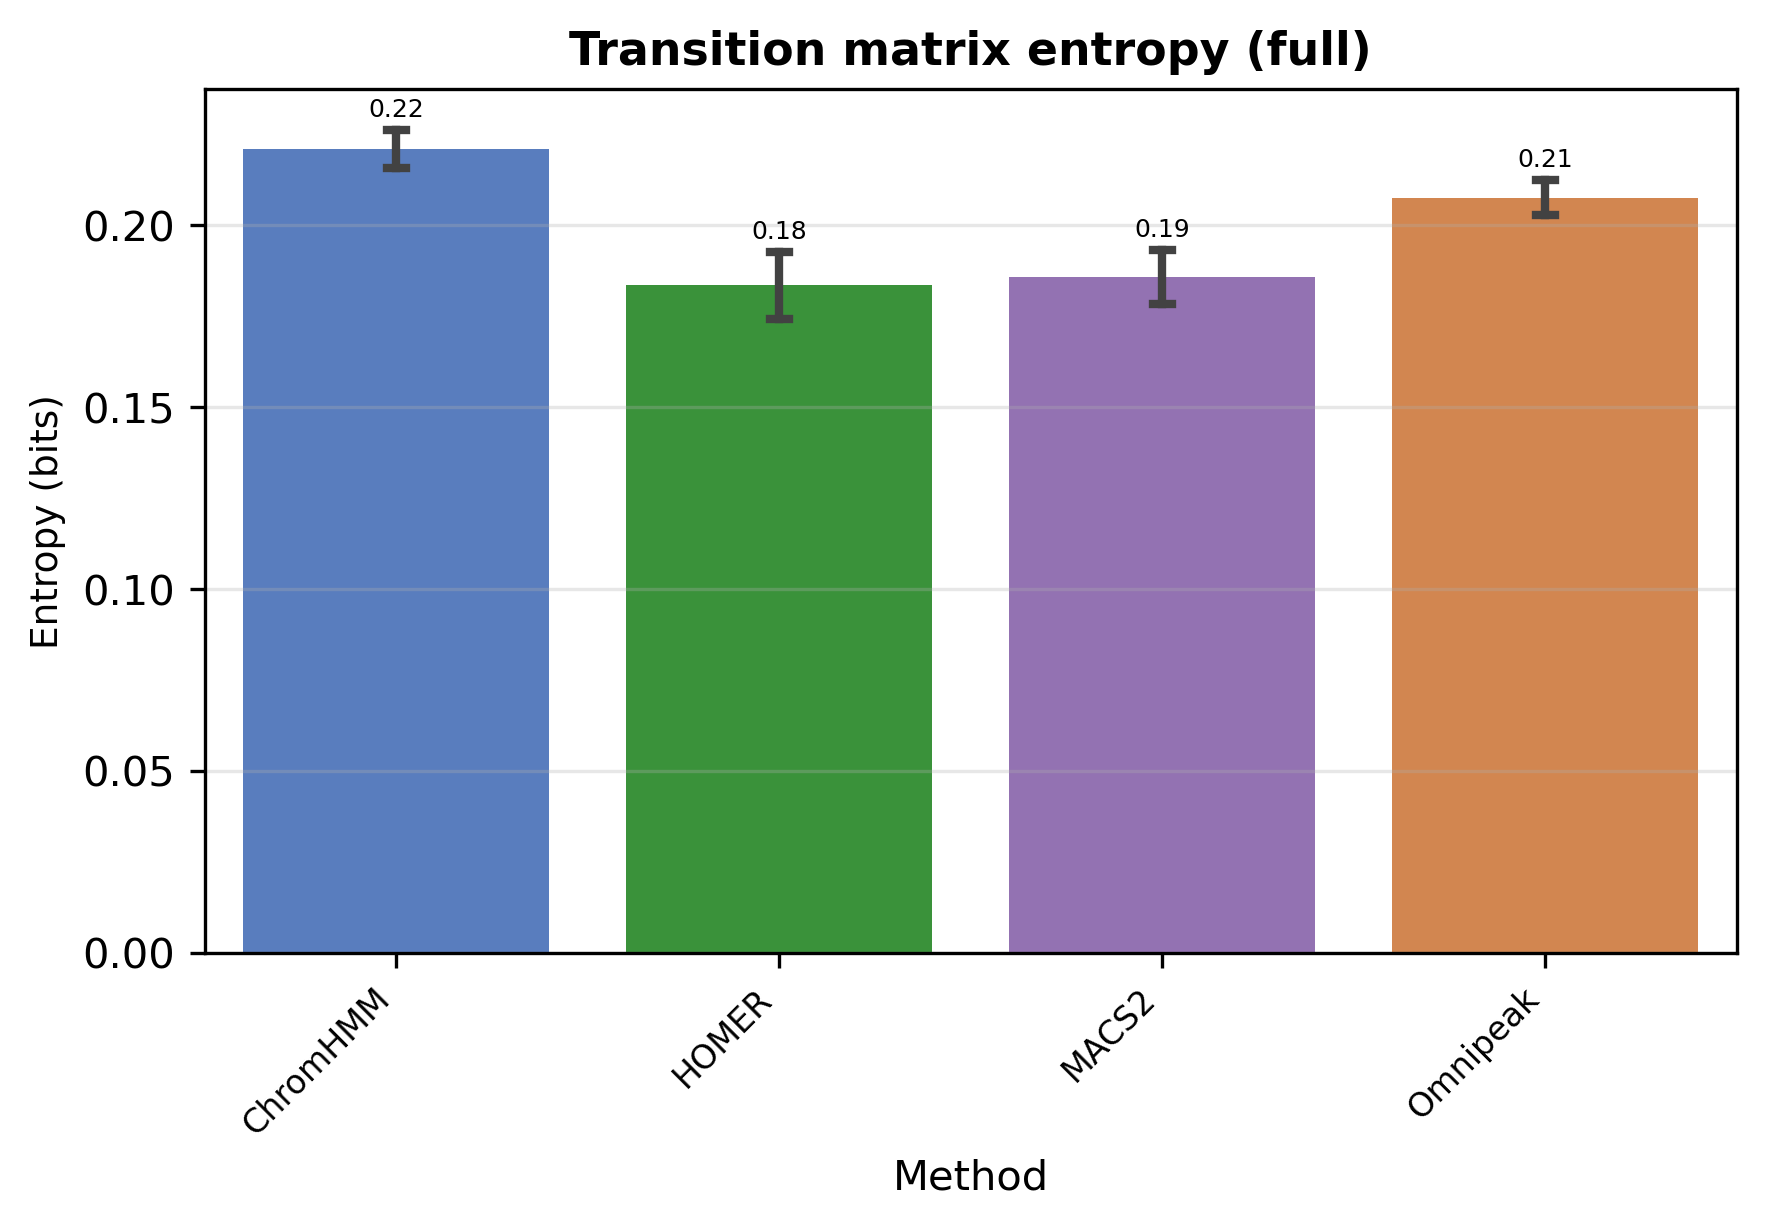

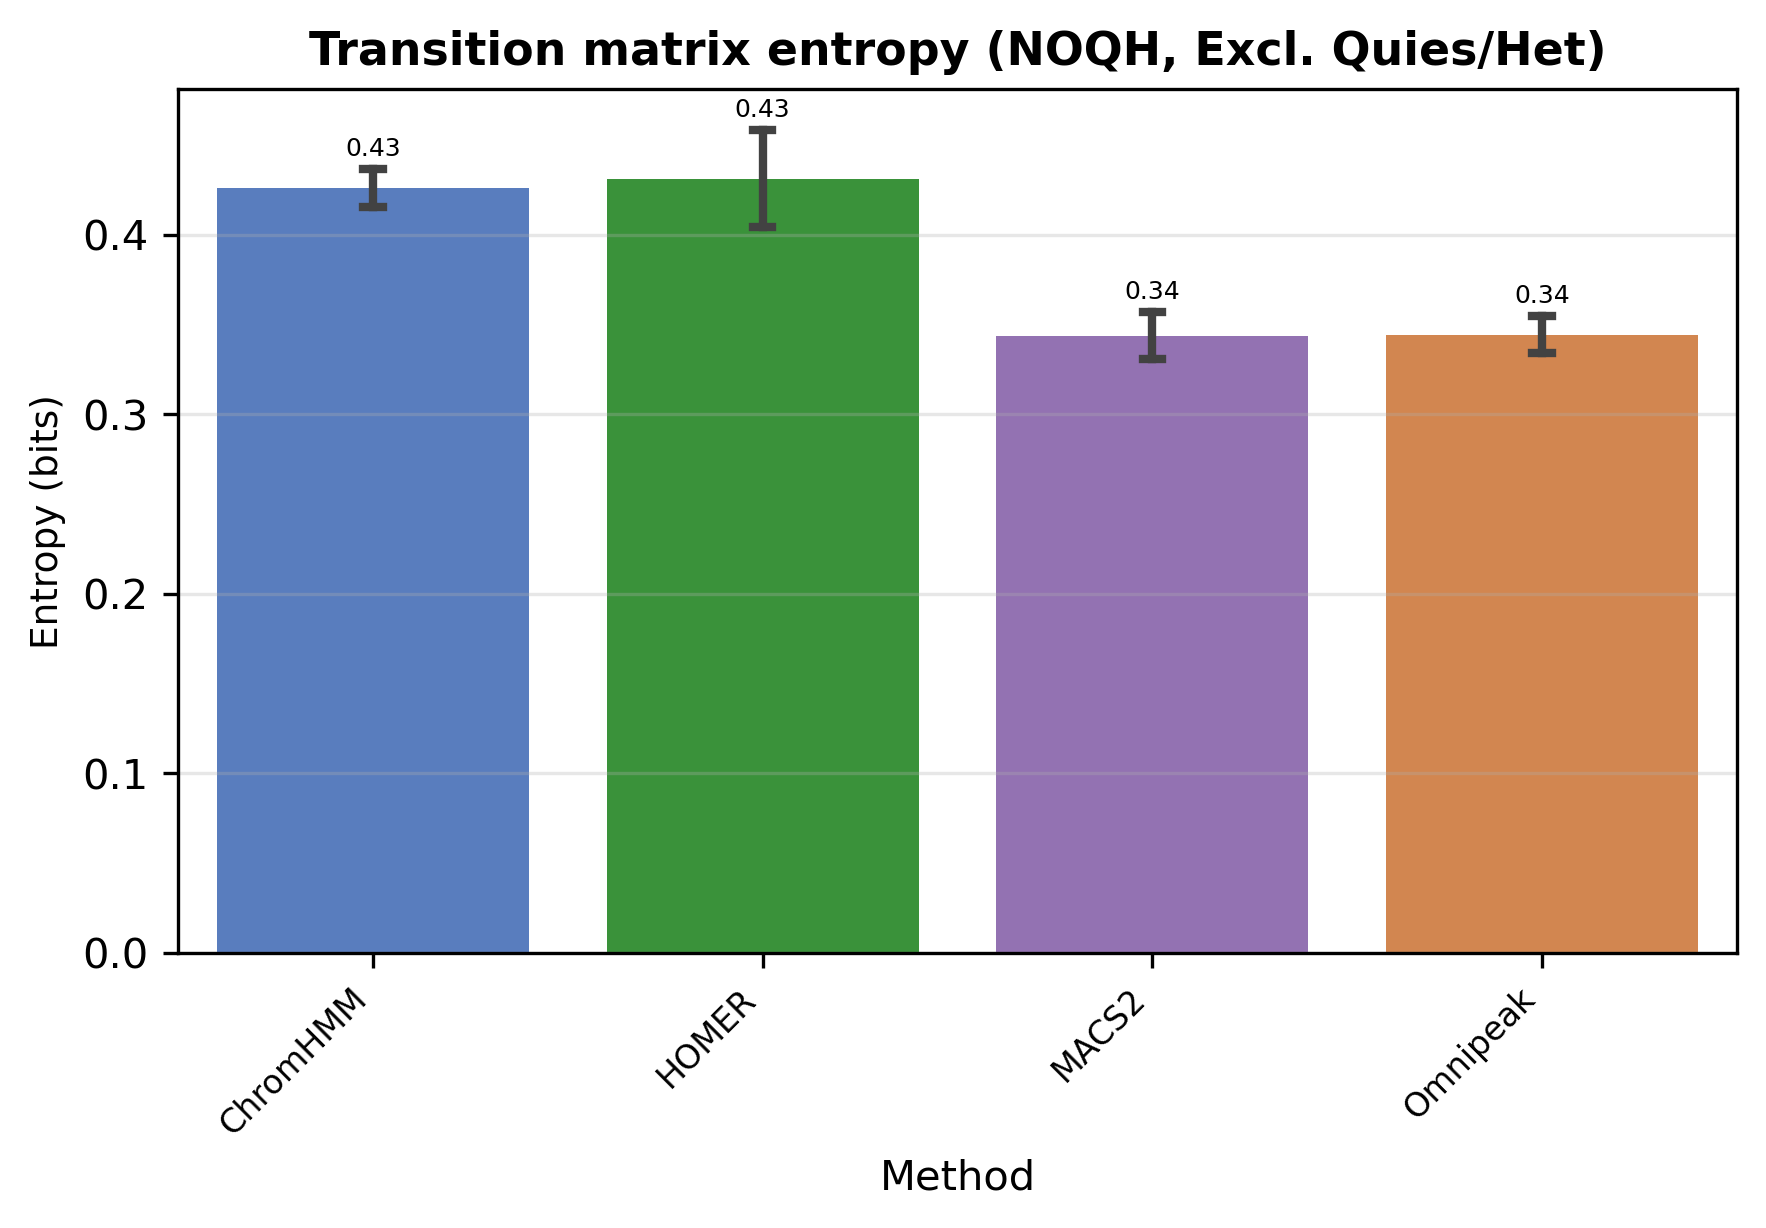

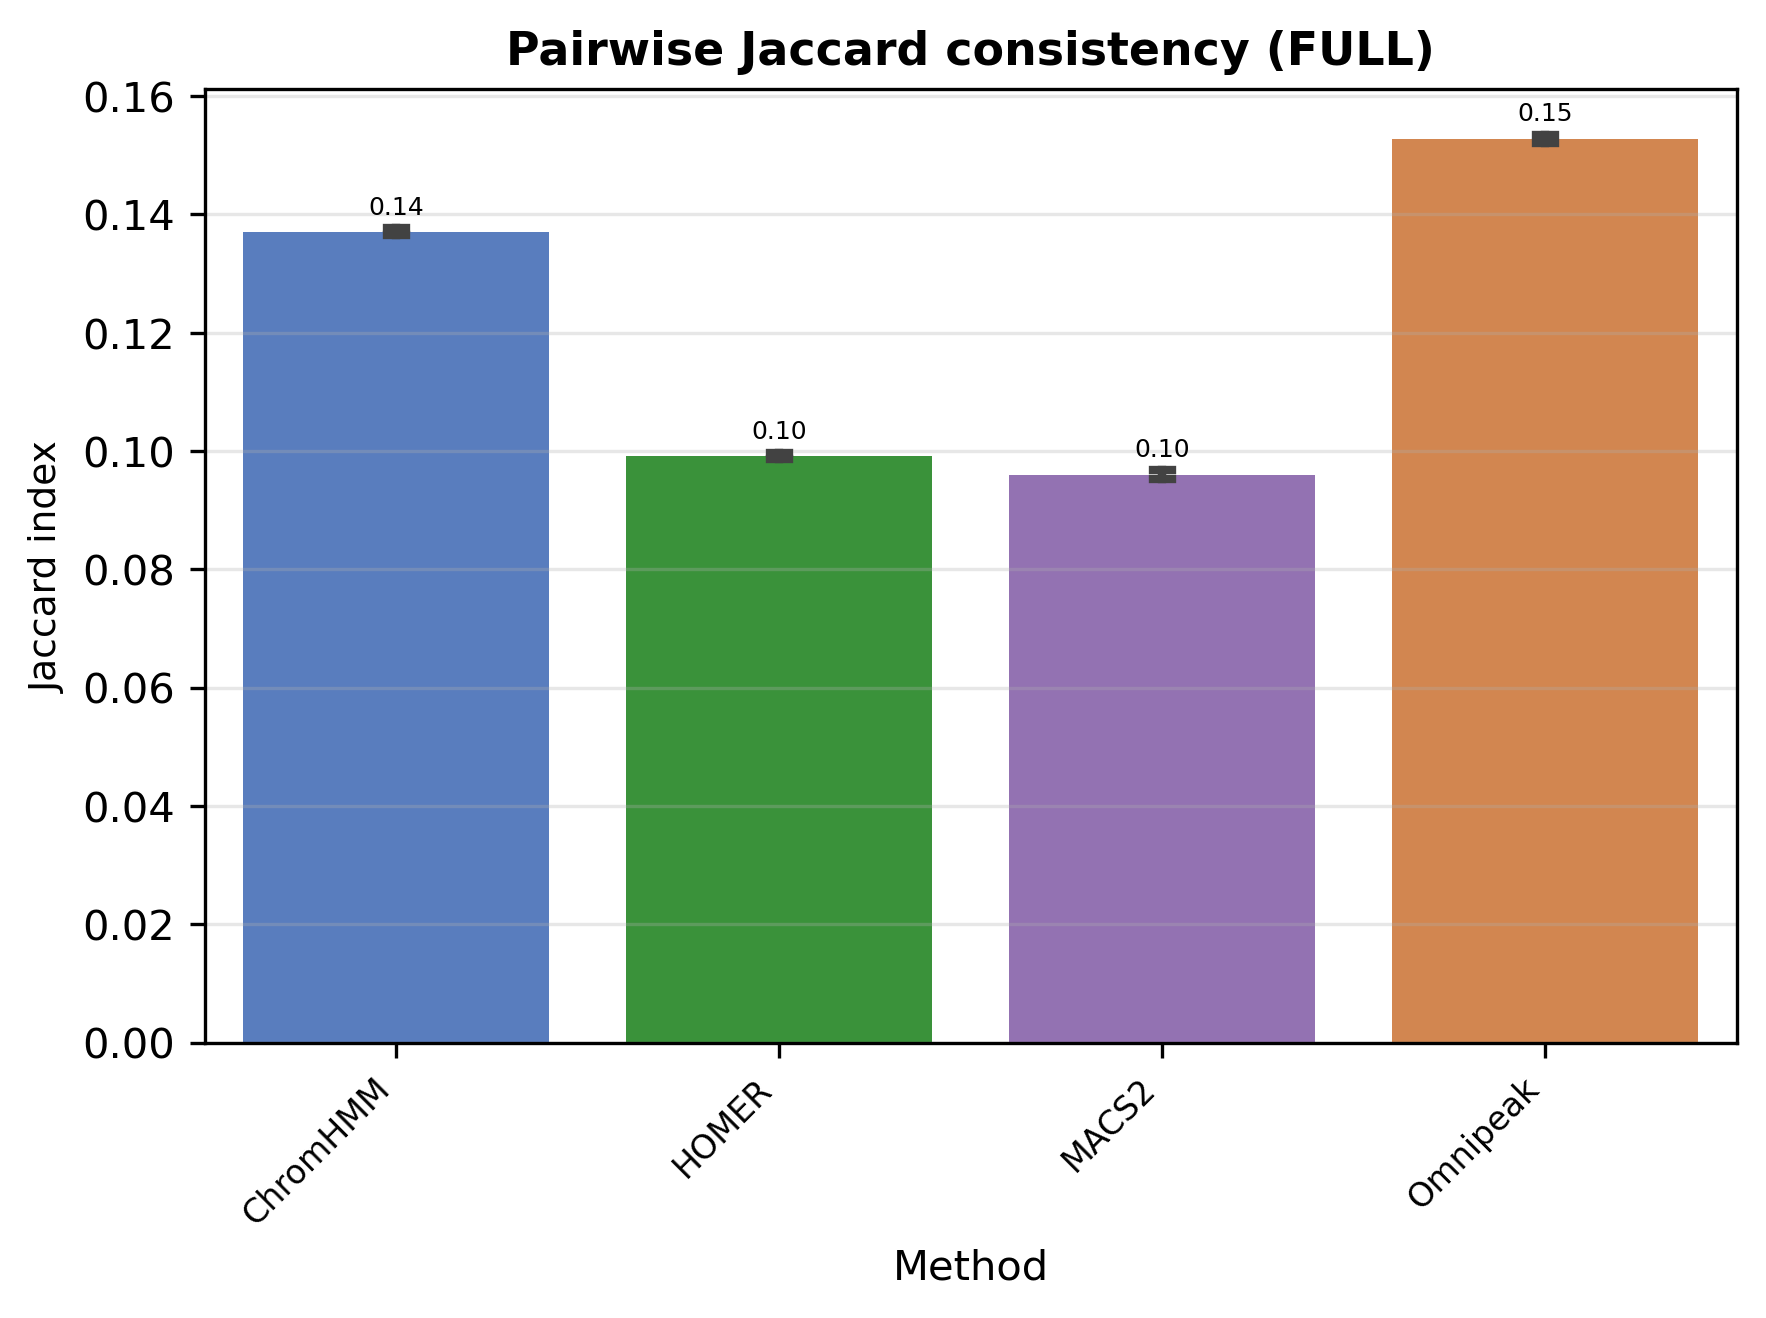

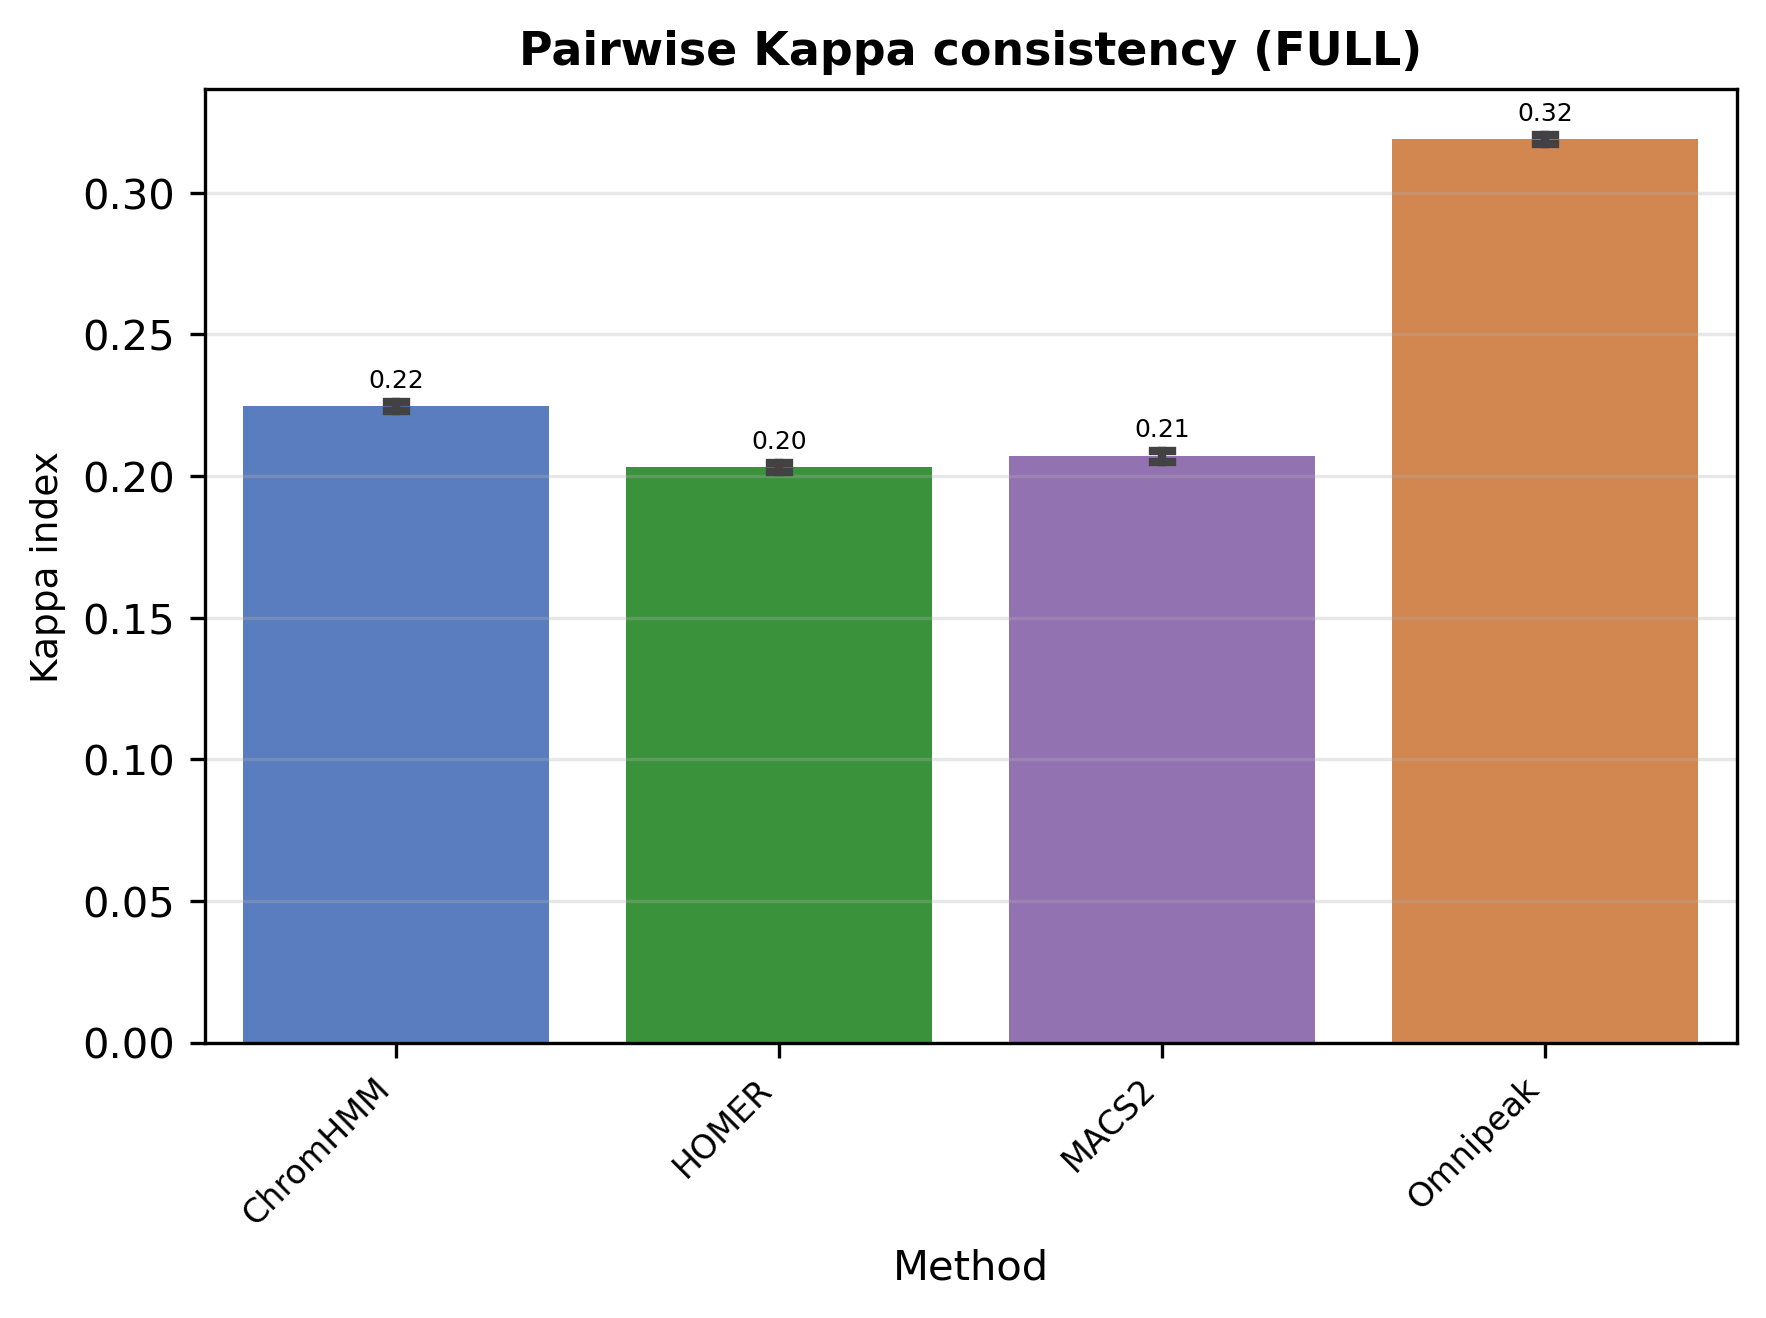

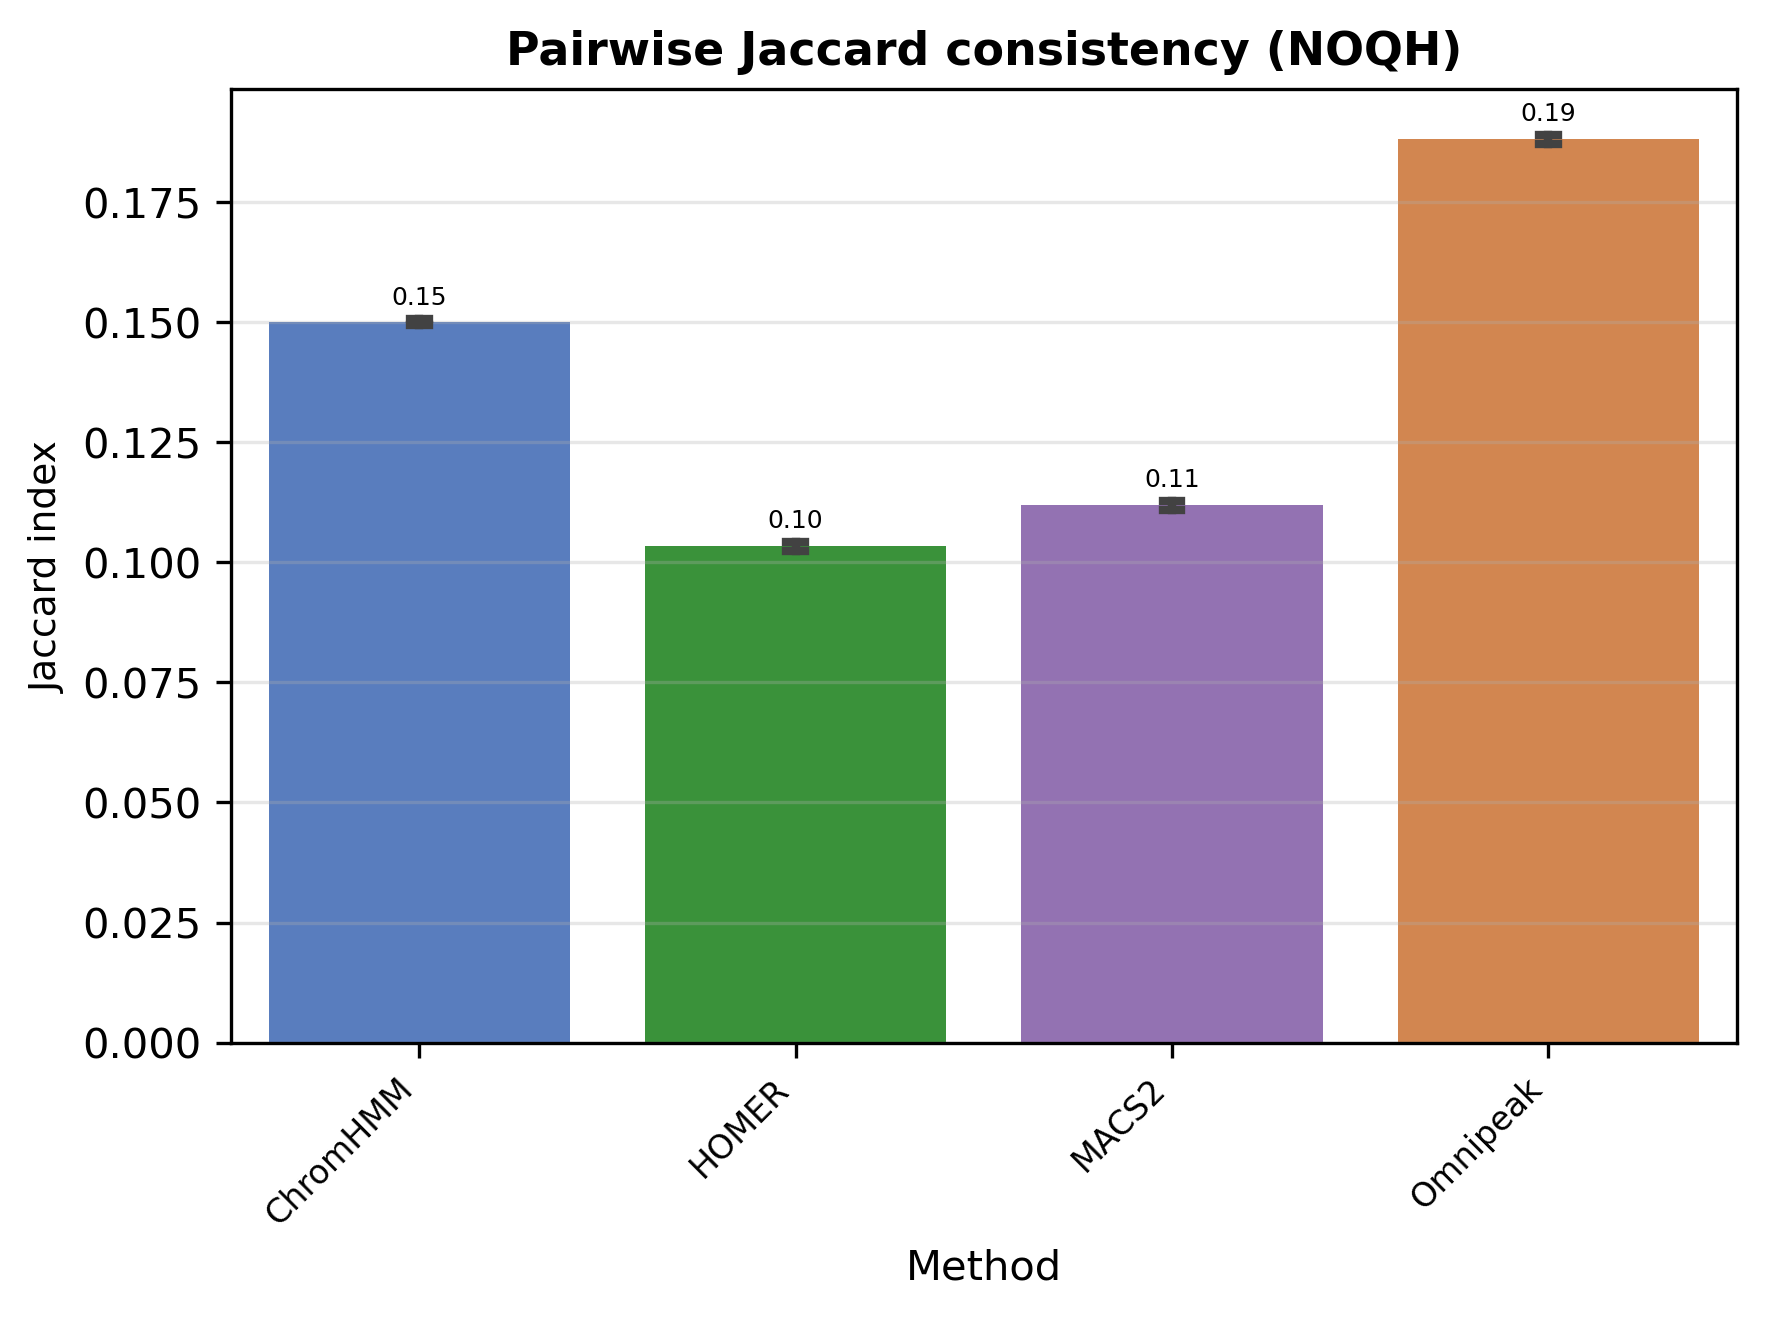

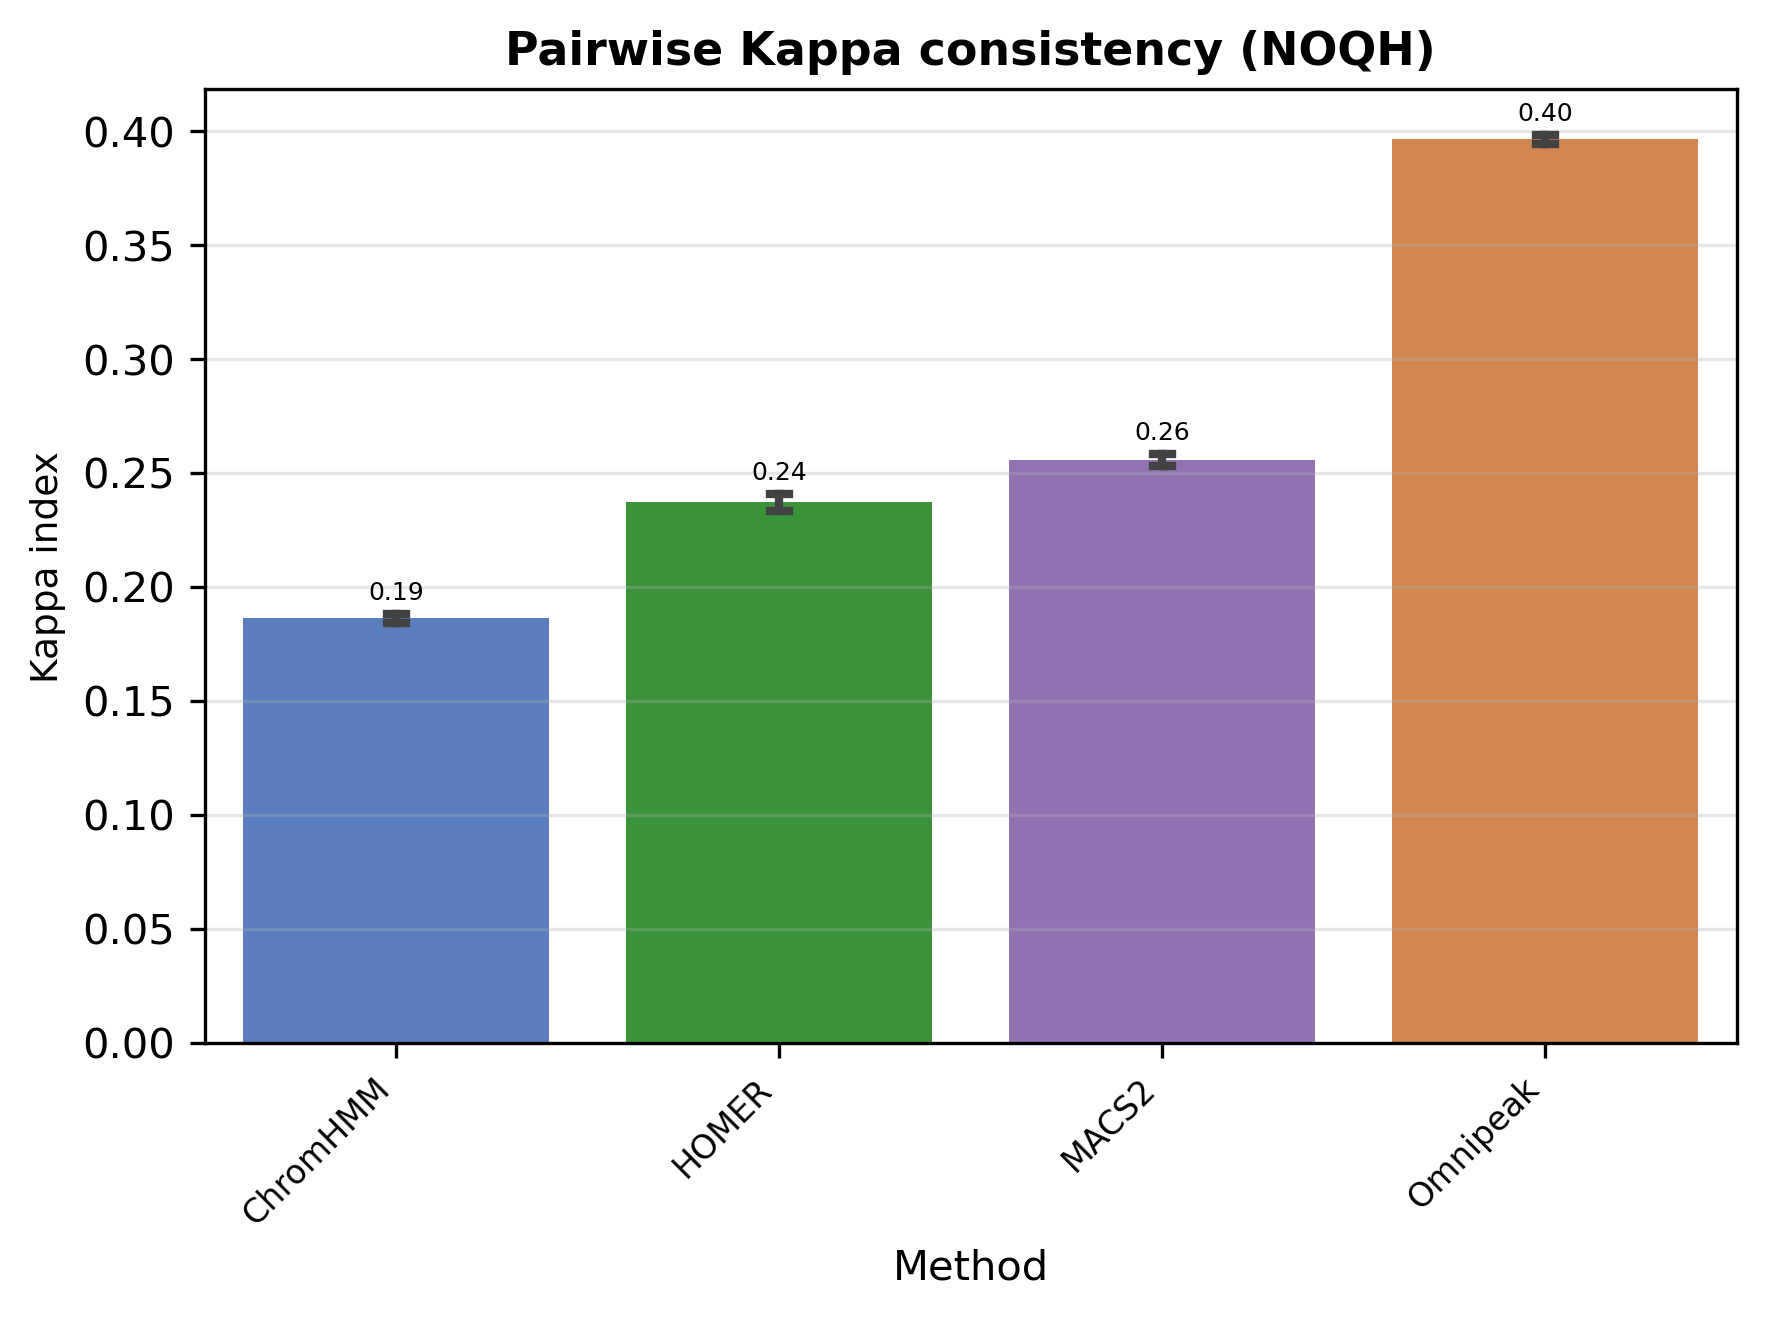

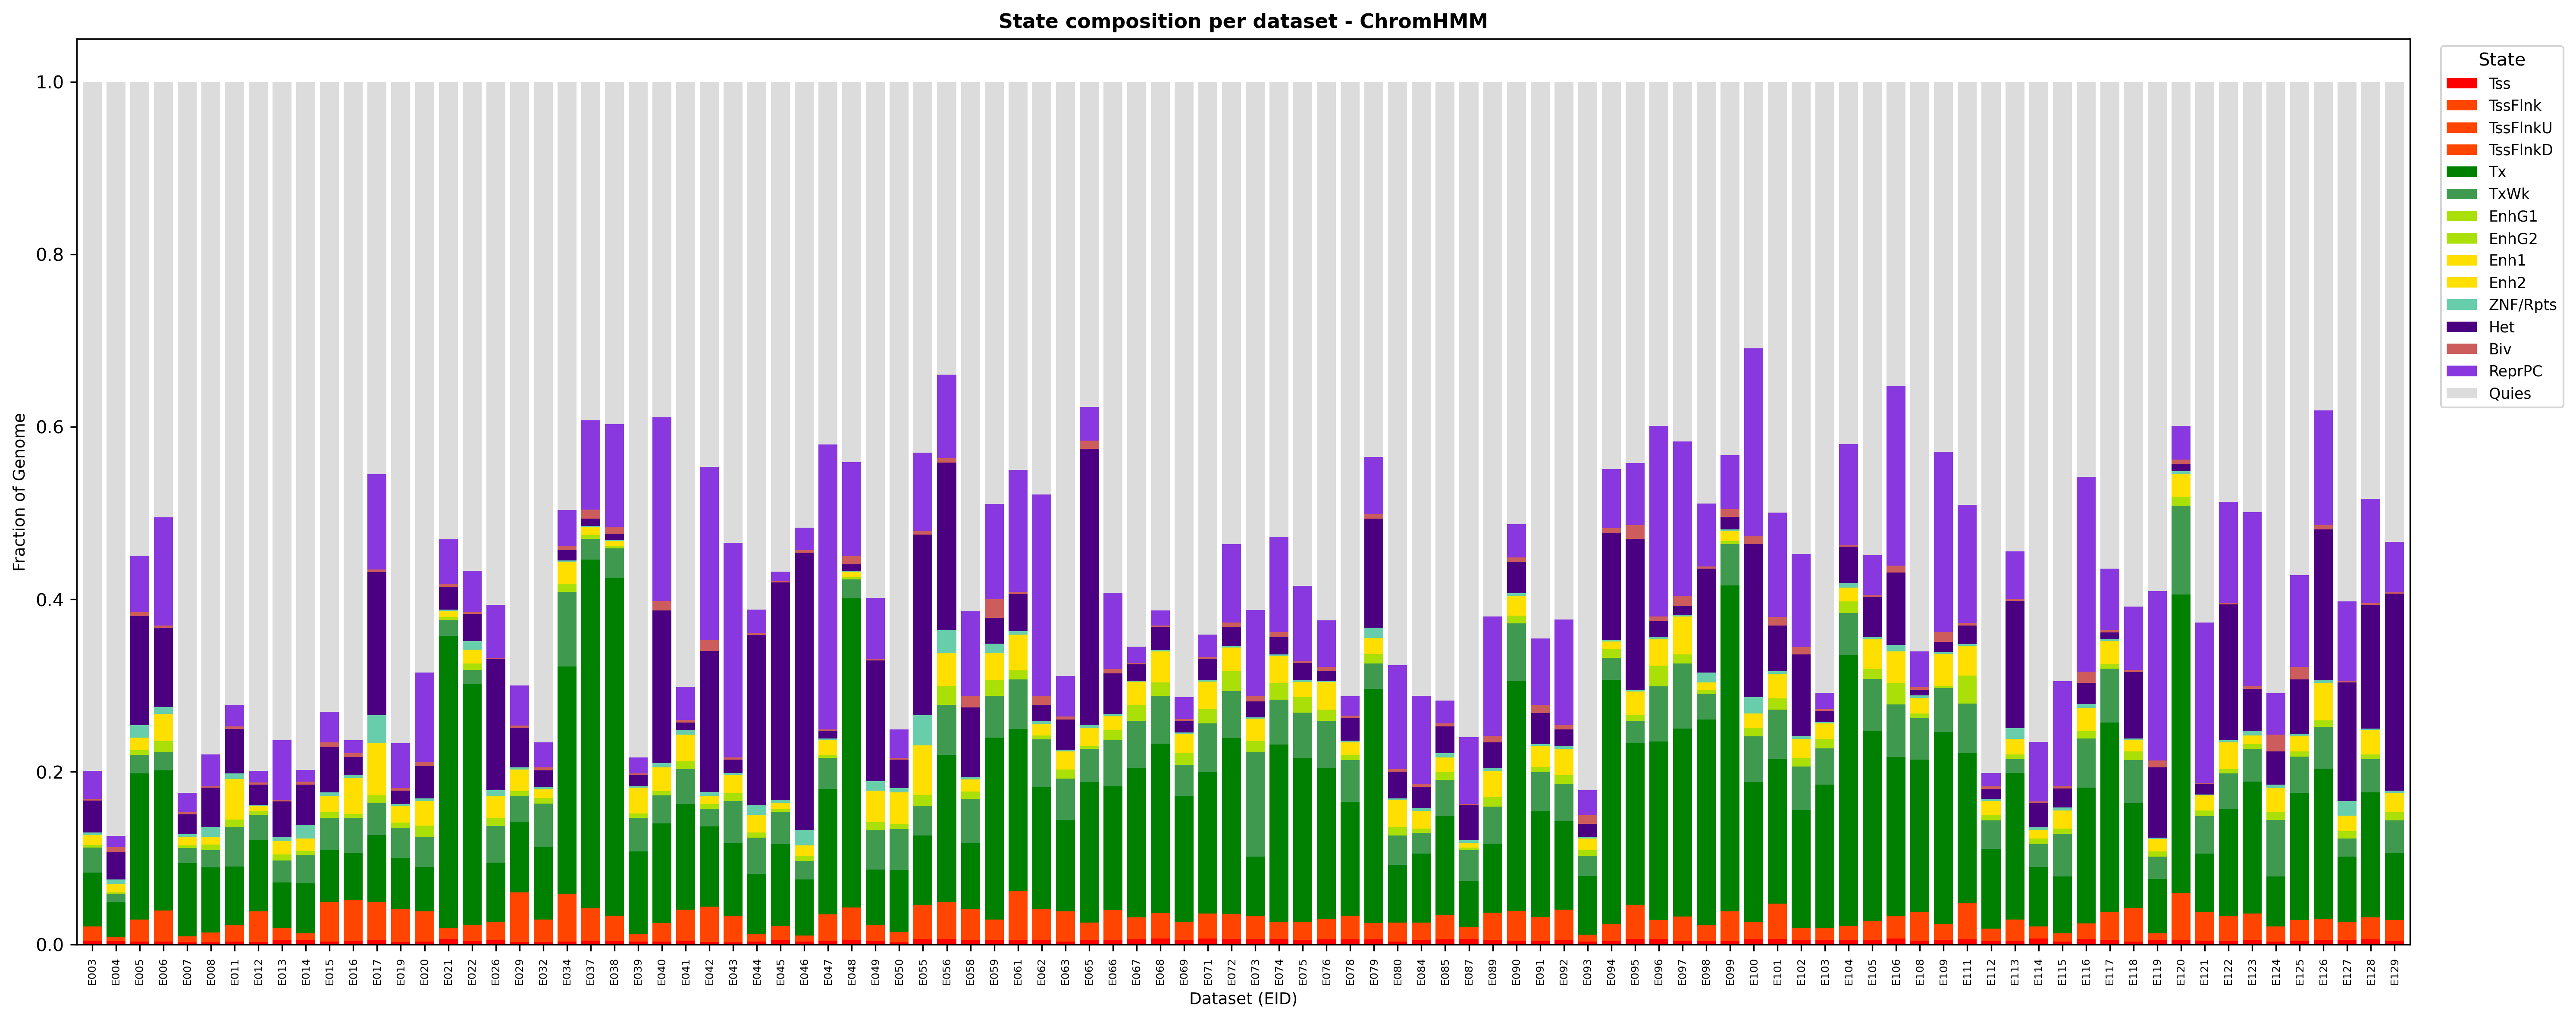

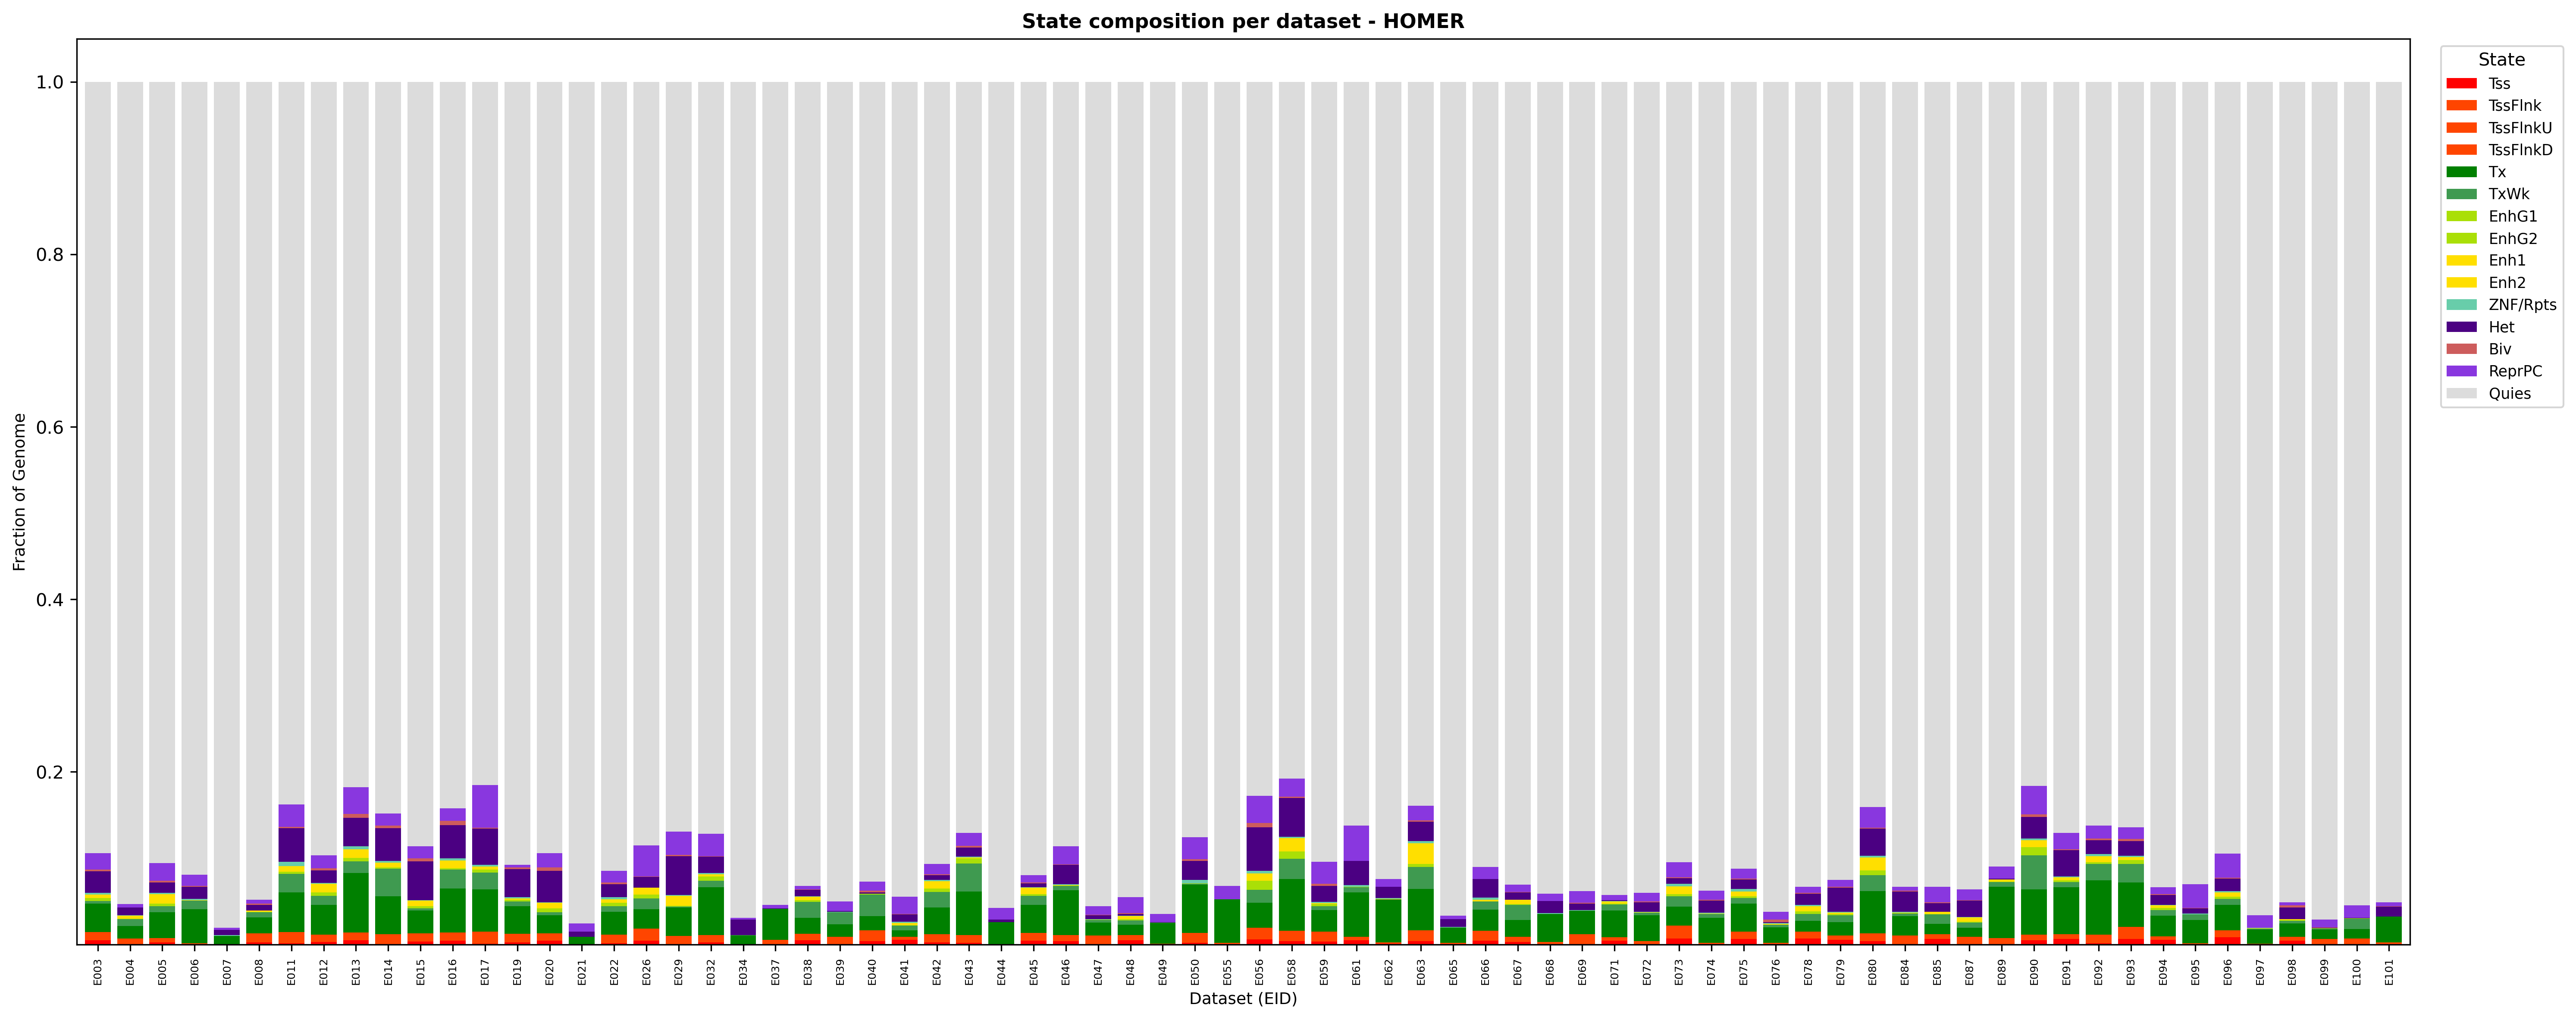

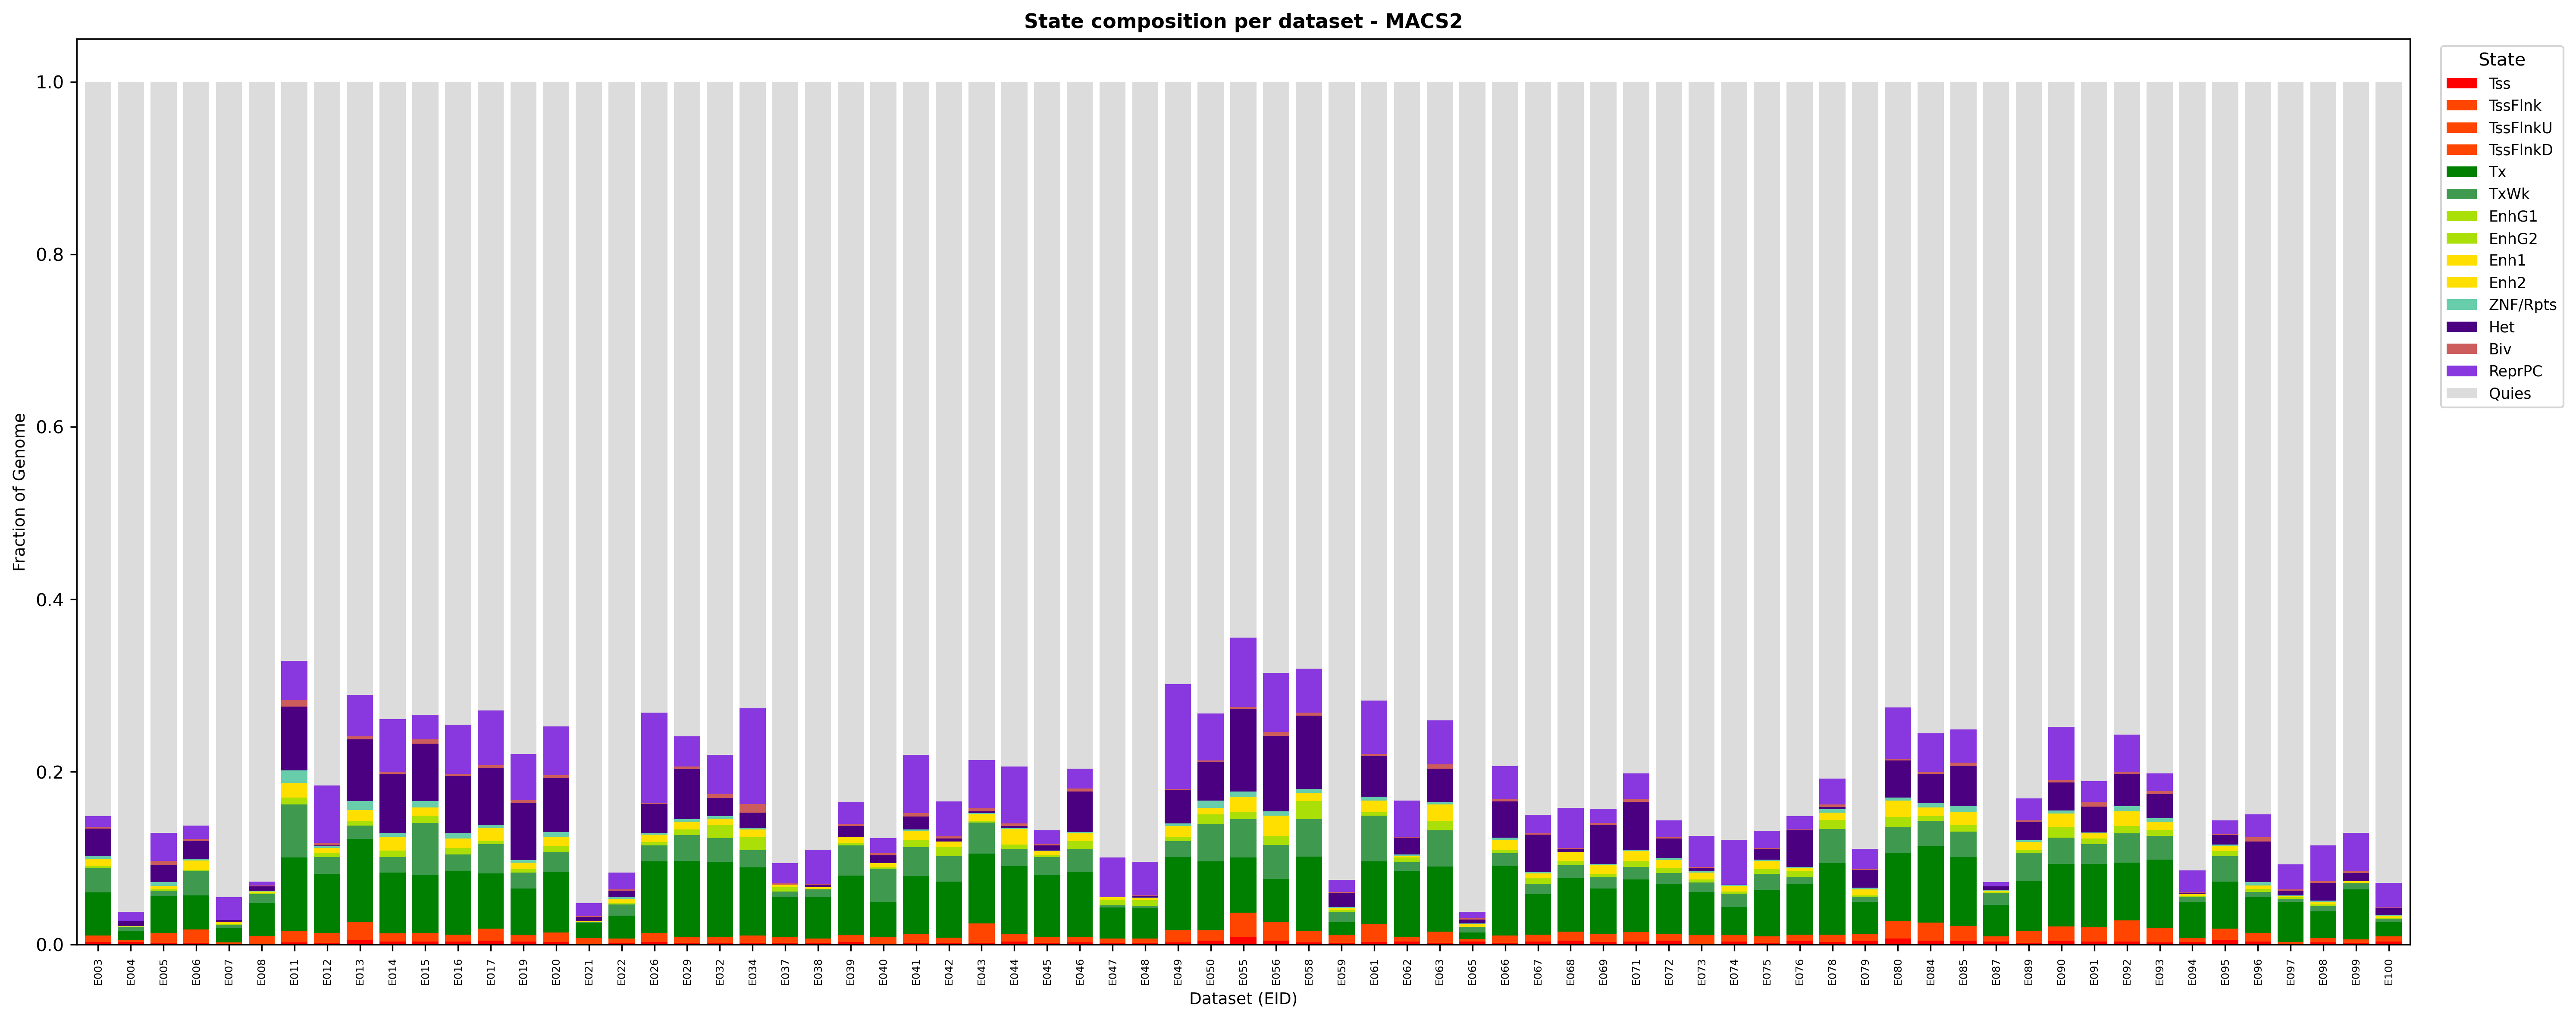

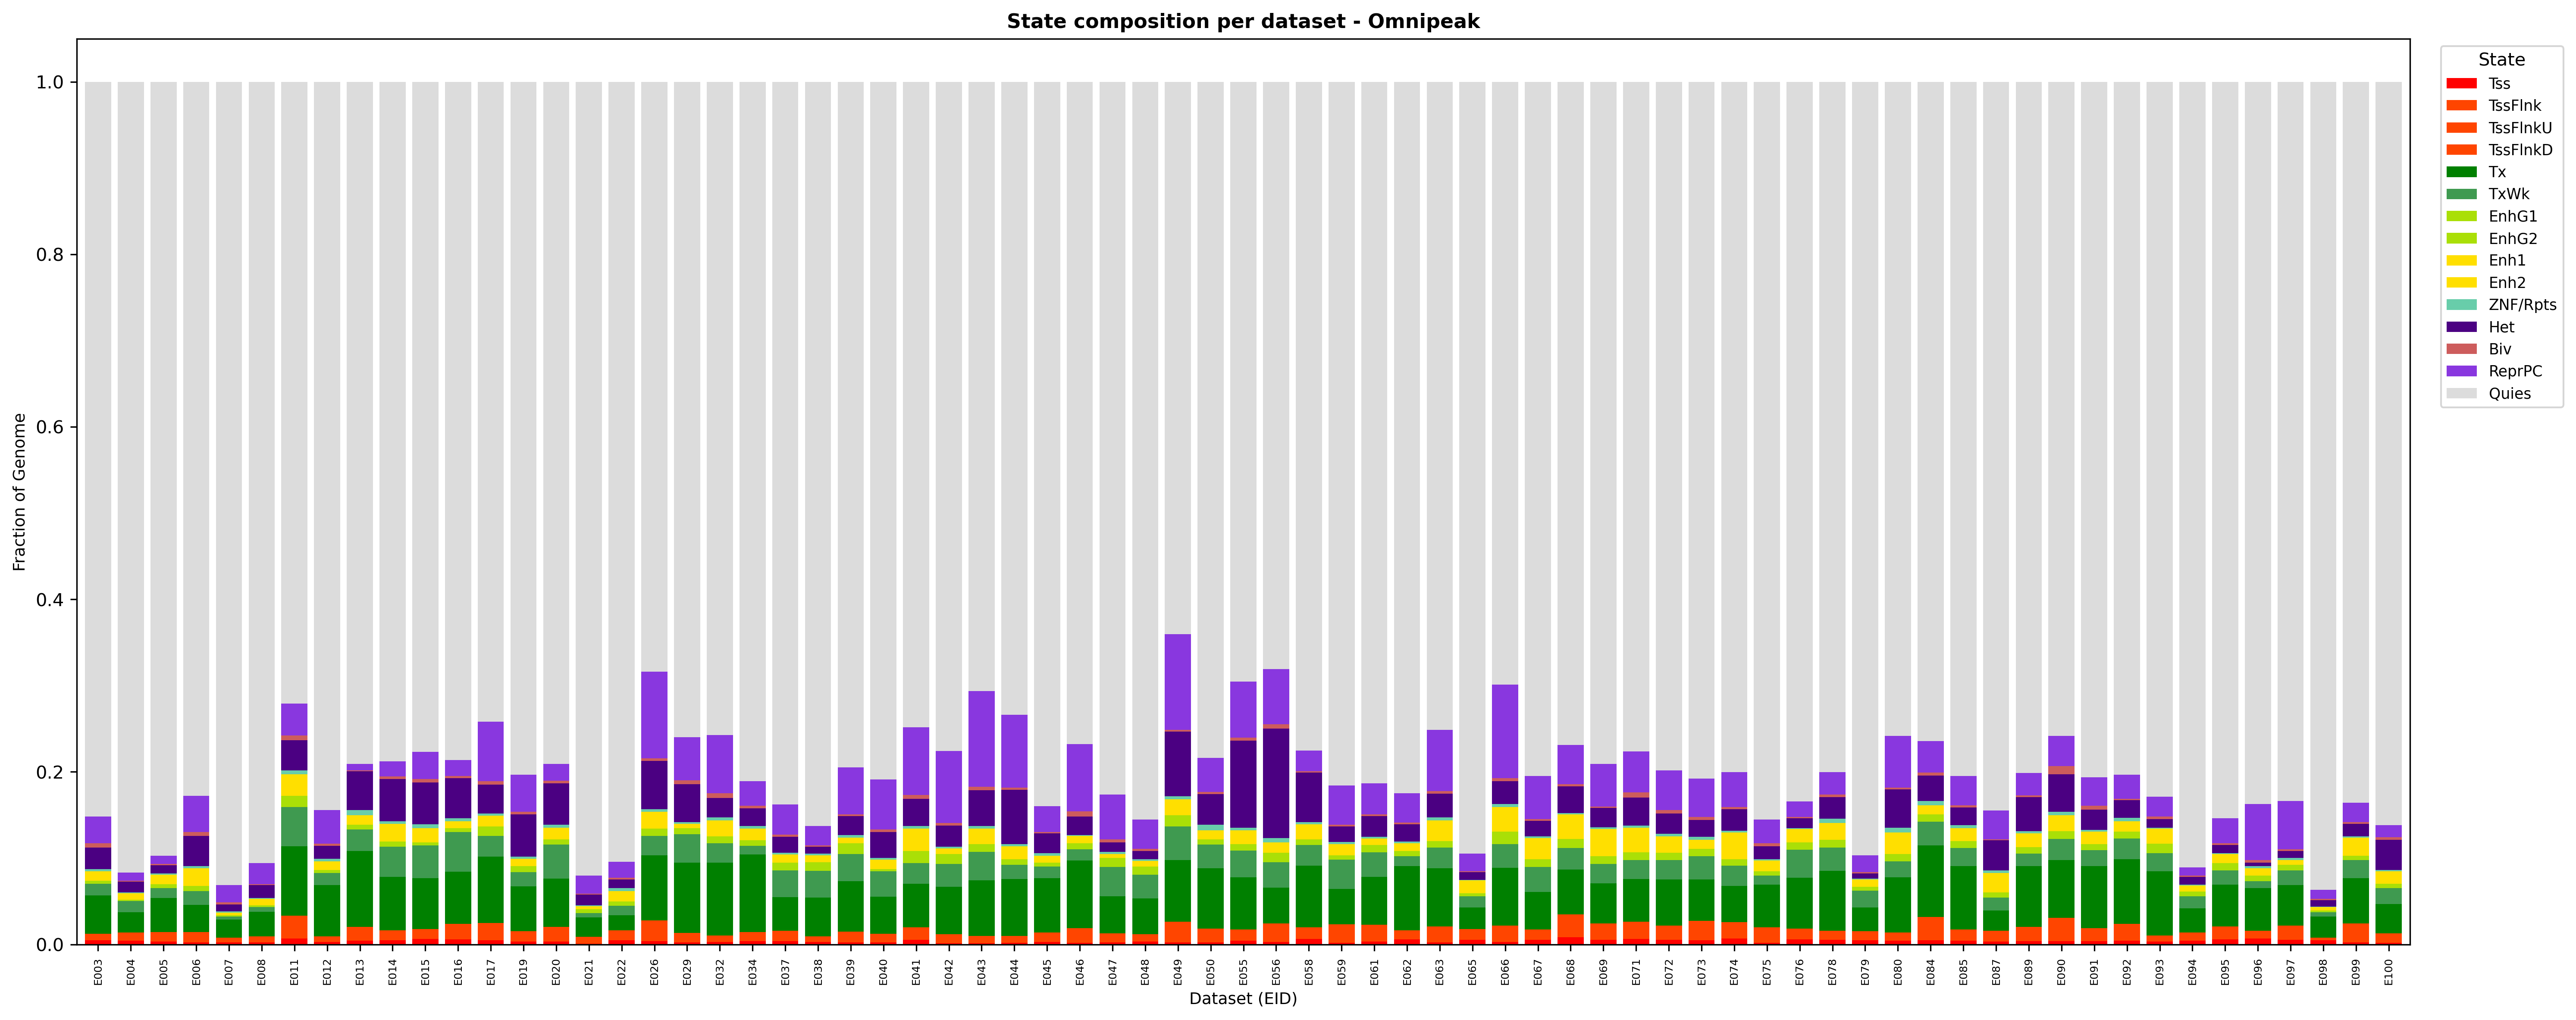

In [13]:
display(Image(filename="out/epi_1000/n_states.png"))
display(Image(filename="out/epi_1000/n_segments.png"))
display(Image(filename="out/epi_1000/avg_composition.png"))
display(Image(filename="out/epi_1000/avg_composition_stacked.png"))
display(Image(filename="out/epi_1000/entropy.png"))
display(Image(filename="out/epi_1000/entropy_noqh.png"))
display(Image(filename="out/epi_1000/pairwise_consistency_full_jaccard.png"))
display(Image(filename="out/epi_1000/pairwise_consistency_full_kappa.png"))
display(Image(filename="out/epi_1000/pairwise_consistency_noqh_jaccard.png"))
display(Image(filename="out/epi_1000/pairwise_consistency_noqh_kappa.png"))
for method in methods.keys():
    path = f"out/epi_1000/composition_{method.lower()}.png"
    if os.path.exists(path):
        display(Image(filename=path))

# Reference 18-state core K27ac segmentations

### 1. Identify files and compute/load stats

In [14]:
# 1. Identify files
epi_18_core_files = sorted(glob.glob(f"{EPI_1000_PATH}/E*_18_core_K27ac_dense.bed.gz"))
epi_18_core_ids = [os.path.basename(f).split("_")[0] for f in epi_18_core_files]

import json

def compute_pw_metrics_18(overlap, l1, l2):
    res = {}
    for mode in ["full", "noqh"]:
        excl = {"18_Quies", "13_Het"} if mode == "noqh" else set()
        states = (set(l1.keys()) | set(l2.keys())) - excl
        if not states:
            res[mode] = (0.0, 0.0)
            continue
        total_overlap_area = sum(overlap.get((s1, s2), 0) for s1 in states for s2 in states)
        if total_overlap_area == 0:
            res[mode] = (0.0, 0.0)
            continue
        po = sum(overlap.get((s, s), 0) for s in states) / total_overlap_area
        a1_s = {s: sum(overlap.get((s, s2), 0) for s2 in states) for s in states}
        a2_s = {s: sum(overlap.get((s1, s), 0) for s1 in states) for s in states}
        pe = sum((a1_s[s] / total_overlap_area) * (a2_s[s] / total_overlap_area) for s in states)
        kappa = (po - pe) / (1 - pe) if pe < 1 else 1.0
        jaccards = [overlap.get((s, s), 0) / (a1_s[s] + a2_s[s] - overlap.get((s, s), 0))
                    for s in states if (a1_s[s] + a2_s[s] - overlap.get((s, s), 0)) > 0]
        res[mode] = (np.mean(jaccards) if jaccards else 0.0, kappa)
    return res

def get_file_stats_18(f, segs):
    eid = os.path.basename(f).split("_")[0]
    n_segments = len(segs)
    lengths = match.state_lengths(segs)
    total = sum(lengths.values())
    composition = [{"State": s, "Fraction": l / total if total > 0 else 0} for s, l in lengths.items()]
    entropy = {}
    segs4 = [(r[0], r[1], r[2], r[3]) for r in segs]
    for mode in ["full", "noqh"]:
        excl = {"18_Quies", "13_Het"} if mode == "noqh" else set()
        states, counts, state_bp = analyze.build_transition_matrix(segs4, 200, exclude_states=excl)
        entropy[mode] = analyze.transition_entropy(states, counts, state_bp)[0] if states else 0
    colors = {name: analyze.rgb_str_to_hex(color) for _, _, _, name, color in segs}
    return eid, {"n_segments": n_segments, "composition": composition, "entropy": entropy, "colors": colors, "lengths": lengths}

# Lazy compute stats if missing
loaded_segs_18 = None
per_file_stats = None

def ensure_segs_18():
    global loaded_segs_18
    if loaded_segs_18 is None:
        print("Loading BED files for all datasets...")
        with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
            segs_list = list(tqdm(executor.map(match.load_bed, epi_18_core_files), total=len(epi_18_core_files)))
        loaded_segs_18 = dict(zip(epi_18_core_ids, segs_list))

def get_stats_18_if_needed():
    global per_file_stats
    if per_file_stats is None:
        ensure_segs_18()
        print("Computing per-file stats...")
        per_file_stats = {}
        for f, eid in tqdm(zip(epi_18_core_files, epi_18_core_ids)):
            segs = loaded_segs_18[eid]
            _, stats = get_file_stats_18(f, segs)
            per_file_stats[eid] = stats

if os.path.exists("out/epi_1000/df_segments_18.csv"):
    df_segments_18 = pd.read_csv("out/epi_1000/df_segments_18.csv")
else:
    get_stats_18_if_needed()
    df_segments_18 = pd.DataFrame([{"Dataset": eid, "N_Segments": v["n_segments"]} for eid, v in per_file_stats.items()])
    df_segments_18.to_csv("out/epi_1000/df_segments_18.csv", index=False)

if os.path.exists("out/epi_1000/df_comp_18.csv"):
    df_comp_18 = pd.read_csv("out/epi_1000/df_comp_18.csv")
else:
    get_stats_18_if_needed()
    df_comp_18 = pd.DataFrame([{"Dataset": eid, "State": c["State"], "Fraction": c["Fraction"]} 
                                for eid, v in per_file_stats.items() for c in v["composition"]])
    df_comp_18.to_csv("out/epi_1000/df_comp_18.csv", index=False)

if os.path.exists("out/epi_1000/df_entropy_18.csv"):
    df_entropy_18 = pd.read_csv("out/epi_1000/df_entropy_18.csv")
else:
    get_stats_18_if_needed()
    df_entropy_18 = pd.DataFrame([{"Dataset": eid, "Mode": m.upper(), "Entropy": val} 
                                   for eid, info in per_file_stats.items() for m, val in info["entropy"].items()])
    df_entropy_18.to_csv("out/epi_1000/df_entropy_18.csv", index=False)

if os.path.exists("out/epi_1000/state_colors_18.json"):
    with open("out/epi_1000/state_colors_18.json", "r") as f:
        state_colors_18 = json.load(f)
else:
    get_stats_18_if_needed()
    state_colors_18 = {}
    for v in per_file_stats.values():
        state_colors_18.update(v["colors"])
    with open("out/epi_1000/state_colors_18.json", "w") as f:
        json.dump(state_colors_18, f)

# 3. Pairwise metrics
if os.path.exists("out/epi_1000/df_pw_18.csv"):
    df_pw_18 = pd.read_csv("out/epi_1000/df_pw_18.csv")
else:
    ensure_segs_18()
    print("Computing pairwise overlaps for all pairs...")
    loaded_lengths = {eid: match.state_lengths(segs) for eid, segs in loaded_segs_18.items()}
    
    pairs = [tuple(sorted((id1, id2))) for i, id1 in enumerate(epi_18_core_ids) for id2 in epi_18_core_ids[i+1:]]
    with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
        overlap_results = list(tqdm(executor.map(match.pair_overlap, [loaded_segs_18[p[0]] for p in pairs], 
                                                [loaded_segs_18[p[1]] for p in pairs]), total=len(pairs)))
    
    pw_data_18 = []
    for pair, overlap in zip(pairs, overlap_results):
        id1, id2 = pair
        metrics = compute_pw_metrics_18(overlap, loaded_lengths[id1], loaded_lengths[id2])
        for mode, (jaccard, kappa) in metrics.items():
            pw_data_18.append({"Dataset1": id1, "Dataset2": id2, "Mode": mode.upper(), "Jaccard": jaccard, "Kappa": kappa})
    df_pw_18 = pd.DataFrame(pw_data_18)
    df_pw_18.to_csv("out/epi_1000/df_pw_18.csv", index=False)


### 2. Plotting

In [15]:
# 1) Segments number distribution
plt.figure(figsize=(3, 4))
ax = plt.gca()
sns.barplot(x=["18-core"] * len(df_segments_18), y=df_segments_18["N_Segments"], color='skyblue', capsize=0.1, errorbar="se", ax=ax)
ax.set_title("Distribution of segment numbers (18-state core K27ac)", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of segments", fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Add label over error bar
m = df_segments_18["N_Segments"].mean()
s = df_segments_18["N_Segments"].sem()
yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
ax.text(0, m + s + 0.01 * yrange, f"{m:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("out/epi_1000/epi_18_core_segments_dist.png", bbox_inches="tight")
plt.close()


# Custom sort for 18-state names (e.g., 1_TssA, 10_TssB, 2_TssAFlnk)
def sort_states_18(states):
    return sorted(states, key=lambda x: int(x.split('_')[0]) if '_' in x and x.split('_')[0].isdigit() else 999)


# Sort states and prepare colors
all_states_18 = sort_states_18(df_comp_18['State'].unique())
# Create color list for pandas stacked bar plot (maintains order)
colors_18 = [state_colors_18.get(s, "#888888") for s in all_states_18]

# 2) State composition per dataset
pivot_comp_18 = df_comp_18.pivot(index='Dataset', columns='State', values='Fraction').fillna(0)
pivot_comp_18 = pivot_comp_18[all_states_18]  # Reorder columns
plt.figure(figsize=(15, 6))
ax = pivot_comp_18.plot(kind='bar', stacked=True, ax=plt.gca(), width=0.8, color=colors_18)
ax.set_title("State composition per dataset (18-state core K27ac)", fontsize=11, fontweight="bold")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='x-small', title="State")
ax.set_xlabel("Dataset", fontsize=9)
ax.set_ylabel("Fraction of Genome", fontsize=9)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("out/epi_1000/epi_18_core_composition_per_dataset.png", bbox_inches="tight")
plt.close()

# 3) Average composition
avg_comp_18 = df_comp_18.groupby('State')['Fraction'].mean().reindex(all_states_18)
plt.figure(figsize=(10, 5))
# Use sns.barplot with dictionary palette for robust color mapping
ax = sns.barplot(x=avg_comp_18.index, y=avg_comp_18.values, hue=avg_comp_18.index, palette=state_colors_18,
                 legend=False)
ax.set_title("Average state composition (18-state core K27ac)", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Fraction of Genome", fontsize=9)
ax.set_xlabel("State", fontsize=9)
ax.set_xticklabels(all_states_18, rotation=45, ha="right", fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("out/epi_1000/epi_18_core_avg_composition.png", bbox_inches="tight")
plt.close()

# 4) Pairwise consistency plots
for mode in ["FULL", "NOQH"]:
    for metric in ["Jaccard", "Kappa"]:
        fig, ax = plt.subplots(figsize=(3, 4))
        df_mode = df_pw_18[df_pw_18["Mode"] == mode]
        sns.barplot(x=["18-core"] * len(df_mode), y=df_mode[metric], color='lightgreen', capsize=0.1, errorbar="se",
                    ax=ax)
        ax.set_title(f"Pairwise {metric} consistency ({mode}) - 18-core", fontsize=11, fontweight="bold")
        ax.set_ylabel(f"{metric} index", fontsize=9)
        ax.grid(axis="y", alpha=0.3)

        # Add label over error bar
        m = df_mode[metric].mean()
        s = df_mode[metric].sem()
        yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
        ax.text(0, m + s + 0.01 * yrange, f"{m:.2f}", ha="center", va="bottom", fontsize=8)

        fig.tight_layout()
        fig.savefig(f"out/epi_1000/epi_18_core_pw_{mode.lower()}_{metric.lower()}.png", bbox_inches="tight")
        plt.close(fig)

# 5) Transition entropy plots
for mode in ["FULL", "NOQH"]:
    plt.figure(figsize=(3, 4))
    ax = plt.gca()
    df_mode = df_entropy_18[df_entropy_18["Mode"] == mode]
    sns.barplot(x=["18-core"] * len(df_mode), y=df_mode["Entropy"], color='lightcoral', capsize=0.1, errorbar="se", ax=ax)
    mode_label = "(Full)" if mode == "FULL" else "(Excl. Quies/Het)"
    ax.set_title(f"Transition Entropy {mode_label}\n(18-state core K27ac)", fontsize=11, fontweight="bold")
    ax.set_ylabel("Entropy (bits)", fontsize=9)
    ax.grid(axis='y', alpha=0.3)

    # Add label over error bar
    m = df_mode["Entropy"].mean()
    s = df_mode["Entropy"].sem()
    yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
    ax.text(0, m + s + 0.01 * yrange, f"{m:.3f}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.savefig(f"out/epi_1000/epi_18_core_entropy_{mode.lower()}.png", bbox_inches="tight")
    plt.close()


/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/1457989735.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(all_states_18, rotation=45, ha="right", fontsize=8)


### 3. Show images

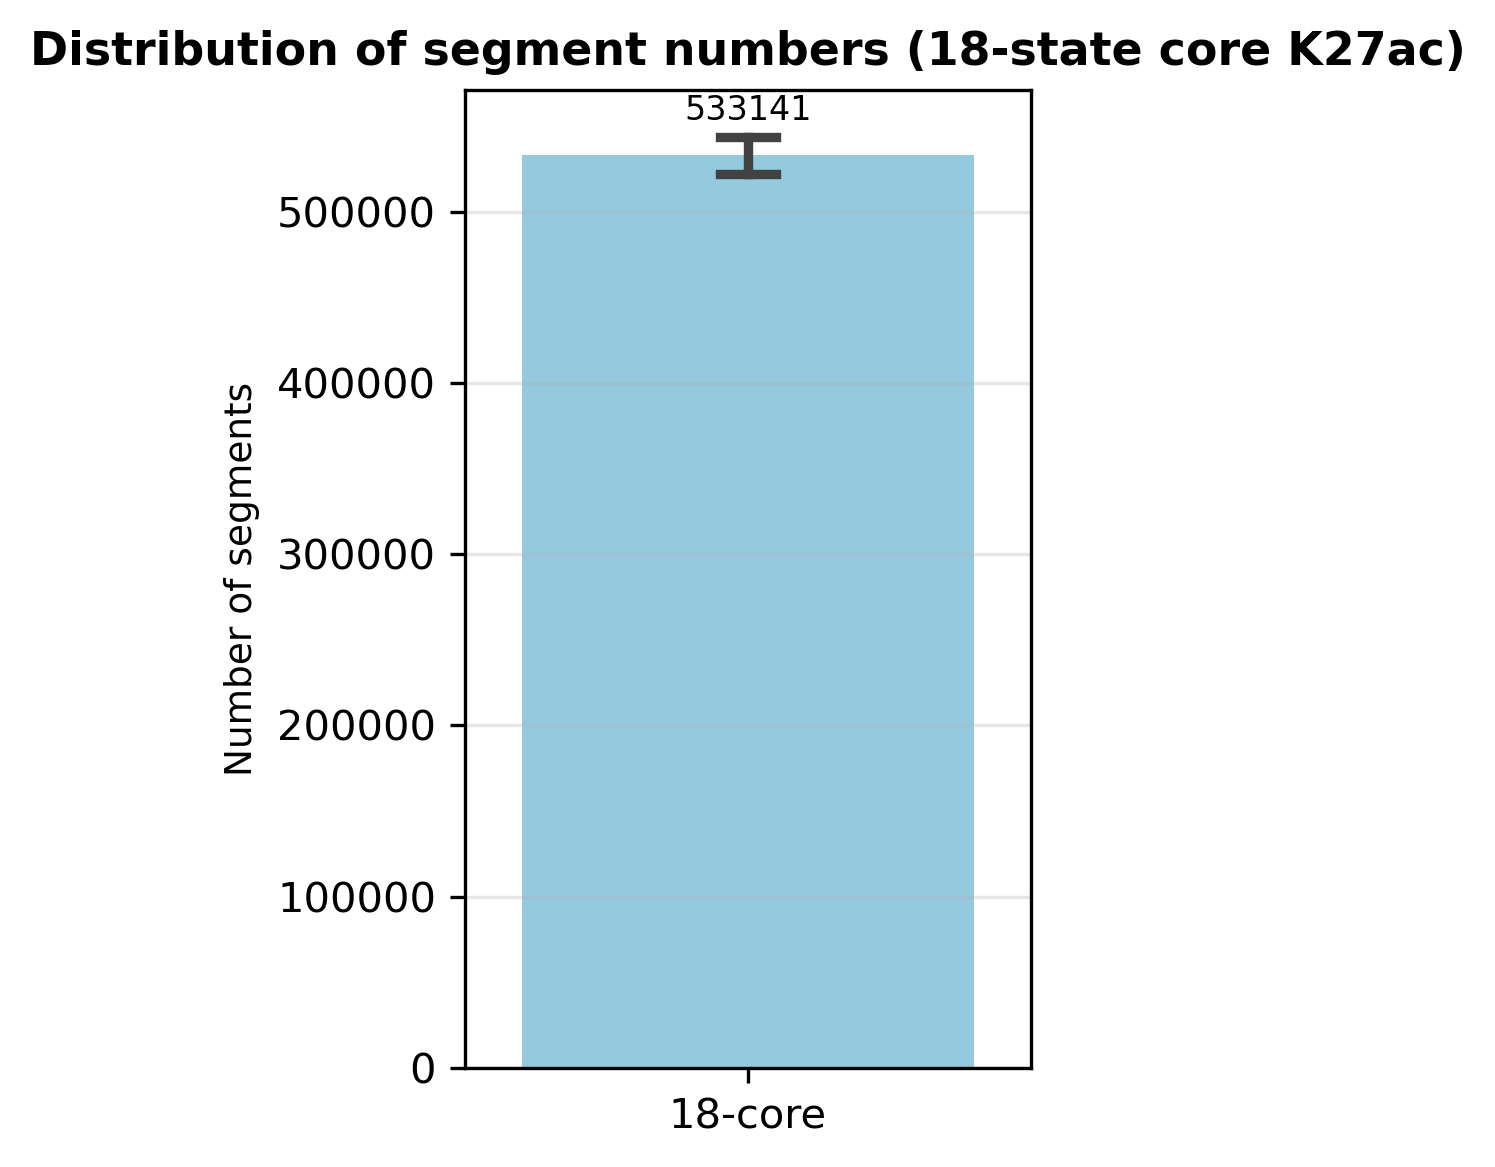

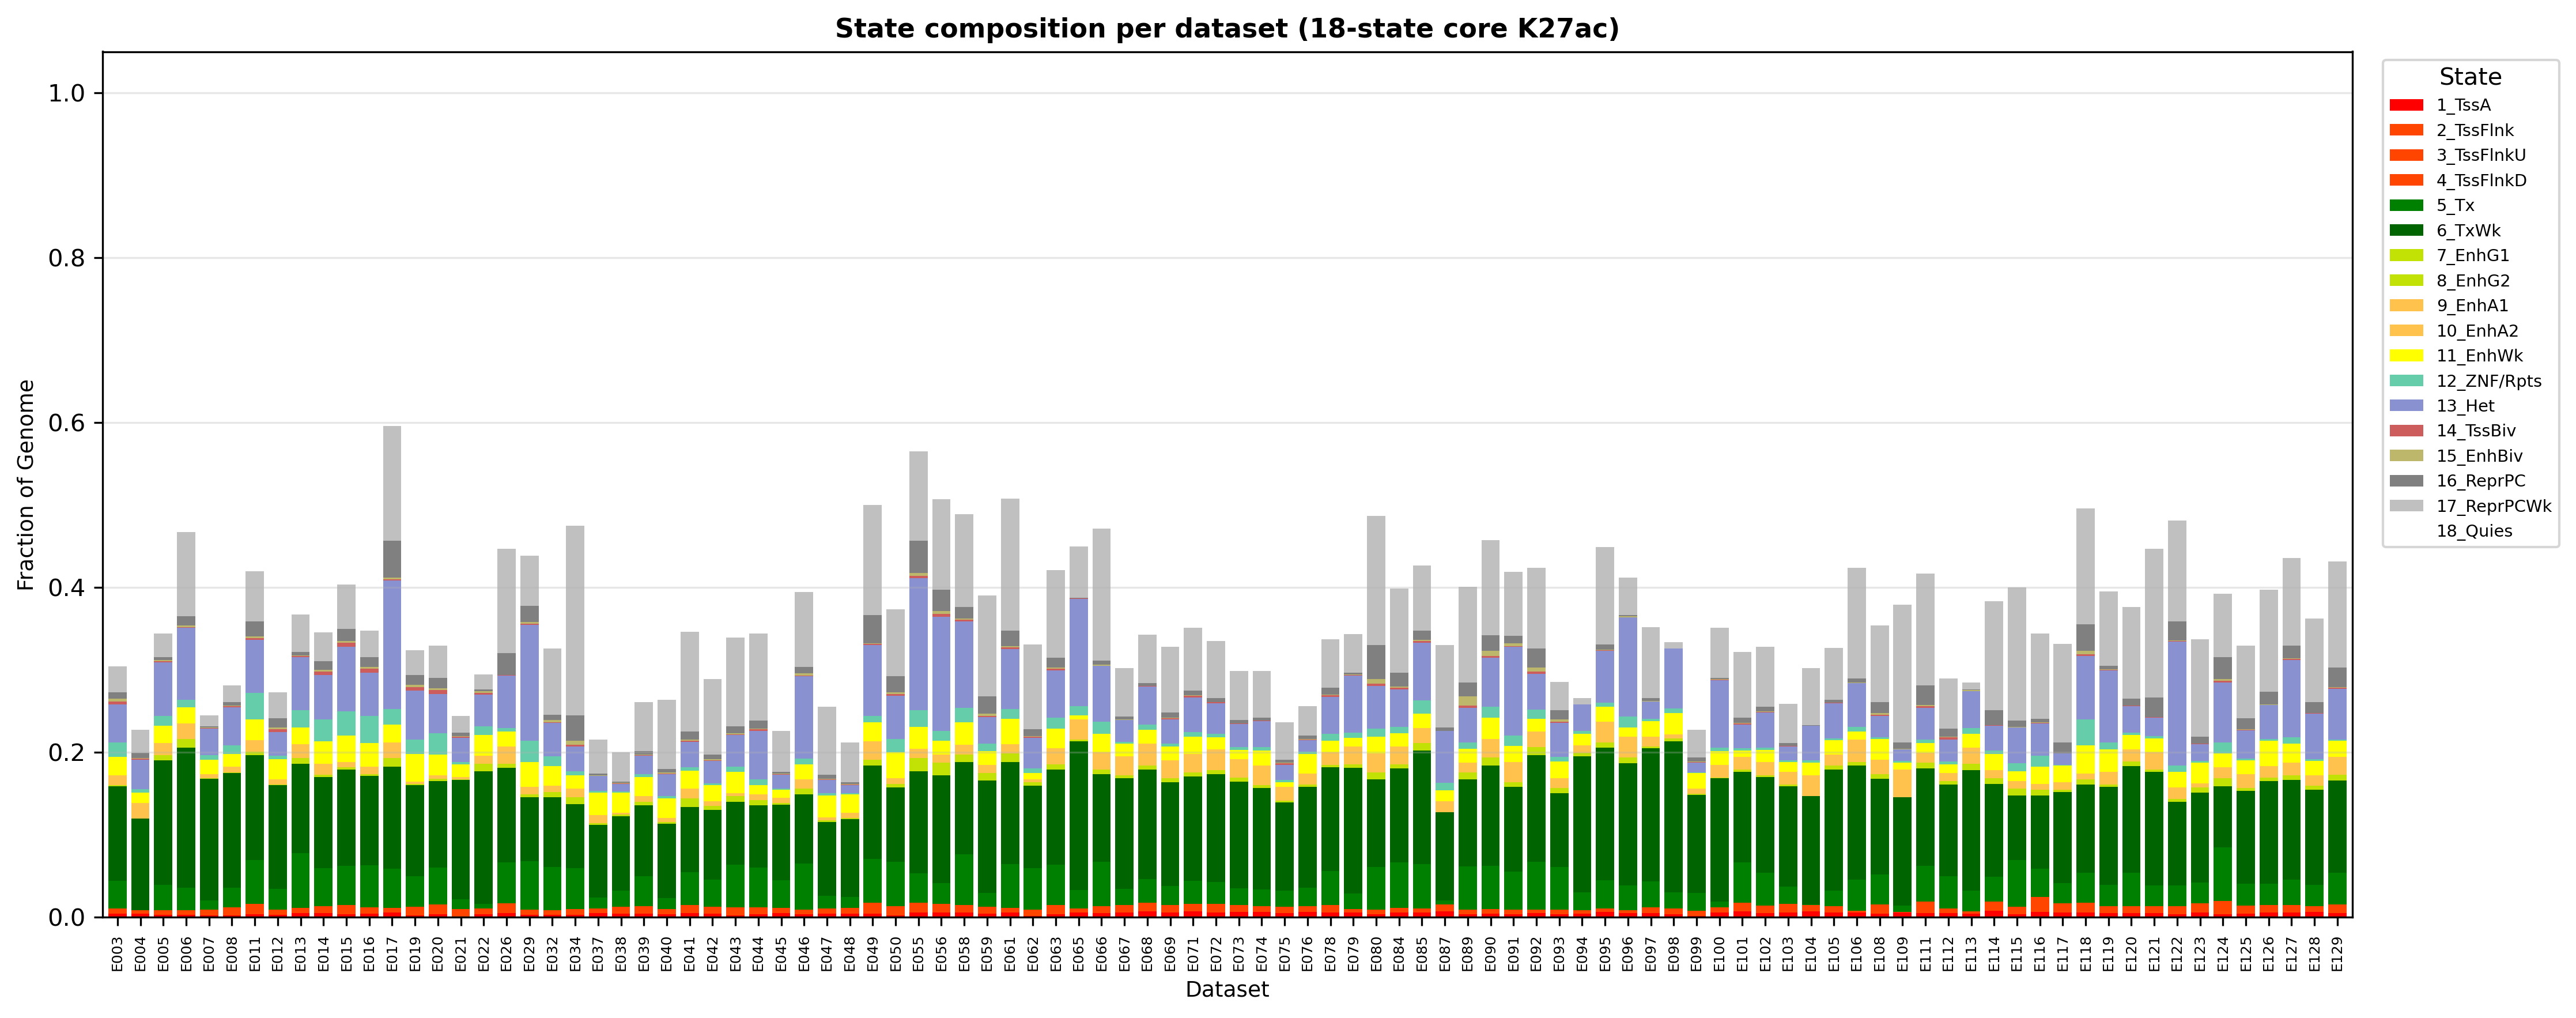

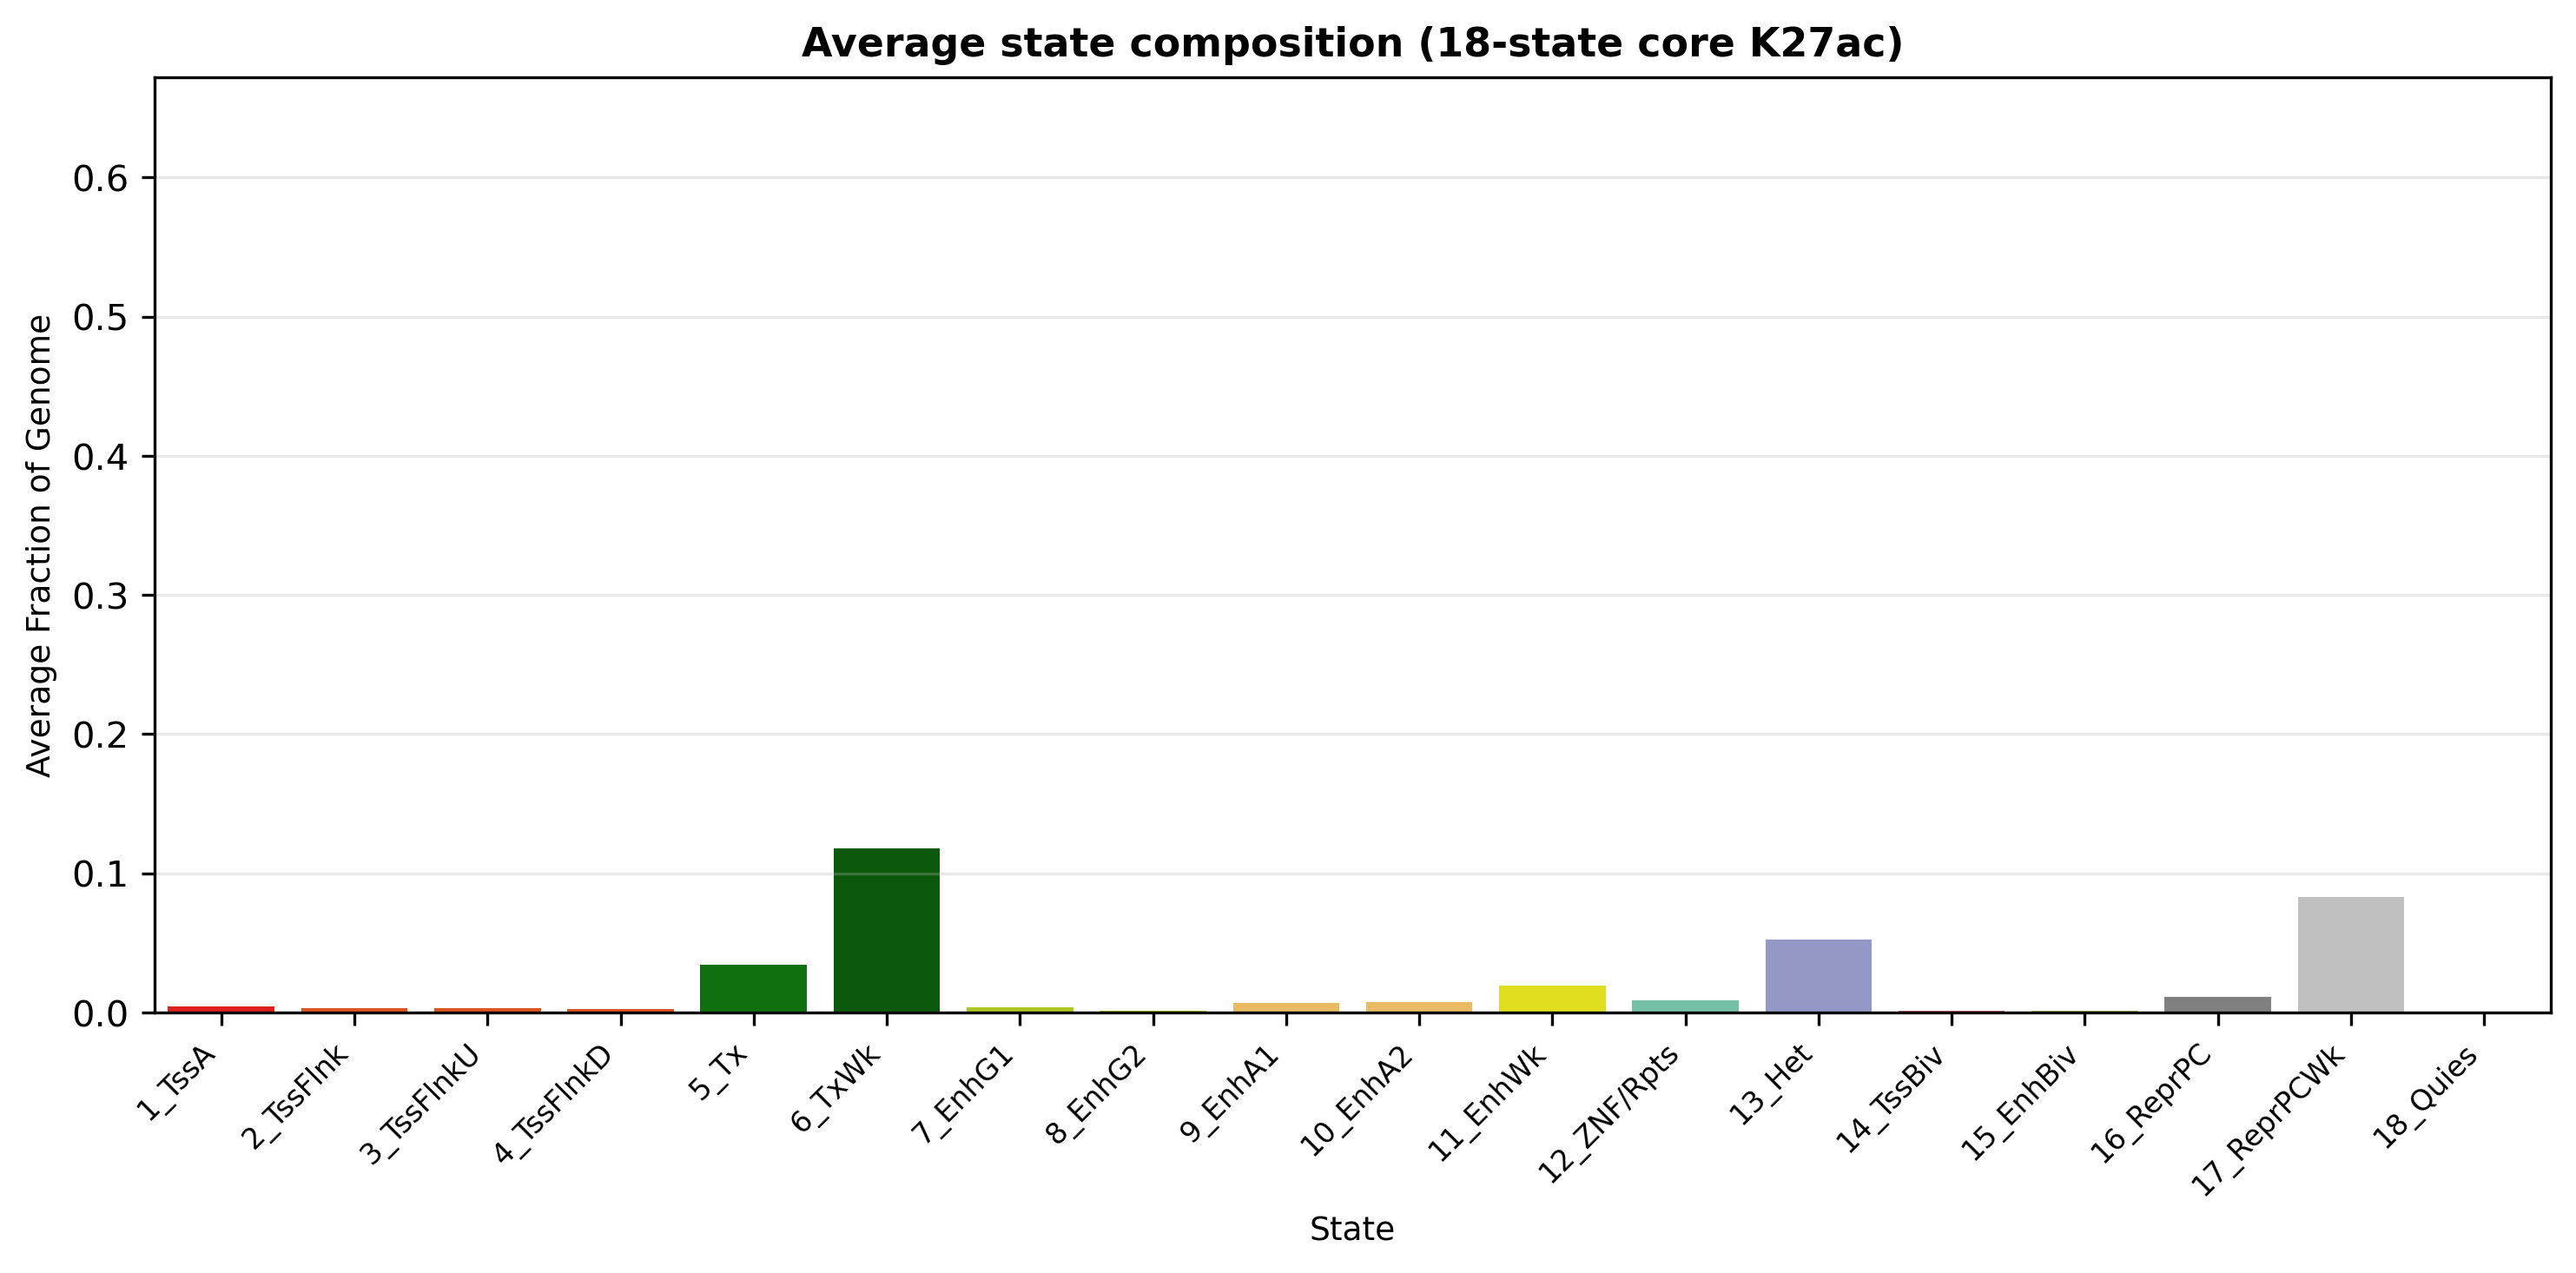

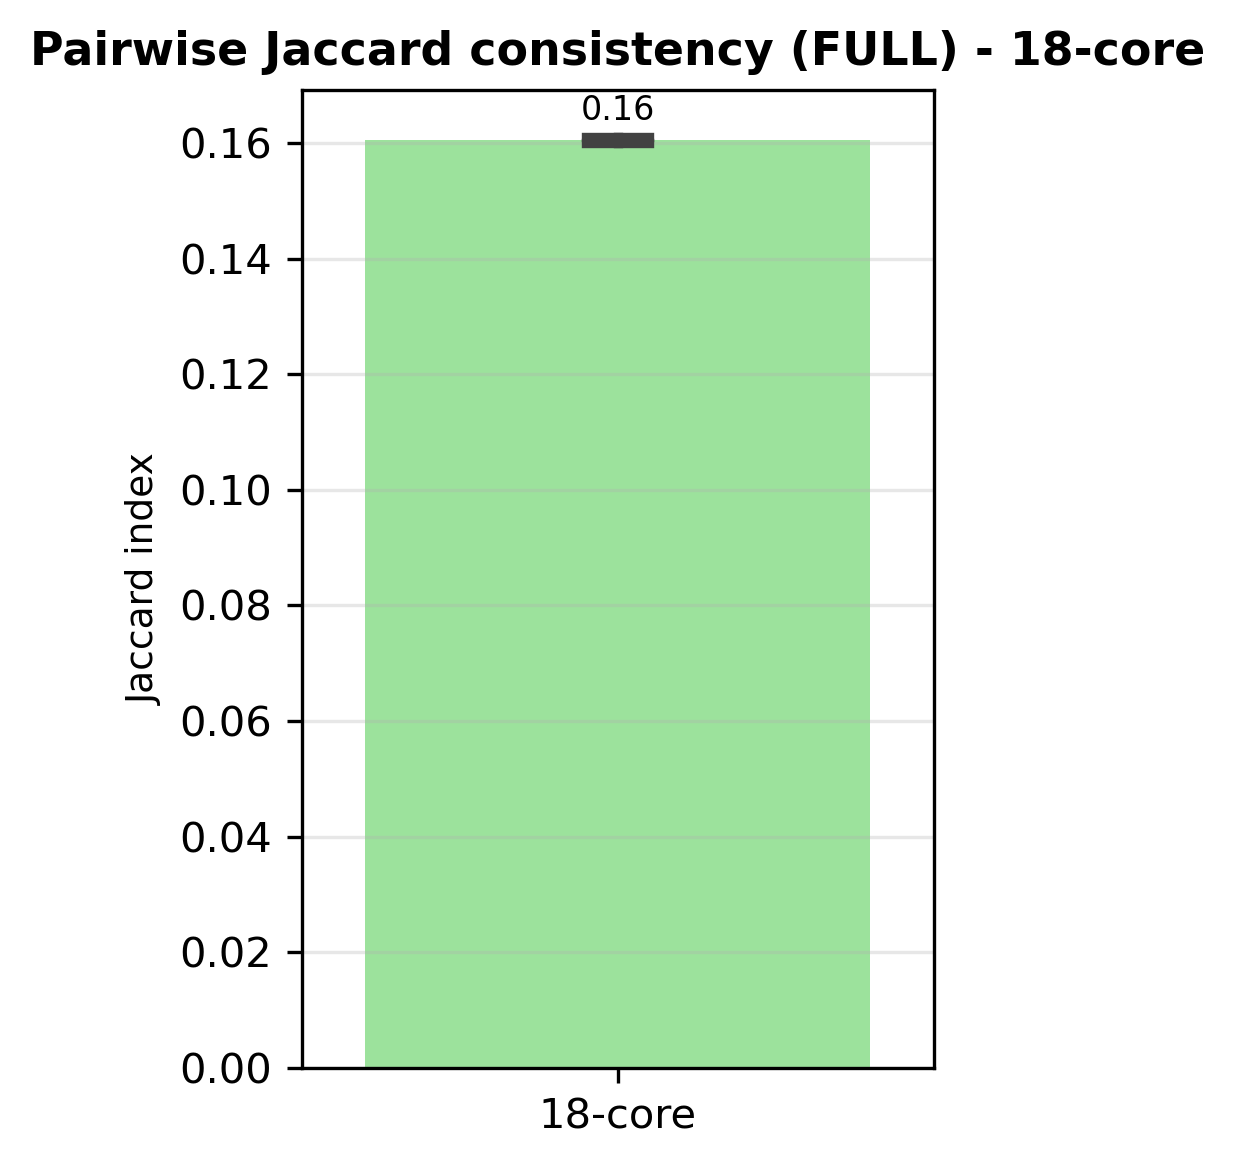

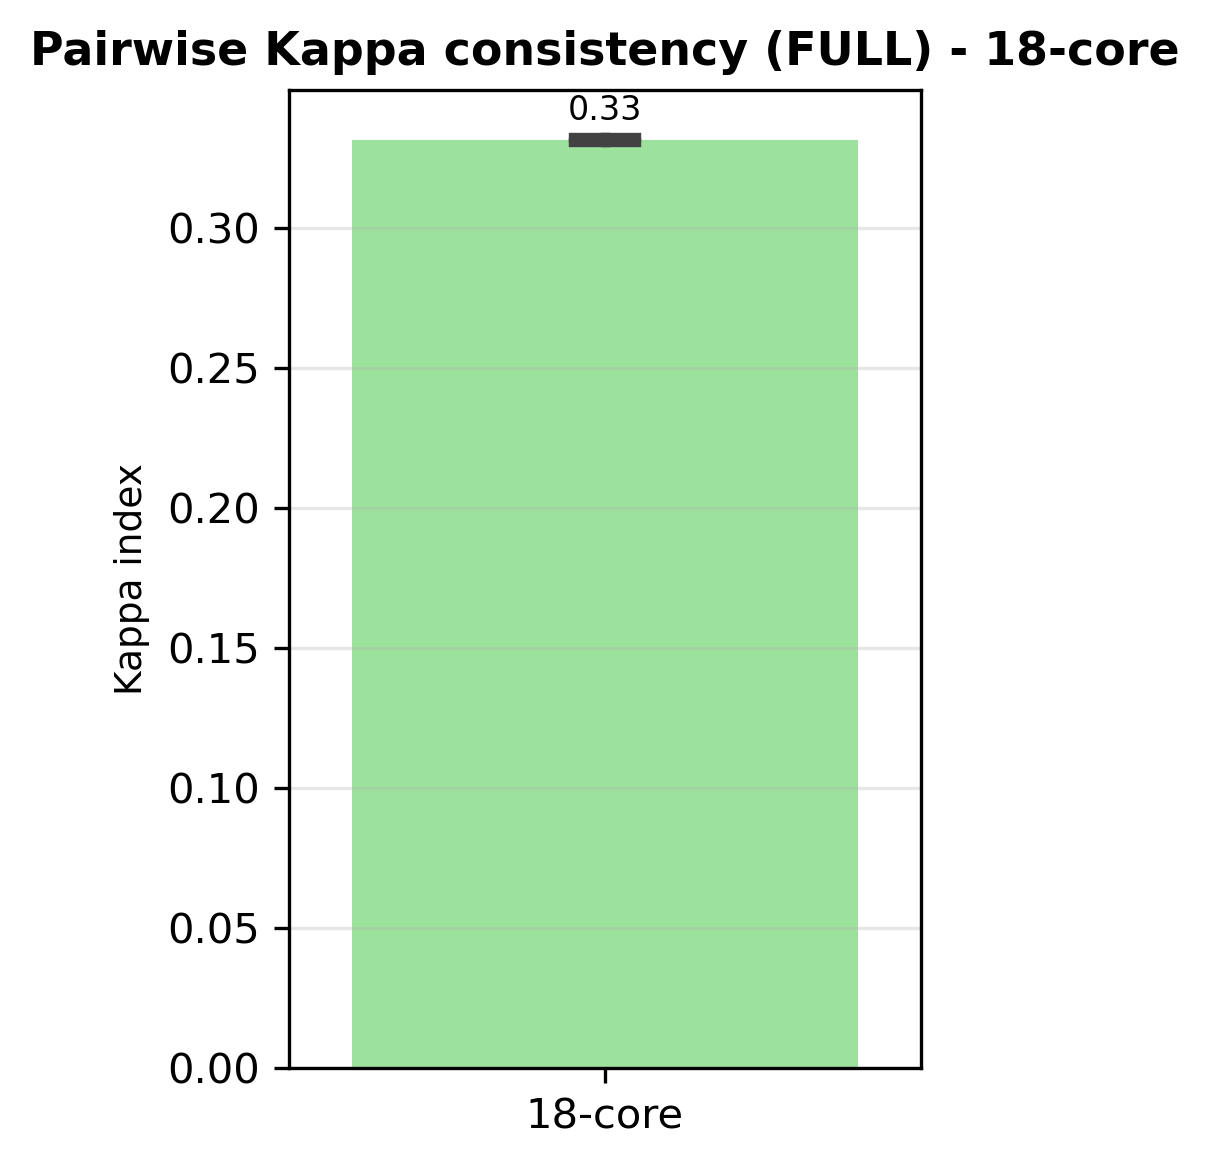

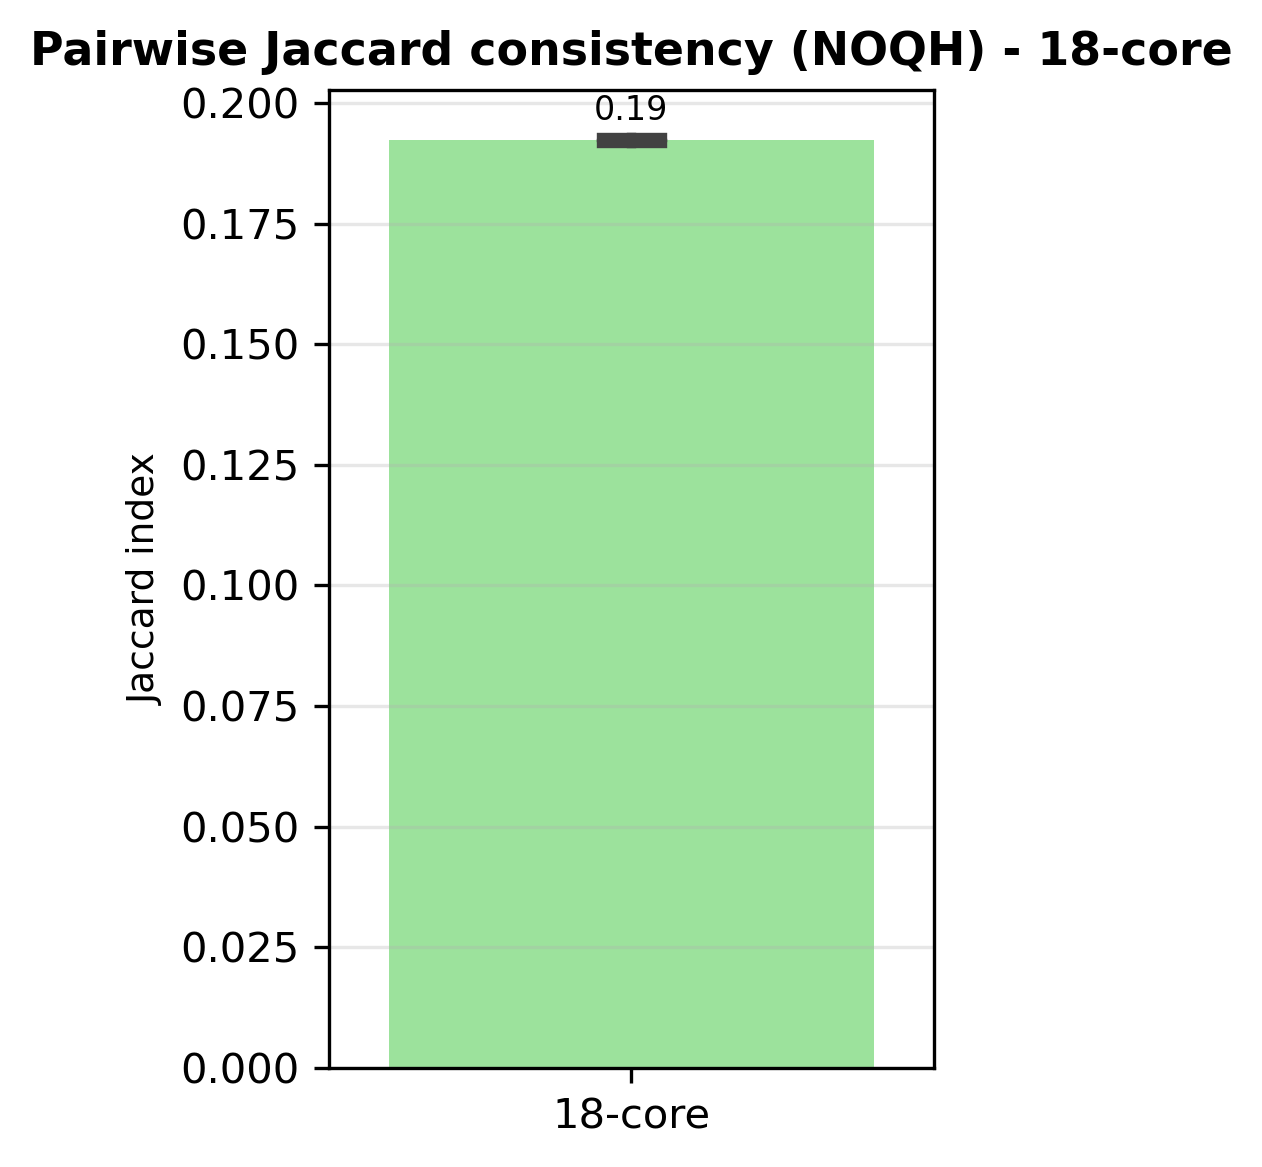

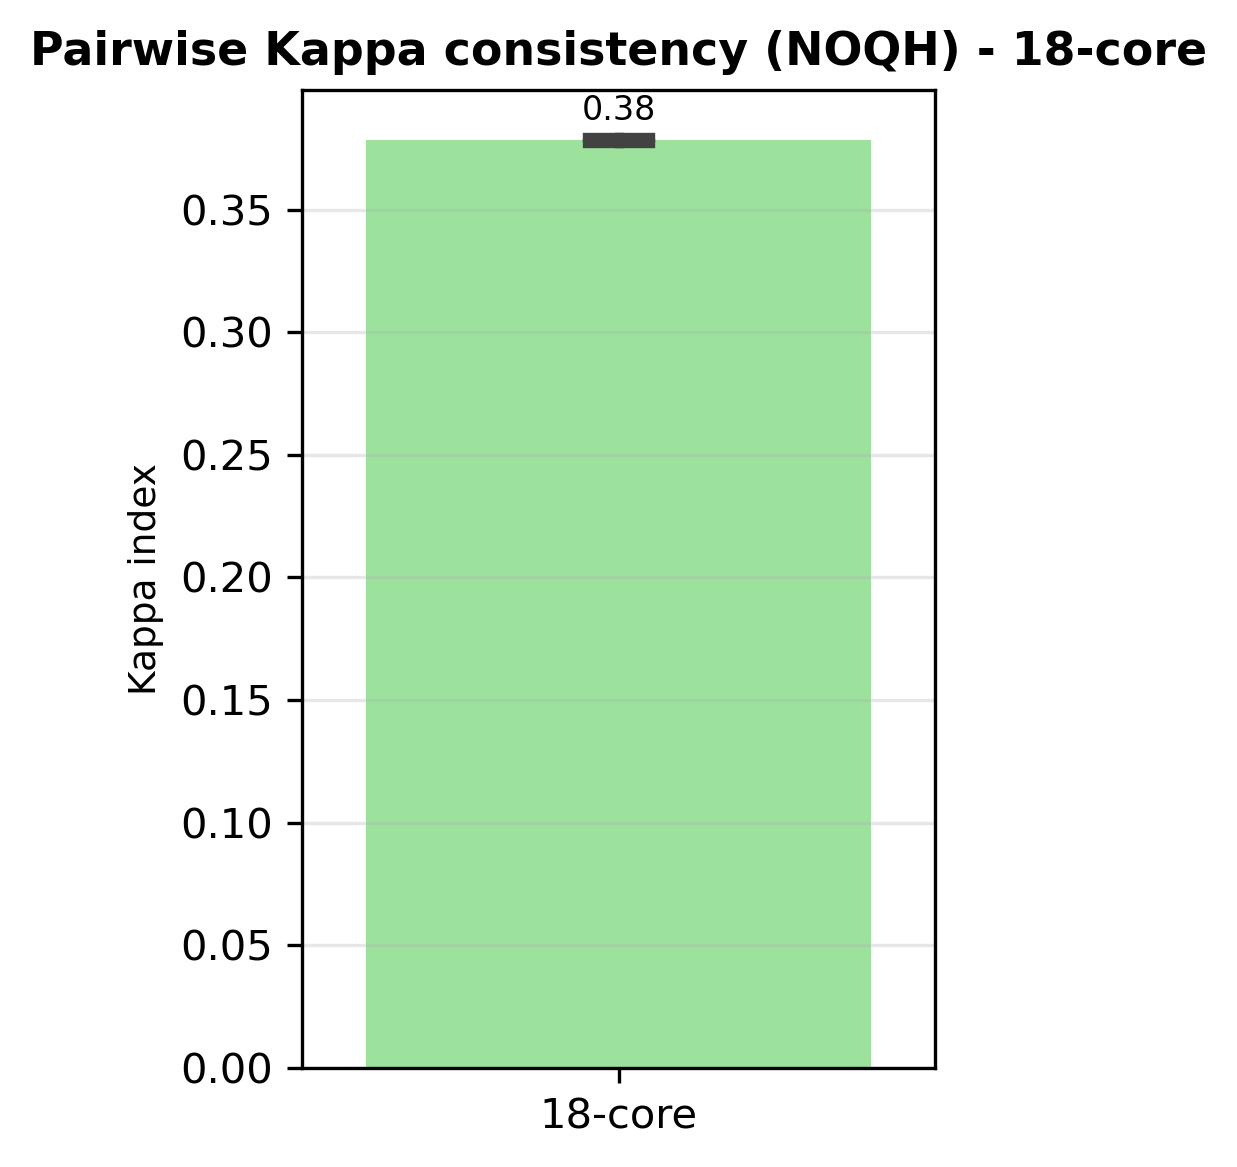

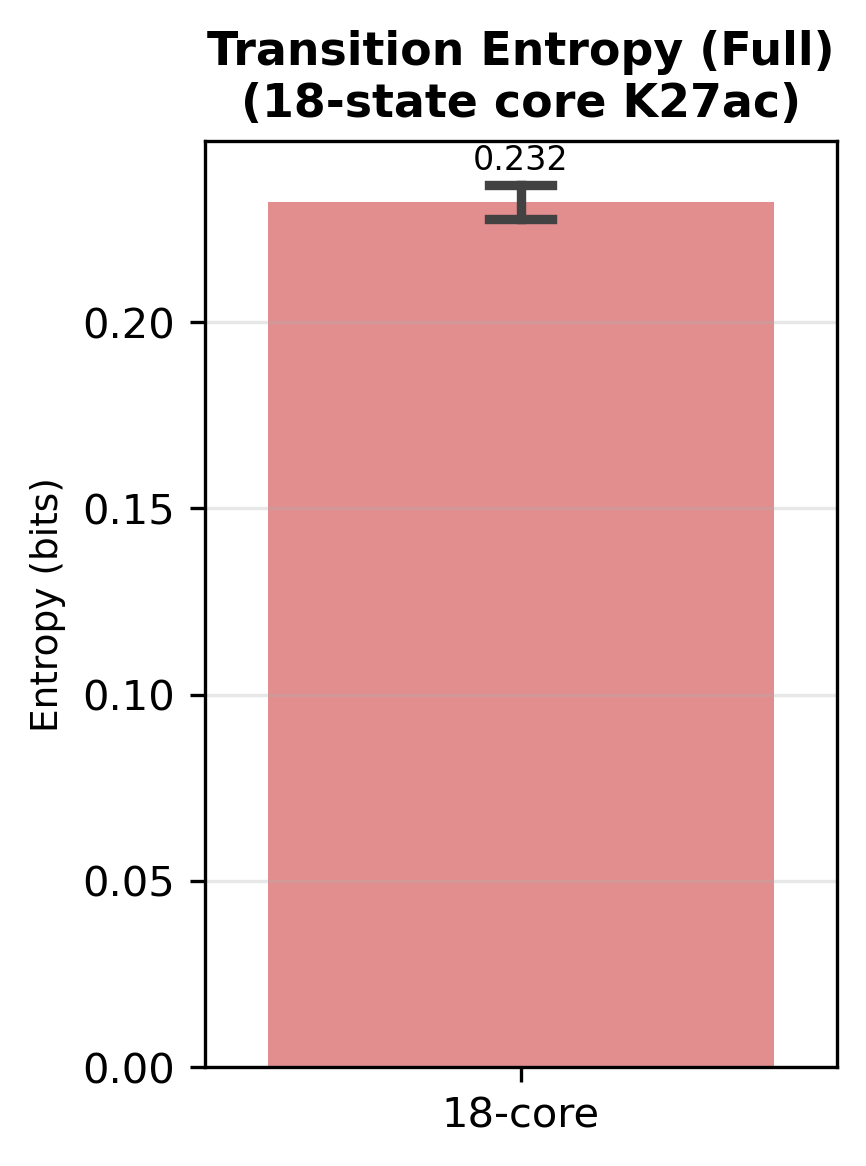

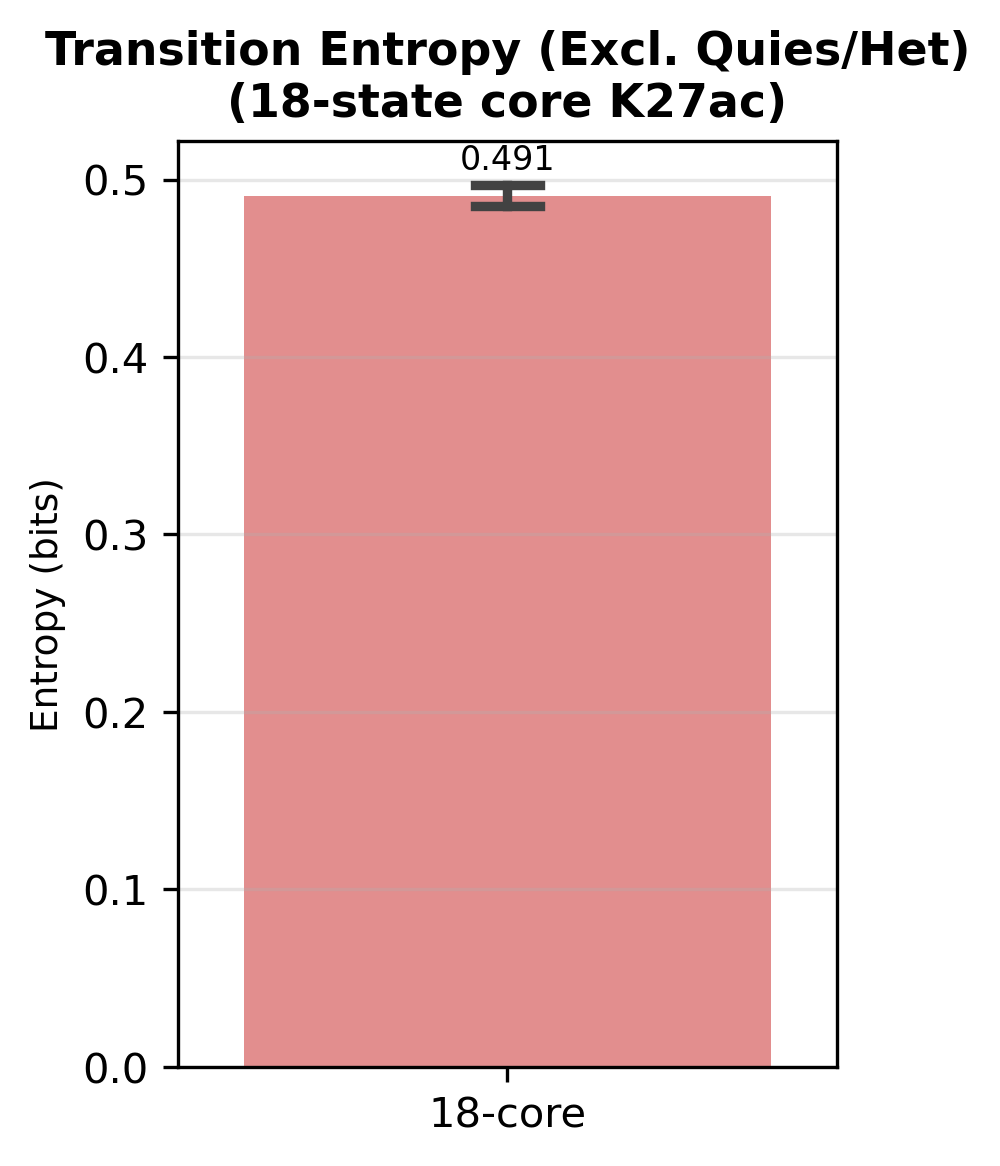

In [16]:
display(Image(filename="out/epi_1000/epi_18_core_segments_dist.png"))
display(Image(filename="out/epi_1000/epi_18_core_composition_per_dataset.png"))
display(Image(filename="out/epi_1000/epi_18_core_avg_composition.png"))
for mode in ["FULL", "NOQH"]:
    for metric in ["Jaccard", "Kappa"]:
        display(Image(filename=f"out/epi_1000/epi_18_core_pw_{mode.lower()}_{metric.lower()}.png"))
for mode in ["full", "noqh"]:
    display(Image(filename=f"out/epi_1000/epi_18_core_entropy_{mode.lower()}.png"))

# 15 states core models joint reordered vs inidividual remapped

### 1. Identify files and compute/load stats

In [20]:
# 1. Identify files
joint_15_files = sorted(glob.glob(f"{EPI_1000_PATH}/E*_15_coreMarks_dense_joint_reodered.bed.gz"))
indiv_15_files = sorted(glob.glob(f"{EPI_1000_PATH}/E*_15_coreMarks_dense_matched.bed"))

joint_15_ids_map = {os.path.basename(f).split("_")[0]: f for f in joint_15_files}
indiv_15_ids_map = {os.path.basename(f).split("_")[0]: f for f in indiv_15_files}

common_15_ids = sorted(list(set(joint_15_ids_map.keys()) & set(indiv_15_ids_map.keys())))
print(f"Found {len(common_15_ids)} common samples for 15-state models")

def get_file_stats_15_raw(f, segs):
    eid = os.path.basename(f).split("_")[0]
    n_segments = len(segs)
    lengths = match.state_lengths(segs)
    total = sum(lengths.values())
    composition = [{"State": s, "Fraction": l / total if total > 0 else 0} for s, l in lengths.items()]
    colors = {name: analyze.rgb_str_to_hex(color) for _, _, _, name, color in segs}
    return {"Dataset": eid, "n_segments": n_segments, "composition": composition, "colors": colors}

# 2. Computation / Loading
os.makedirs("out/epi_1000/cache_15", exist_ok=True)
results_15 = []
files_to_compute = []
meta_to_compute = []

# Check if aggregated results already exist
if os.path.exists("out/epi_1000/df_segments_15.csv") and \
   os.path.exists("out/epi_1000/df_comp_15.csv") and \
   os.path.exists("out/epi_1000/state_colors_15.json"):
    print("Loading 15-state results from aggregated files...")
    df_segments_15 = pd.read_csv("out/epi_1000/df_segments_15.csv")
    df_comp_15 = pd.read_csv("out/epi_1000/df_comp_15.csv")
    with open("out/epi_1000/state_colors_15.json", "r") as f:
        state_colors_15 = json.load(f)
else:
    for eid in common_15_ids:
        for t_name, f_map in [("Joint", joint_15_ids_map), ("Individual", indiv_15_ids_map)]:
            cache_path = f"out/epi_1000/cache_15/{eid}_{t_name}.json"
            if os.path.exists(cache_path):
                with open(cache_path, "r") as fc:
                    results_15.append(json.load(fc))
            else:
                files_to_compute.append(f_map[eid])
                meta_to_compute.append((eid, t_name))

    if files_to_compute:
        print(f"Computing stats for {len(files_to_compute)} files...")
        with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
            segs_list = list(tqdm(executor.map(match.load_bed, files_to_compute), total=len(files_to_compute)))
        
        for (eid, t_name), f, segs in zip(meta_to_compute, files_to_compute, segs_list):
            stats = get_file_stats_15_raw(f, segs)
            stats["Type"] = t_name
            cache_path = f"out/epi_1000/cache_15/{eid}_{t_name}.json"
            with open(cache_path, "w") as fc:
                json.dump(stats, fc)
            results_15.append(stats)

    df_segments_15 = pd.DataFrame([{"Dataset": r["Dataset"], "Type": r["Type"], "N_Segments": r["n_segments"]} for r in results_15])
    df_comp_15 = pd.DataFrame([{"Dataset": r["Dataset"], "Type": r["Type"], "State": c["State"], "Fraction": c["Fraction"]} 
                                for r in results_15 for c in r["composition"]])
    state_colors_15 = {}
    for r in results_15:
        state_colors_15.update(r["colors"])

    # Save aggregated results
    df_segments_15.to_csv("out/epi_1000/df_segments_15.csv", index=False)
    df_comp_15.to_csv("out/epi_1000/df_comp_15.csv", index=False)
    with open("out/epi_1000/state_colors_15.json", "w") as f:
        json.dump(state_colors_15, f)


Found 20 common samples for 15-state models
Loading 15-state results from aggregated files...


### 2. Plotting 15-state models

In [21]:
# 1) Segments number distribution
plt.figure(figsize=(4, 4))
ax = plt.gca()
sns.barplot(data=df_segments_15, x="Type", y="N_Segments", order=["Individual", "Joint"], palette={"Joint": "skyblue", "Individual": "lightcoral"}, capsize=0.1, errorbar="se", ax=ax)
ax.set_title("Distribution of segment numbers (15-state)", fontsize=11, fontweight="bold")
ax.set_ylabel("Number of segments", fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Add labels over error bars
for i, t in enumerate(["Individual", "Joint"]):
    subset = df_segments_15[df_segments_15["Type"] == t]
    if not subset.empty:
        m = subset["N_Segments"].mean()
        s = subset["N_Segments"].sem()
        yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
        ax.text(i, m + s + 0.01 * yrange, f"{m:.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("out/epi_1000/epi_15_segments_comparison.png", bbox_inches="tight")
plt.close()

# Custom sort for 15-state names
def sort_states_15(states):
    return sorted(states, key=lambda x: int(x.split('_')[0]) if '_' in x and x.split('_')[0].isdigit() else 999)

all_states_15 = sort_states_15(df_comp_15['State'].unique())

# 2) Average state composition for both types on a single plot
plt.figure(figsize=(12, 6))
ax = plt.gca()
sns.barplot(data=df_comp_15, x="State", y="Fraction", hue="Type", order=all_states_15, 
            hue_order=["Individual", "Joint"], palette={"Joint": "skyblue", "Individual": "lightcoral"},
            errorbar=None, ax=ax)
ax.set_title("Average state composition comparison (15-state)", fontsize=11, fontweight="bold")
ax.set_ylabel("Average Fraction of Genome", fontsize=9)
ax.set_xlabel("State", fontsize=9)
ax.set_xticklabels(all_states_15, rotation=45, ha="right", fontsize=8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("out/epi_1000/epi_15_avg_composition_comparison.png", bbox_inches="tight")
plt.close()

# 3) For each type state composition for each sample
colors_15_list = [state_colors_15.get(s, "#888888") for s in all_states_15]

for t in ["Individual", "Joint"]:
    pivot_comp = df_comp_15[df_comp_15["Type"] == t].pivot(index='Dataset', columns='State', values='Fraction').fillna(0)
    pivot_comp = pivot_comp.reindex(columns=all_states_15)
    plt.figure(figsize=(15, 6))
    ax = pivot_comp.plot(kind='bar', stacked=True, ax=plt.gca(), width=0.8, color=colors_15_list)
    ax.set_title(f"State composition per dataset ({t} 15-state)", fontsize=11, fontweight="bold")
    ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize='x-small', title="State")
    ax.set_xlabel("Dataset", fontsize=9)
    ax.set_ylabel("Fraction of Genome", fontsize=9)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=6)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"out/epi_1000/epi_15_{t.lower()}_composition_per_dataset.png", bbox_inches="tight")
    plt.close()

# 4) Pairwise metrics
def compute_pw_metrics_15(overlap, l1, l2):
    res = {}
    for mode in ["full", "noqh"]:
        # Standard ChromHMM 15-state: 9 is Het, 15 is Quies
        excl = {"15_Quies", "9_Het"} if mode == "noqh" else set()
        states = (set(l1.keys()) | set(l2.keys())) - excl
        if not states:
            res[mode] = (0.0, 0.0)
            continue
        total_overlap_area = sum(overlap.get((s1, s2), 0) for s1 in states for s2 in states)
        if total_overlap_area == 0:
            res[mode] = (0.0, 0.0)
            continue
        po = sum(overlap.get((s, s), 0) for s in states) / total_overlap_area
        a1_s = {s: sum(overlap.get((s, s2), 0) for s2 in states) for s in states}
        a2_s = {s: sum(overlap.get((s1, s), 0) for s1 in states) for s in states}
        pe = sum((a1_s[s] / total_overlap_area) * (a2_s[s] / total_overlap_area) for s in states)
        kappa = (po - pe) / (1 - pe) if pe < 1 else 1.0
        jaccards = [overlap.get((s, s), 0) / (a1_s[s] + a2_s[s] - overlap.get((s, s), 0))
                    for s in states if (a1_s[s] + a2_s[s] - overlap.get((s, s), 0)) > 0]
        res[mode] = (np.mean(jaccards) if jaccards else 0.0, kappa)
    return res

if os.path.exists("out/epi_1000/df_pw_15.csv"):
    print("Loading 15-state pairwise results...")
    df_pw_15 = pd.read_csv("out/epi_1000/df_pw_15.csv")
else:
    pw_data_15 = []
    for t_name, f_map in [("Individual", indiv_15_ids_map), ("Joint", joint_15_ids_map)]:
        print(f"Computing pairwise overlaps for 15-state {t_name}...")
        current_ids = common_15_ids
        files = [f_map[eid] for eid in current_ids]
        with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
            segs_list = list(tqdm(executor.map(match.load_bed, files), total=len(files), desc=t_name))
        loaded_segs = dict(zip(current_ids, segs_list))
        loaded_lengths = {eid: match.state_lengths(segs) for eid, segs in loaded_segs.items()}
        
        pairs = [tuple(sorted((id1, id2))) for i, id1 in enumerate(current_ids) for id2 in current_ids[i+1:]]
        with ProcessPoolExecutor(max_workers=os.cpu_count()) as executor:
            overlap_results = list(tqdm(executor.map(match.pair_overlap, 
                                                    [loaded_segs[p[0]] for p in pairs], 
                                                    [loaded_segs[p[1]] for p in pairs]), 
                                        total=len(pairs), desc=f"Overlaps {t_name}"))
        
        for pair, overlap in zip(pairs, overlap_results):
            id1, id2 = pair
            metrics = compute_pw_metrics_15(overlap, loaded_lengths[id1], loaded_lengths[id2])
            for mode, (jaccard, kappa) in metrics.items():
                pw_data_15.append({"Type": t_name, "Dataset1": id1, "Dataset2": id2, 
                                   "Mode": mode.upper(), "Jaccard": jaccard, "Kappa": kappa})
    df_pw_15 = pd.DataFrame(pw_data_15)
    df_pw_15.to_csv("out/epi_1000/df_pw_15.csv", index=False)

# 5) Pairwise consistency plots
for mode in ["FULL", "NOQH"]:
    for metric in ["Jaccard", "Kappa"]:
        plt.figure(figsize=(4, 4))
        ax = plt.gca()
        sns.barplot(data=df_pw_15[df_pw_15["Mode"] == mode], x="Type", y=metric, 
                    order=["Individual", "Joint"], palette={"Joint": "skyblue", "Individual": "lightcoral"},
                    capsize=0.1, errorbar="se", ax=ax)
        ax.set_title(f"Pairwise {metric} consistency ({mode})\n(15-state models)", fontsize=11, fontweight="bold")
        ax.set_ylabel(f"{metric} index", fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        
        # Add labels over error bars
        for i, t in enumerate(["Individual", "Joint"]):
            subset = df_pw_15[(df_pw_15["Type"] == t) & (df_pw_15["Mode"] == mode)]
            if not subset.empty:
                m = subset[metric].mean()
                s = subset[metric].sem()
                yrange = ax.get_ylim()[1] - ax.get_ylim()[0]
                ax.text(i, m + s + 0.01 * yrange, f"{m:.2f}", ha="center", va="bottom", fontsize=8)
        
        plt.tight_layout()
        plt.savefig(f"out/epi_1000/epi_15_pw_{mode.lower()}_{metric.lower()}.png", bbox_inches="tight")
        plt.close()


/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/1831690118.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_segments_15, x="Type", y="N_Segments", order=["Individual", "Joint"], palette={"Joint": "skyblue", "Individual": "lightcoral"}, capsize=0.1, errorbar="se", ax=ax)
/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/1831690118.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(all_states_15, rotation=45, ha="right", fontsize=8)


Computing pairwise overlaps for 15-state Individual...


Individual:   0%|          | 0/20 [00:00<?, ?it/s]

Overlaps Individual:   0%|          | 0/190 [00:00<?, ?it/s]

Computing pairwise overlaps for 15-state Joint...


Joint:   0%|          | 0/20 [00:00<?, ?it/s]

Overlaps Joint:   0%|          | 0/190 [00:00<?, ?it/s]

/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/1831690118.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pw_15[df_pw_15["Mode"] == mode], x="Type", y=metric,
/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/1831690118.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pw_15[df_pw_15["Mode"] == mode], x="Type", y=metric,
/var/folders/rt/nsqqlhj11jjc4_9chghc33j00000gn/T/ipykernel_95795/1831690118.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_pw_15[df_pw_15["Mode"] == m

### 3. Show 15-state analysis images

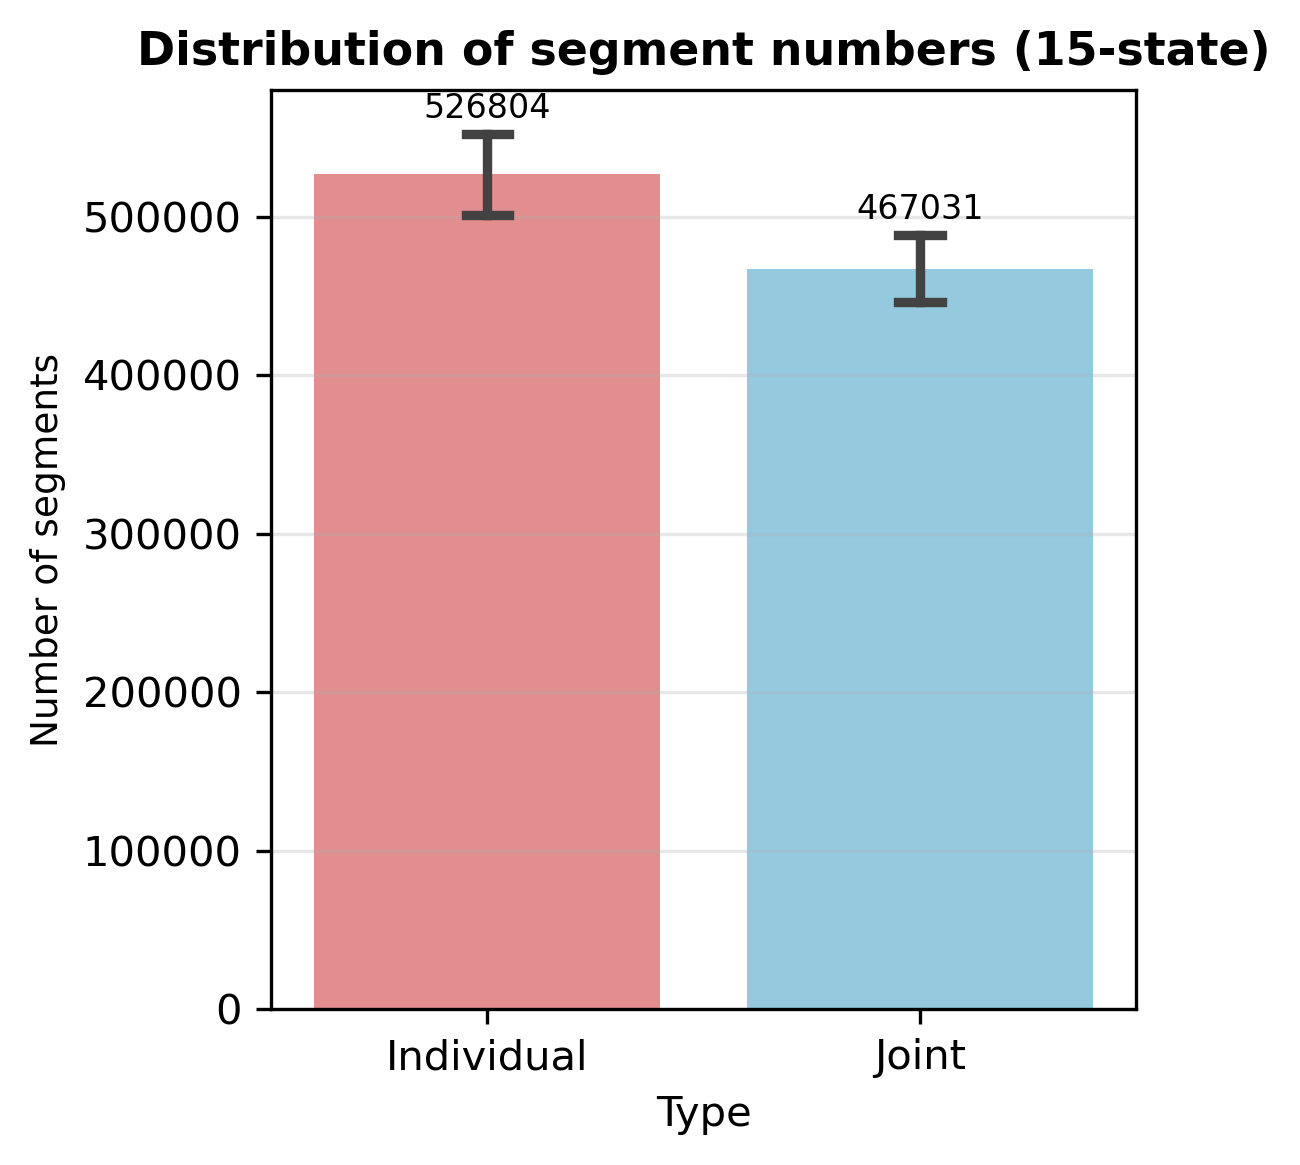

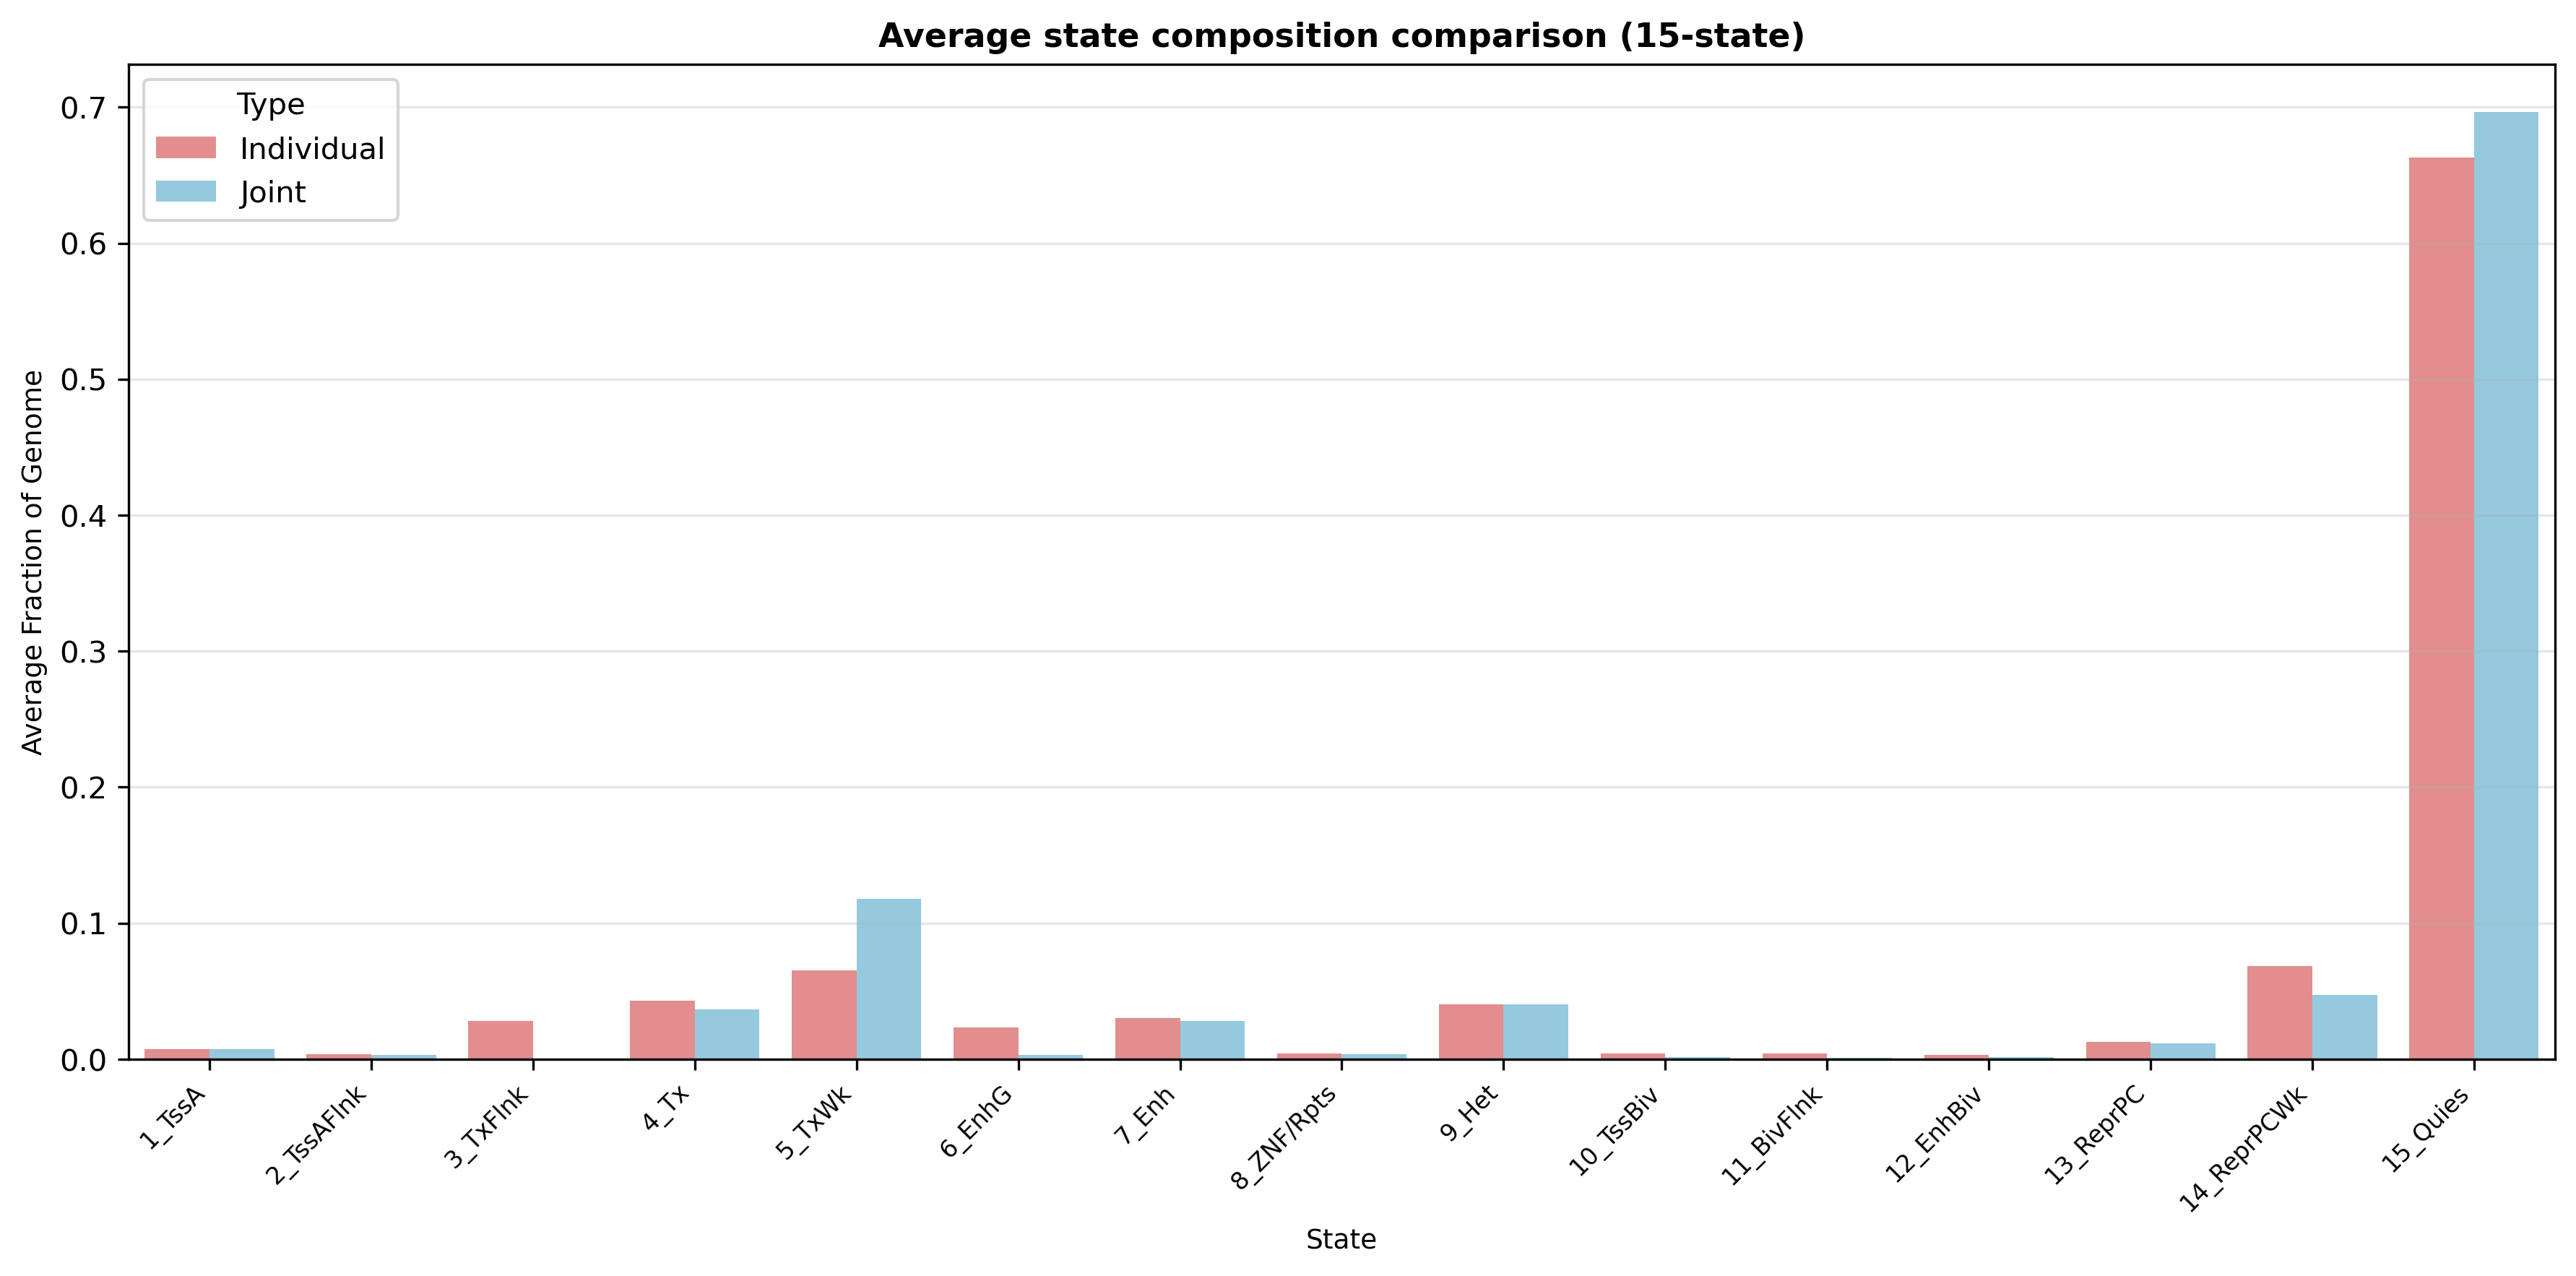

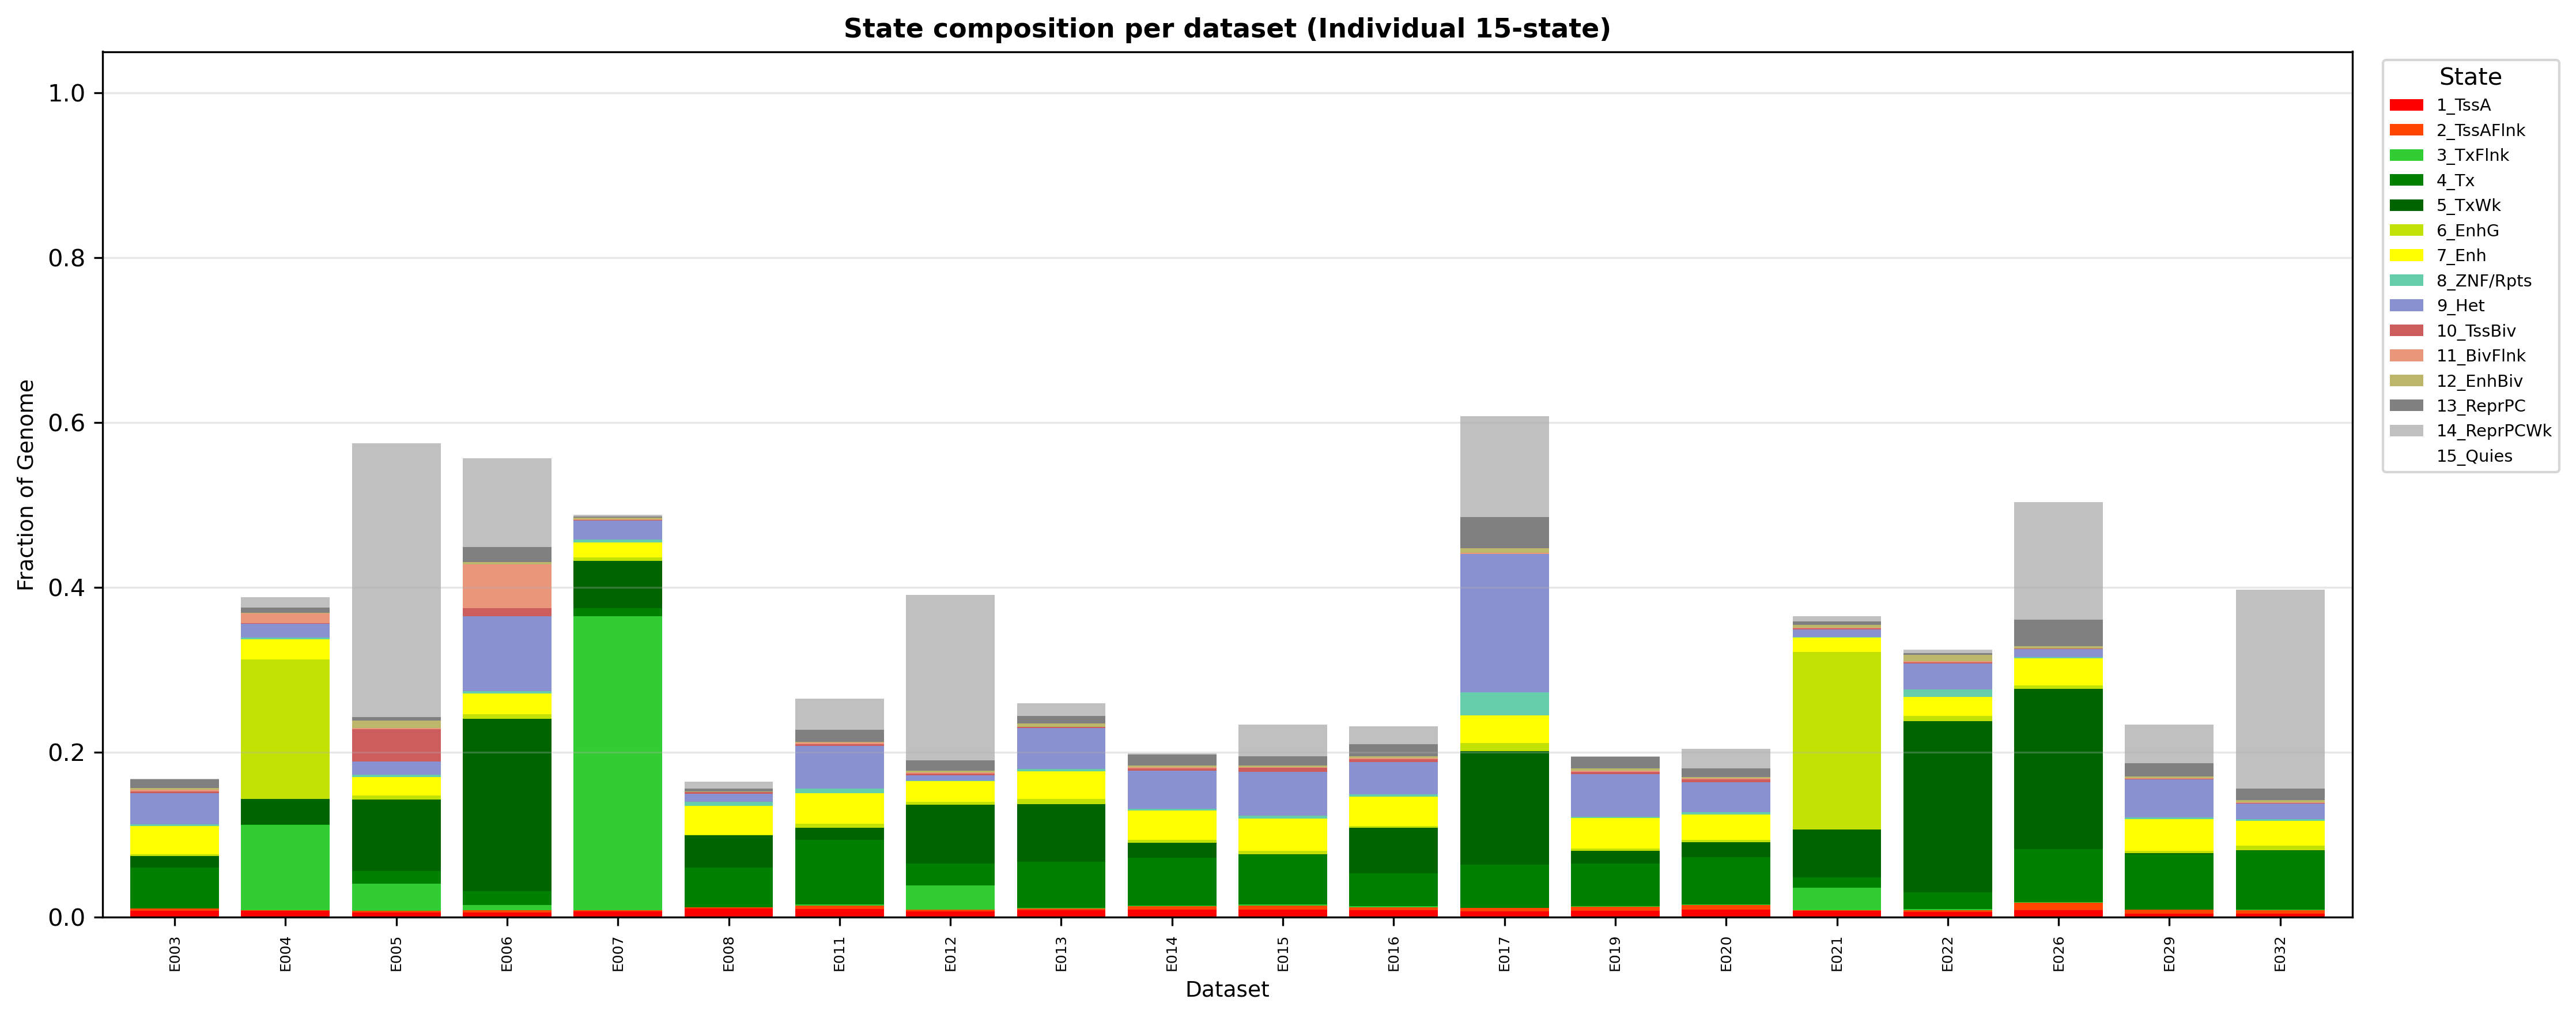

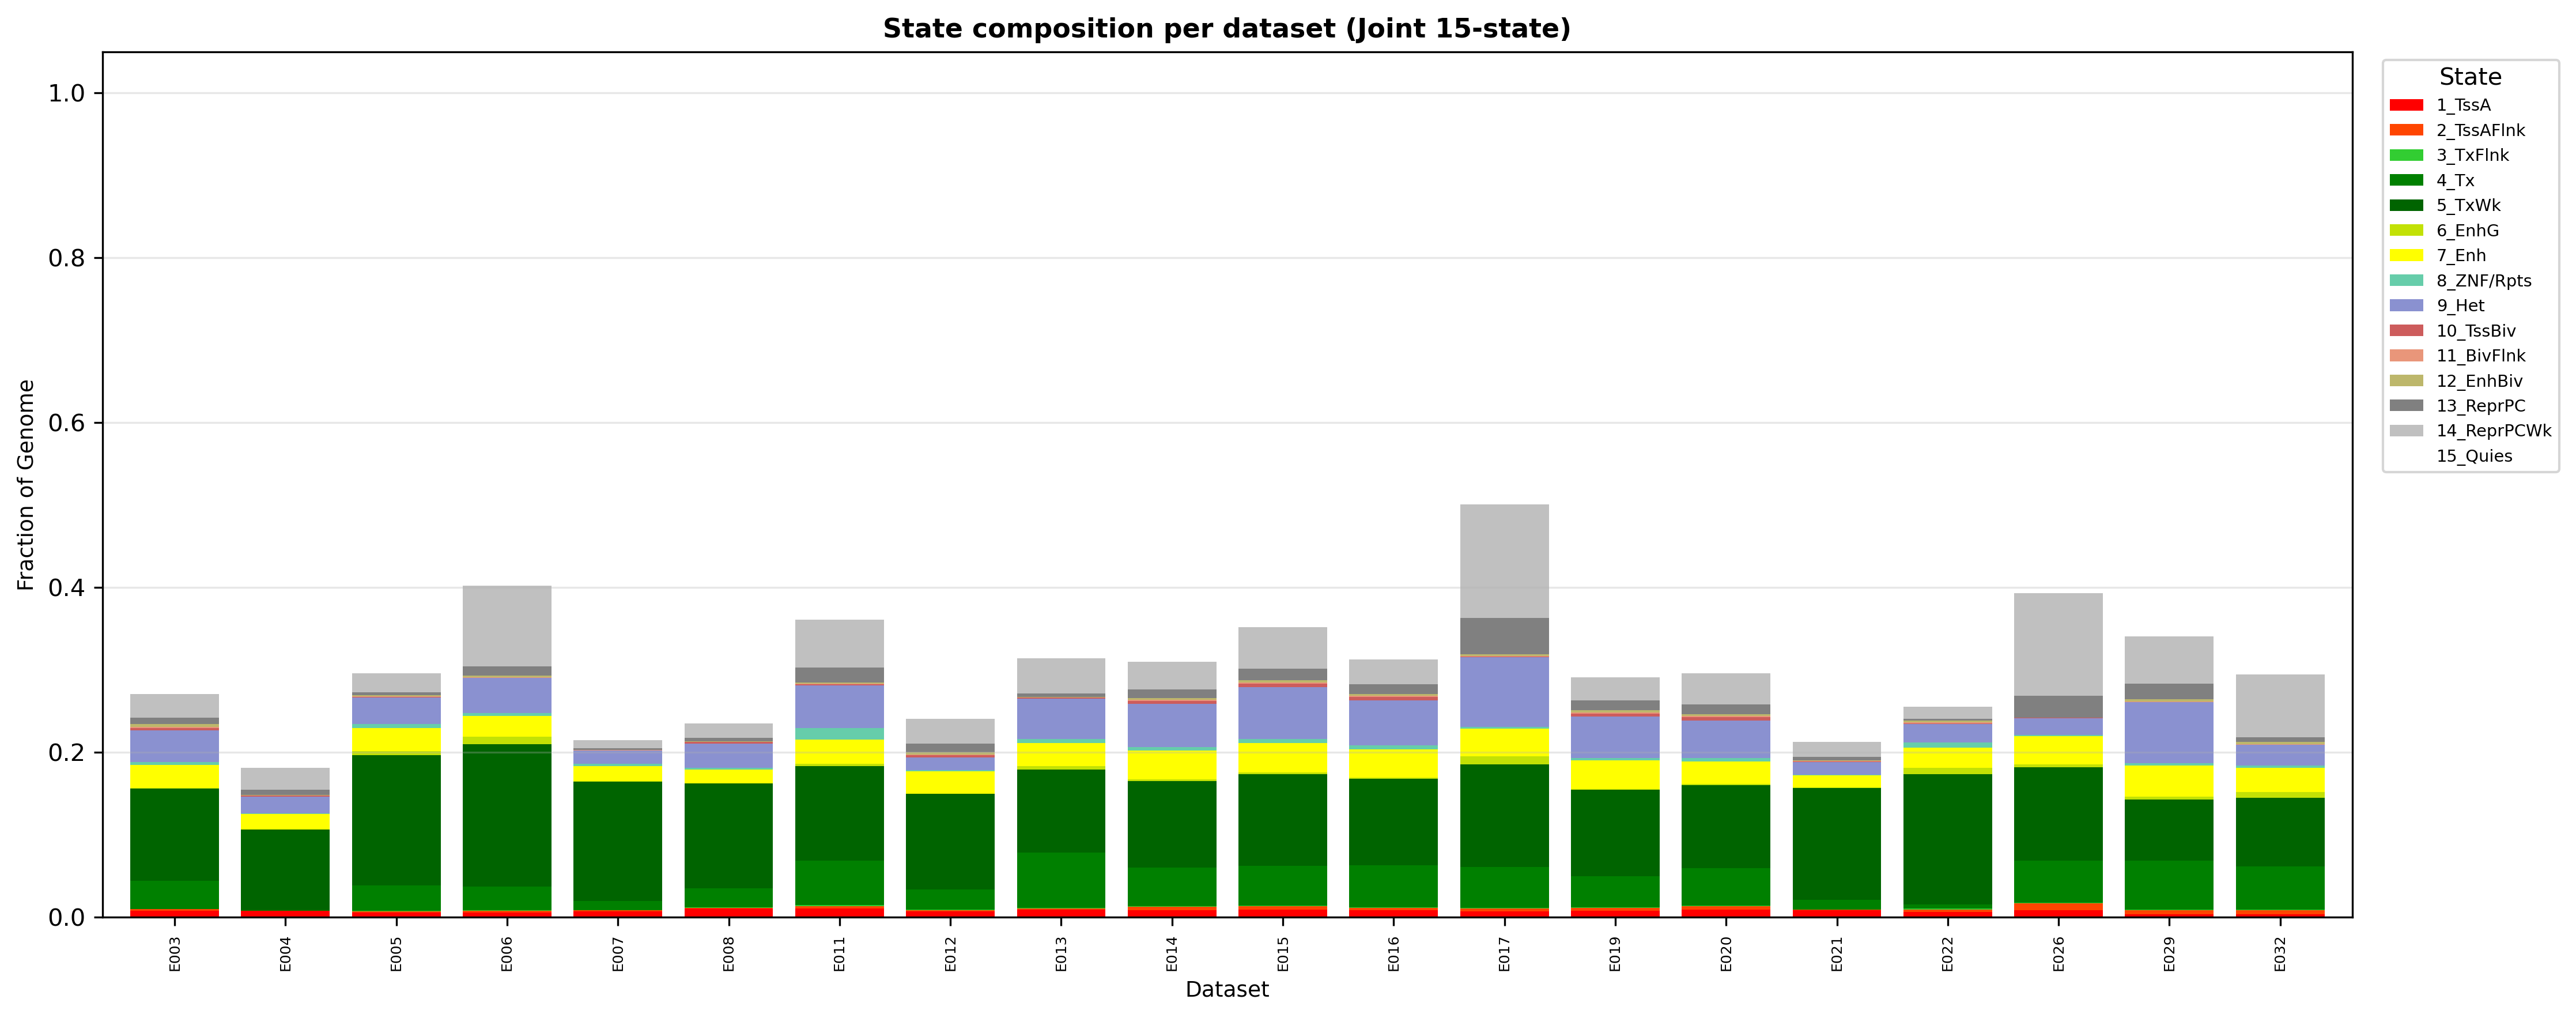

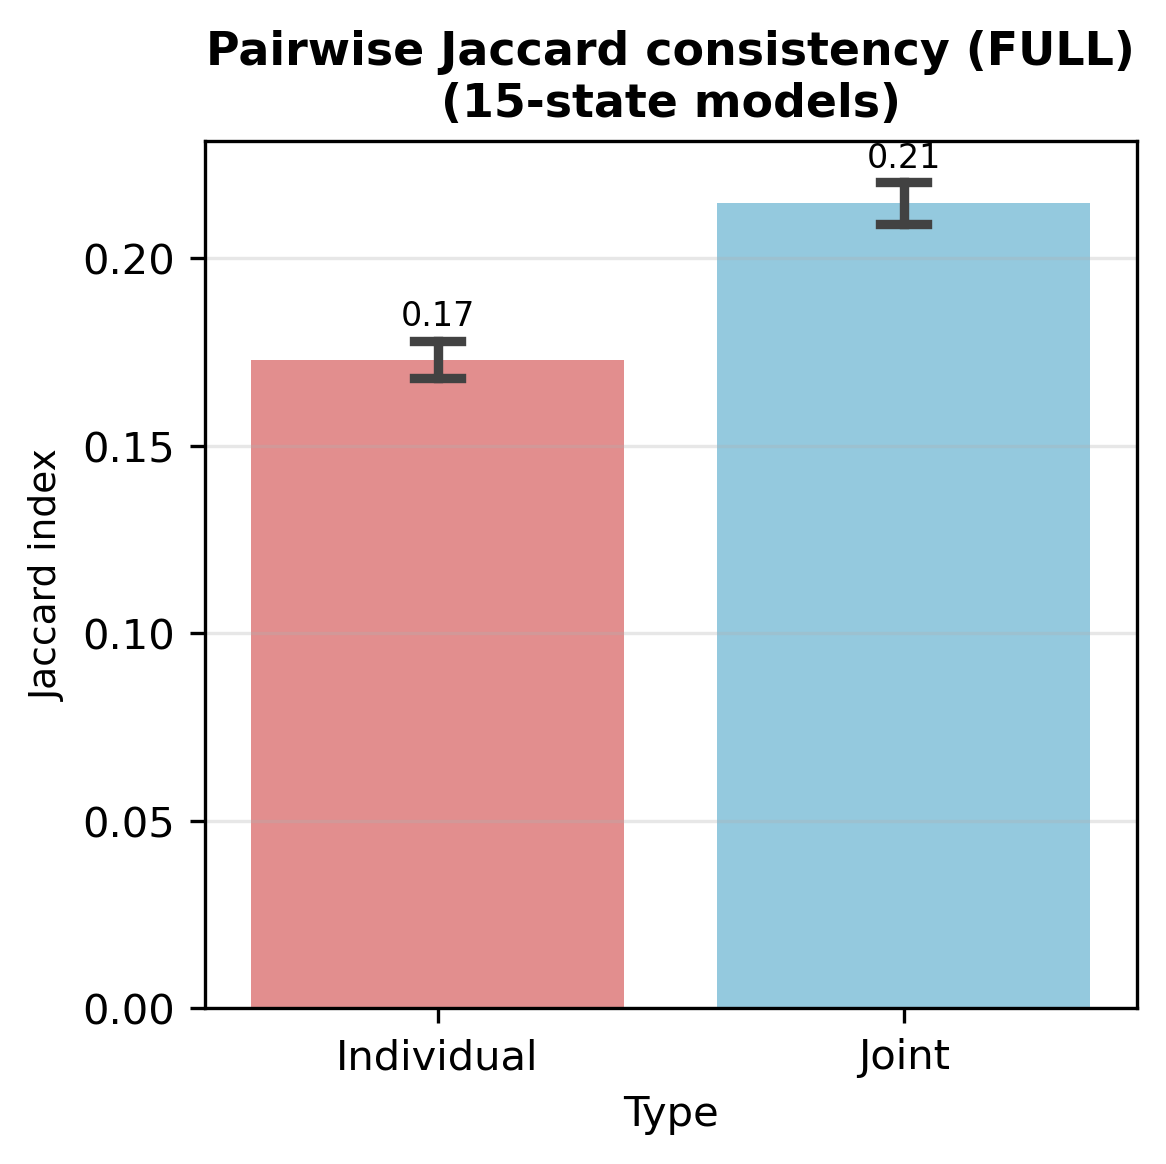

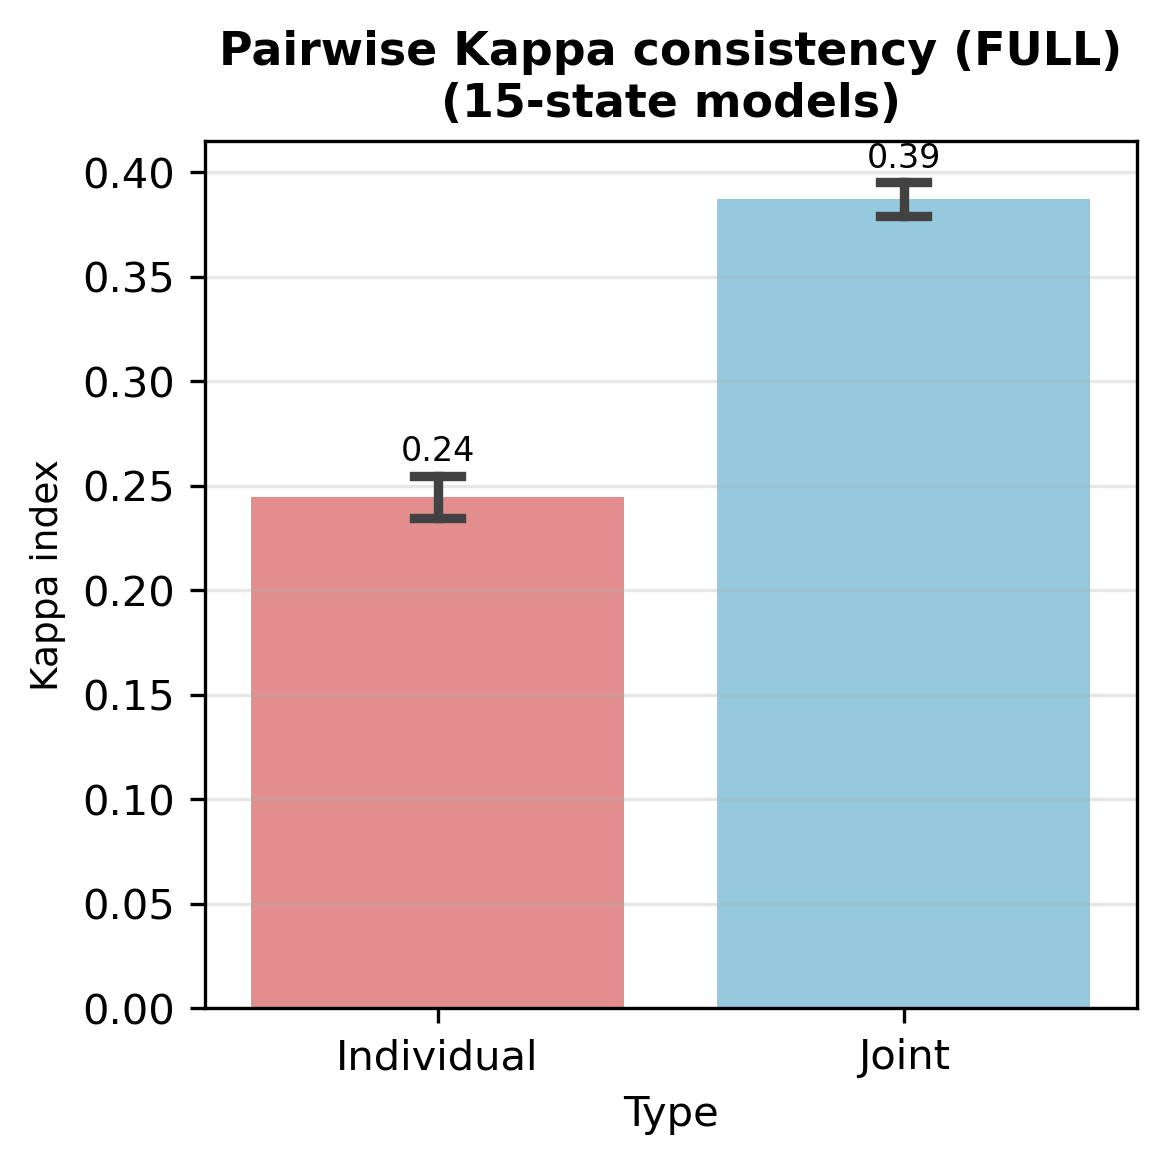

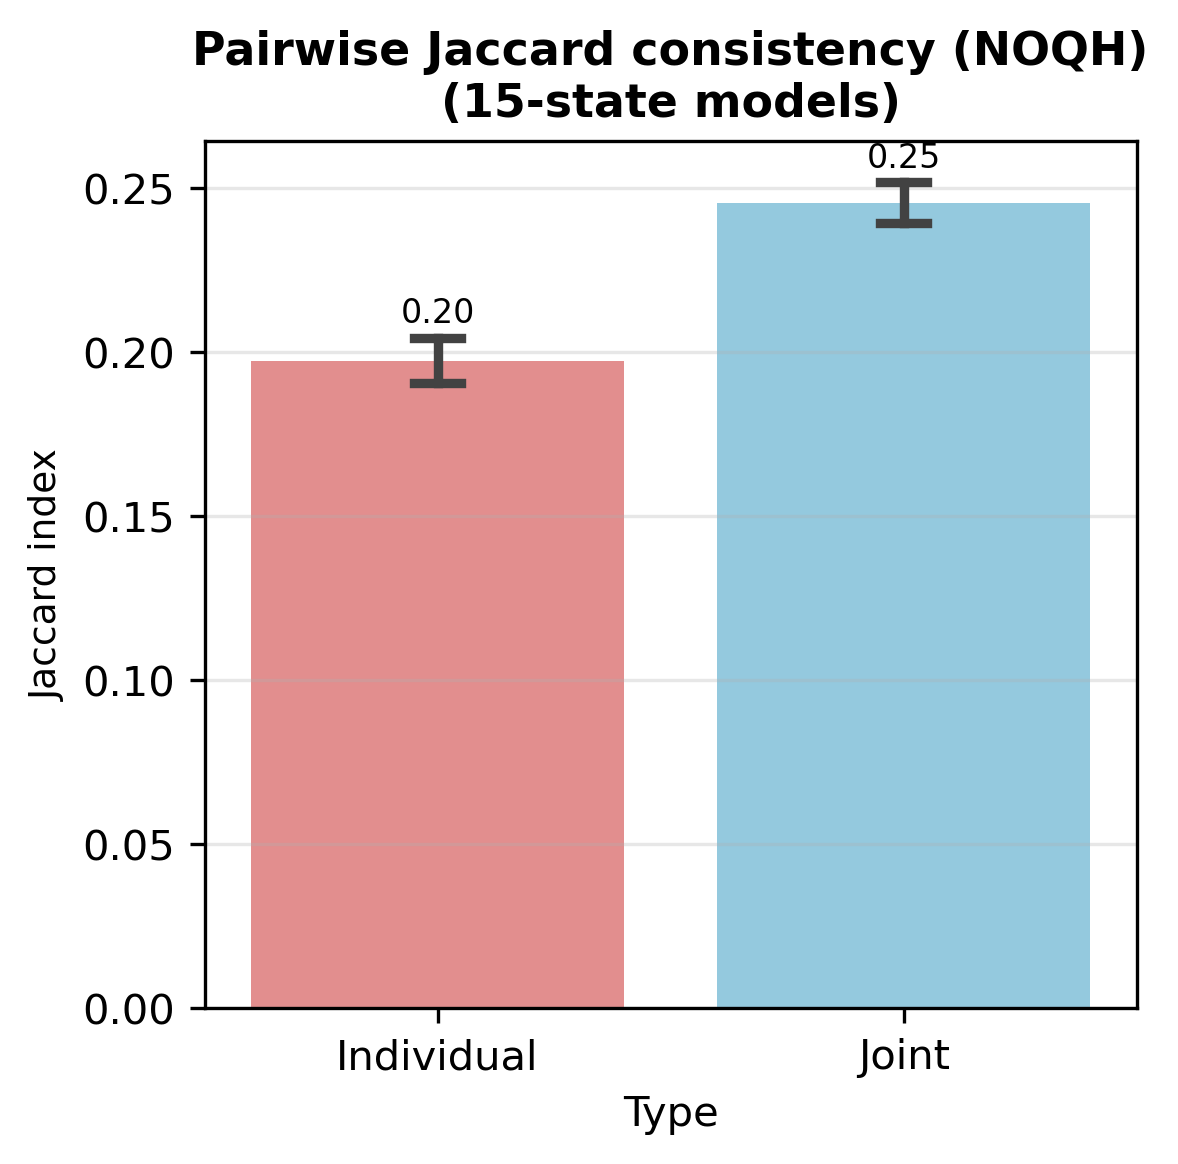

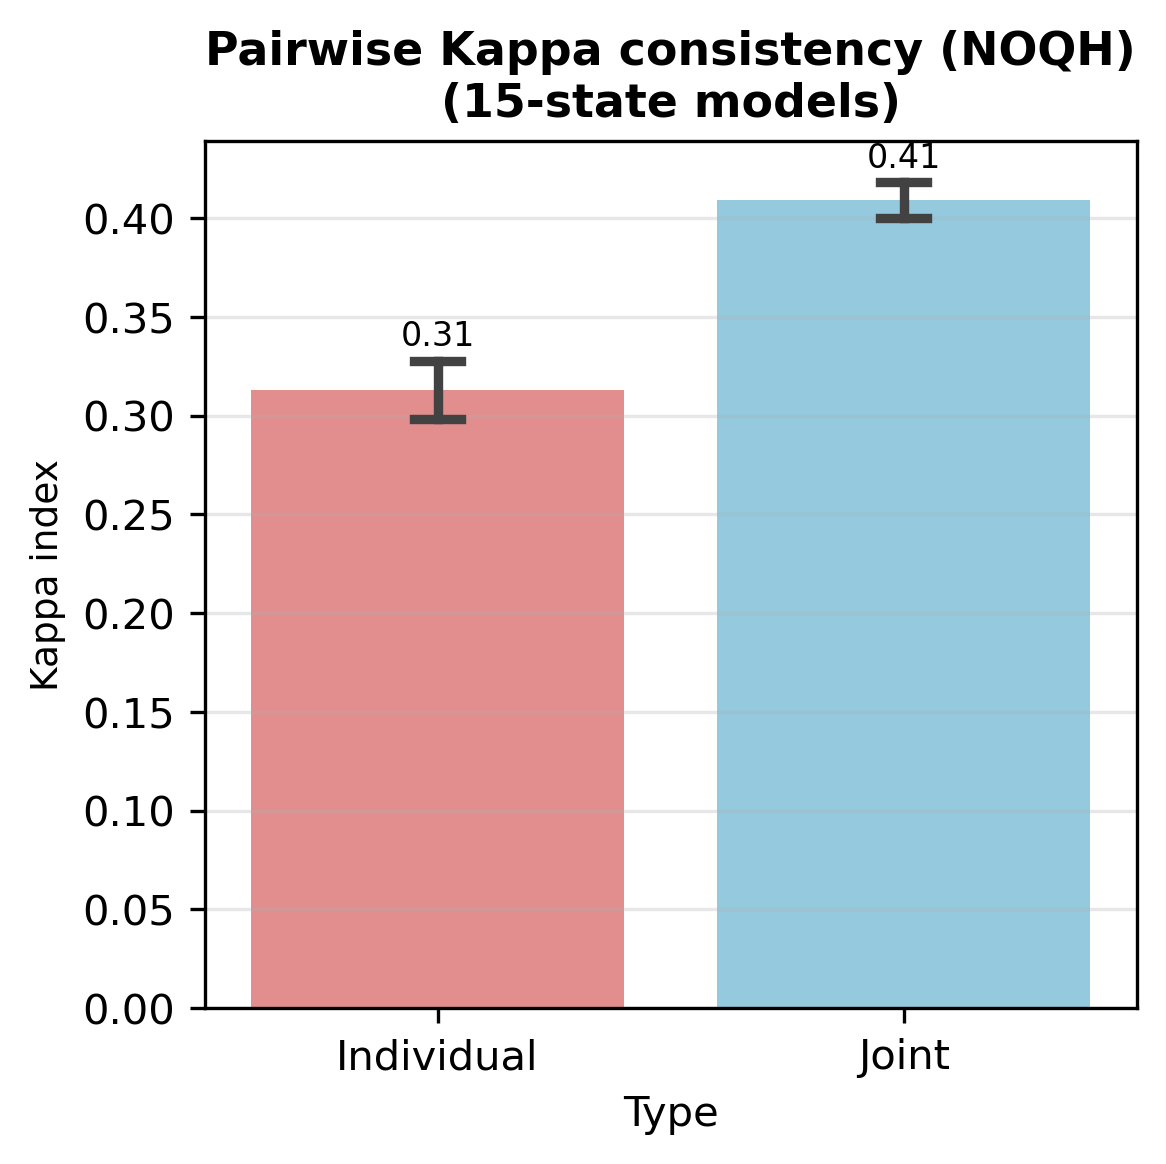

In [22]:
display(Image(filename="out/epi_1000/epi_15_segments_comparison.png"))
display(Image(filename="out/epi_1000/epi_15_avg_composition_comparison.png"))
display(Image(filename="out/epi_1000/epi_15_individual_composition_per_dataset.png"))
display(Image(filename="out/epi_1000/epi_15_joint_composition_per_dataset.png"))
for mode in ["FULL", "NOQH"]:
    for metric in ["Jaccard", "Kappa"]:
        display(Image(filename=f"out/epi_1000/epi_15_pw_{mode.lower()}_{metric.lower()}.png"))
